This notebook is used to create the harmonized disease-gene annotations

In [1]:
import requests
import json
import os
import pandas as pd
import urllib.request, urllib.error, urllib.parse
import pickle as pk
import networkx as nx
import random as rd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark import SparkConf
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import time
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
from collections import defaultdict

In [2]:
import difflib
import pandas as pd
import re
from rapidfuzz import process, fuzz

def get_overlap(s1, s2):
    s = difflib.SequenceMatcher(None, s1, s2)
    pos_a, pos_b, size = s.find_longest_match(0, len(s1), 0, len(s2)) 
    return s1[pos_a:pos_a+size]


# Define a cleaner function to remove noise words
def clean_disease_name(text):
    import re
    if not isinstance(text, str): return ""
    text = text.lower()
    noise_patterns = [
        r"\bnot elsewhere classified\b", r"\bnot otherwise specified\b",
        r"\bunspecified\b", r"\bother specified\b", r"\bother\b",
        r"\[.*?\]", r"\(.*?\)"
    ]
    for pattern in noise_patterns:
        text = re.sub(pattern, "", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return " ".join(text.split())

In [3]:


def match_unmapped_diseases_with_sapbert(
    icd_df, 
    current_mapped_dict, 
    source_data_dict, 
    source_name="Source",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
):
    """
    BioBERT/SapBERT pipeline that handles multiple name variants per ICD code.
    
    args:
    icd_df: DataFrame with 'ICD', 'Disease Name' (semicolon-sep), and optionally 'Consensus Name'.
    current_mapped_dict: Dictionary of already matched ICDs to skip.
    source_data_dict: Reference dictionary { "Target Disease Name": genes }.
    
    returns:
    new_matches: Dictionary { ICD: [list_of_genes] }.
    naming_map: Dictionary { (ICD, Main_Label): [Matched_Target_Names] }.
    """
    
    # 1. Identify Unmatched ICD Codes
    matched_codes = set(current_mapped_dict.keys())
    # Filter rows where ICD is NOT in the matched keys
    unmatched_df = icd_df[~icd_df['ICD'].astype(str).isin(matched_codes)].copy()
    
    print(f"[{source_name}] Processing {len(unmatched_df)} unmatched ICD codes...")
    
    if len(unmatched_df) == 0:
        print(f"[{source_name}] All codes already mapped. Skipping.")
        return {}, {}

    # 2. Prepare TARGET Data (The Source Dictionary)
    target_lookup_map = {}
    target_clean_names = []
    
    for original_name in source_data_dict.keys():
        clean = clean_disease_name(original_name)
        if clean:
            target_lookup_map[clean] = original_name
            target_clean_names.append(clean)
            
    # Remove duplicates for embedding efficiency
    target_clean_names = list(set(target_clean_names))
    
    # 3. Prepare QUERY Data (The ICD Names)
    # We flatten the variants: One ICD code -> Multiple Query Strings
    flat_queries = []
    flat_metadata = [] # Stores (icd_code, main_label_for_dict_key)
    
    # Pre-calculate the "Main Label" for each ICD (Consensus or First Name) to use as dictionary key
    for i, row in unmatched_df.iterrows():
        icd_code = str(row['ICD'])
        
        # Determine Main Label for the naming_map key
        if 'Consensus Name' in row and pd.notna(row['Consensus Name']):
            main_label = str(row['Consensus Name'])
        else:
            main_label = str(row['Disease Name']).split(';')[0]
            
        # Collect all variants to test
        variants_to_test = set()
        
        # A. Add Consensus
        if 'Consensus Name' in row and pd.notna(row['Consensus Name']):
            variants_to_test.add(str(row['Consensus Name']))
            
        # B. Add Split Disease Names
        if 'Disease Name' in row and pd.notna(row['Disease Name']):
            parts = str(row['Disease Name']).split(';')
            for p in parts:
                if p.strip():
                    variants_to_test.add(p.strip())
        
        # Add to flat lists
        for variant in variants_to_test:
            clean_q = clean_disease_name(variant)
            if clean_q:
                flat_queries.append(clean_q)
                # Store metadata to map this query back to the ICD code
                flat_metadata.append((icd_code, main_label))

    if not flat_queries:
        print(f"[{source_name}] No valid text found in unmatched ICD codes.")
        return {}, {}

    # 4. Load Model
    print(f"[{source_name}] Loading SapBERT model...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    if torch.cuda.is_available():
        model = model.cuda()

    # Embedding Helper
    def get_embeddings(text_list, batch_size=128):
        model.eval()
        embeddings = []
        for i in tqdm(range(0, len(text_list), batch_size), desc="Embedding"):
            batch_texts = text_list[i:i + batch_size]
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
            with torch.no_grad():
                out = model(**inputs)
                cls_emb = out.last_hidden_state[:, 0, :]
            embeddings.append(cls_emb.cpu().numpy())
        return np.vstack(embeddings)

    # 5. Generate Embeddings
    print(f"[{source_name}] Embedding {len(target_clean_names)} targets...")
    target_emb = get_embeddings(target_clean_names)
    
    print(f"[{source_name}] Embedding {len(flat_queries)} query variants...")
    query_emb = get_embeddings(flat_queries)

    # 6. Compute Cosine Similarity
    print(f"[{source_name}] Matching...")
    sim_matrix = cosine_similarity(query_emb, target_emb)
    
    # 7. Extract Matches
    new_matches_temp = {} # {icd_code: set(genes)} - use set for deduping during loop
    naming_map = {}       # {(icd, main_label): set(matched_names)}
    
    # Iterate through every query variant
    for i, (icd_code, main_label) in enumerate(flat_metadata):
        # Find best match for this specific variant
        best_idx = np.argmax(sim_matrix[i])
        best_score = sim_matrix[i][best_idx]
        
        if best_score >= threshold:
            matched_clean_target = target_clean_names[best_idx]
            original_target_key = target_lookup_map[matched_clean_target]
            
            # --- Aggregate Genes ---
            genes = source_data_dict[original_target_key]
            
            if icd_code not in new_matches_temp: 
                new_matches_temp[icd_code] = set()
            
            if isinstance(genes, (list, set, tuple)):
                new_matches_temp[icd_code].update(genes)
            else:
                new_matches_temp[icd_code].add(genes)
            
            # --- Update Naming Map ---
            key_tuple = (icd_code, main_label.lower())
            if key_tuple not in naming_map:
                naming_map[key_tuple] = set()
            naming_map[key_tuple].add(original_target_key)

    # 8. Final Formatting
    # Convert gene sets to lists for final output
    new_matches_final = {k: list(v) for k, v in new_matches_temp.items()}
    # Convert naming map values to lists
    naming_map_final = {k: list(v) for k, v in naming_map.items()}

    print(f"[{source_name}] Found {len(new_matches_final)} new matches via SapBERT.")
    return new_matches_final, naming_map_final

### Disease mapping

In [38]:
#Let's import the complete lists of ICD10 dseases
female_diseases = pd.read_csv("input/Diagnoses_per_age_Female.csv",sep=",")
male_diseases = pd.read_csv("input/Diagnoses_per_age_Male.csv",sep=",")

In [39]:
#We have a list of 1081 diseases (same for male and females)
print(len(set(male_diseases['icd_code']) & set(female_diseases['icd_code'])))

icd10_set = set(male_diseases['icd_code'])

1081


In [67]:
#Let's import the WHO ICD-10 classification from the CDC website (updated 2023)
#https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Publications/ICD10/

#icd_nomenclature_df = pd.read_csv("input/allvalid2023-detailed-titles-headings.csv",sep=",",skiprows=6)

#We are going to use the code adopted until 2016 so that it matches with the data from the moment of the diagnosis in Austria
#From: https://biobank.ndph.ox.ac.uk/ukb/coding.cgi?id=19
icd_nomenclature_df = pd.read_csv("input/coding19.tsv",sep="\t")


In [70]:
import pandas as pd
import re

# 1. Regex to remove codes like "A00", "A00.0", "B20.1", etc.
# Looks for letters and numbers followed by an optional dot and more numbers at the start
code_pattern = r'^[A-Z][0-9][0-9](?:\.[0-9]+)?\s+'

def clean_name(text):
    if pd.isna(text):
        return ""
    # Remove the code and any leading/trailing whitespace
    return re.sub(code_pattern, '', str(text)).strip()

# 2. Map for easy lookups
# We apply the cleaning function immediately to all meanings
icd_nomenclature_df['clean_meaning'] = icd_nomenclature_df['meaning'].apply(clean_name)

icd_nomenclature_dict = {}

# 3. Identify the main categories (3-digit codes)
# We filter for only the codes you are interested in from icd10_set
parents_df = icd_nomenclature_df[icd_nomenclature_df['coding'].str.len() == 3]

for _, row in parents_df.iterrows():
    p_code = row['coding']
    
    # Only process if it's in your target set
    if p_code in icd10_set:
        p_id = row['node_id']
        p_name = row['clean_meaning']
        
        # Find all children and clean their names
        children_names = icd_nomenclature_df[icd_nomenclature_df['parent_id'] == p_id]['clean_meaning'].tolist()
        
        # 4. Construct list: Main name first, then sub-names
        # We use a list comprehension to remove potential duplicates (like if the parent 
        # name is repeated in children) while maintaining the first-element rule.
        combined_list = [p_name]
        for name in children_names:
            if name != p_name and name not in combined_list:
                combined_list.append(name)
        
        icd_nomenclature_dict[p_code] = combined_list

# Verification of the first entry
test_key = list(icd_nomenclature_dict.keys())[0]
print(f"Code: {test_key}")
print(f"Names: {icd_nomenclature_dict[test_key]}")

Code: A00
Names: ['Cholera', 'Cholera due to Vibrio cholerae 01, biovar cholerae', 'Cholera due to Vibrio cholerae 01, biovar el tor', 'Cholera, unspecified']


In [272]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# --- CONFIGURATION ---
MODEL_NAME = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
BATCH_SIZE = 64

# 1. Load Model & Tokenizer
print("Loading SapBERT model...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.cuda()
    print("Using GPU for fast processing.")
else:
    print("Using CPU (this will be slower).")

# 2. Embedding Function (Batched for speed)
def get_embeddings(text_list):
    """Generates embeddings for a list of strings using SapBERT."""
    model.eval()
    embeddings = []
    
    # Remove duplicates to save time, we map them back later
    unique_texts = list(set(text_list))
    # Filter out empty strings
    unique_texts = [t for t in unique_texts if t.strip()]
    
    # Map text -> index for reassembly
    text_to_index = {t: i for i, t in enumerate(unique_texts)}
    
    all_embs = []
    
    # Process in batches
    for i in tqdm(range(0, len(unique_texts), BATCH_SIZE), desc="Embedding unique names"):
        batch = unique_texts[i:i + BATCH_SIZE]
        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt", max_length=128)
        
        if torch.cuda.is_available():
            inputs = {k: v.cuda() for k, v in inputs.items()}
            
        with torch.no_grad():
            outputs = model(**inputs)
            # Use [CLS] token (index 0) as the semantic representation
            cls_emb = outputs.last_hidden_state[:, 0, :]
            all_embs.append(cls_emb.cpu().numpy())
            
    if not all_embs:
        return {}, {}

    # Stack all embeddings into one large matrix
    emb_matrix = np.vstack(all_embs)
    return text_to_index, emb_matrix

# 3. Consensus Logic 
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import re

def find_consensus_name(name_list, text_to_index, emb_matrix):
    valid_names = [n.strip().lower() for n in name_list if n in text_to_index]
    if not valid_names: return None
    
    anchor_name = valid_names[0]
    
    # 1. IDENTIFY THE "MUST-HAVE" PATHOLOGY
    # We look for the primary medical condition in the 3-digit title
    pathology_keywords = [
        "neoplasm", "malignant", "cancer", "carcinoma", "diabetes", 
        "syphilis", "cholera", "infection", "secondary", "primary"
    ]
    # Find which pathology words are in the anchor
    required_terms = [w for w in pathology_keywords if w in anchor_name]

    # 2. FILTERING & DISQUALIFICATION
    fillers = ["unspecified", "nos", "not otherwise", "other and", "other sites"]
    candidates = []
    
    for n in valid_names:
        # Rule A: Skip the 'garbage' terms
        if any(f in n for f in fillers):
            continue
            
        # Rule B: If there's a required pathology, the candidate MUST have it
        # This disqualifies fragments like "upper limb" or "thorax"
        if required_terms:
            if not any(term in n for term in required_terms):
                continue
        
        # Rule C: Minimum length check
        if len(n.split()) >= 1:
            candidates.append(n)

    # 3. CLEAN FALLBACK (The "Anchor-First" Rule)
    # If no sub-code is better than the anchor, we clean the anchor and use it.
    def clean_text(text):
        text = re.sub(r',? unspecified', '', text, flags=re.IGNORECASE)
        text = re.sub(r'other and ', '', text, flags=re.IGNORECASE)
        text = re.sub(r'other ', '', text, flags=re.IGNORECASE)
        return text.strip().title()

    if not candidates:
        return clean_text(anchor_name)

    # 4. SEMANTIC SELECTION WITH PARSIMONY
    anchor_emb = emb_matrix[text_to_index[anchor_name]].reshape(1, -1)
    candidate_indices = [text_to_index[n] for n in candidates]
    candidate_embs = emb_matrix[candidate_indices]
    
    similarities = cosine_similarity(candidate_embs, anchor_emb).flatten()
    
    best_idx = 0
    max_score = -1
    for i, (sim, cand) in enumerate(zip(similarities, candidates)):
        # Apply a length penalty to prefer concise names
        length_penalty = 1.0 - (len(cand.split()) * 0.02)
        score = sim * length_penalty
        
        if score > max_score:
            max_score = score
            best_idx = i
            
    return clean_text(candidates[best_idx])

# --- MAIN EXECUTION ---

# Collect ALL unique names in the entire dataset for efficient batch embedding
all_unique_names = set()
for dislist in icd_nomenclature_dict.values():
    all_unique_names.update([el.lower() for el in dislist])
print(f"Found {len(all_unique_names)} unique diseases.")

# B. Generate Embeddings
text_to_idx, embedding_matrix = get_embeddings(list(all_unique_names))

# C. Apply Consensus
print("Calculating consensus names...")

icd_consensus_dict = {}
for icd, dislist in icd_nomenclature_dict.items():
    if len(dislist) > 0:
        # Lowercase for embedding lookup compatibility
        cl_dislist = [str(d).lower().strip() for d in dislist if str(d) != "nan"]
        # The first item in cl_dislist is now your "Weighted" anchor
        consensus = find_consensus_name(cl_dislist, text_to_idx, embedding_matrix)
        icd_consensus_dict[icd] = consensus

# Select final columns
final_df = pd.DataFrame()
individual_disease_names = []
consensus_names = []
ICD = []
for icd,dislist in icd_nomenclature_dict.items():
    if len(dislist)>0:
        ICD.append(icd)
        individual_disease_names.append(';'.join([el.lower() for el in dislist]))
        consensus_names.append(icd_consensus_dict[icd])

final_df['ICD'] = ICD
final_df['Disease Name'] = individual_disease_names
final_df['Consensus Name'] = consensus_names
final_df['Consensus Name'] = final_df['Consensus Name'].str.replace(r', unspecified$', '', case=False, regex=True)
final_df['Consensus Name'] = final_df['Consensus Name'].str.replace(r'^Other ', '', case=False, regex=True)
final_df['Consensus Name'] = final_df['Consensus Name'].str.lower()

print("Done!")


Loading SapBERT model...
Using CPU (this will be slower).
Found 6158 unique diseases.


Embedding unique names: 100%|██████████| 97/97 [00:22<00:00,  4.33it/s]


Calculating consensus names...
Done!


In [276]:

final_df.to_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

In [27]:
icd_naming_df = pd.read_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

In [ ]:
import re
unspecific_terms = ["not confirmed bacteriologically or histologically","not elsewhere classified","unspecified","not specified as haemorrhage or infarction",
                    "nonorganic","not otherwise specified","not resulting in cerebral infarction","not identified",
                    "not specified as acute or chronic","without specification of site",
                    "not caused by organic disorder or disease","predominantly", "nos", "not otherwise", "not induced by alcohol and psychoactive substances",
                    "other and", "other sites","without specification","not otherwise specified","other","not"]


PubMed_query_name = []
for i,v in icd_naming_df.iterrows():
    el = v['Consensus Name']
    if any(term in el.lower() for term in unspecific_terms):
        intersected_terms = [term for term in unspecific_terms if term in el.lower()]
        cleaned_name = el
        for term in intersected_terms:
            cleaned_name = re.sub(r'\b' + re.escape(term) + r'\b', '', cleaned_name, flags=re.IGNORECASE)
        cleaned_name = re.sub(r'\s+', ' ', cleaned_name).strip().replace(",","")
        print(f"Original: {el} | Cleaned: {cleaned_name}")
        PubMed_query_name.append(cleaned_name)
    else:
        PubMed_query_name.append(el)
        
icd_naming_df['PubMed_query_name'] = PubMed_query_name
icd_naming_df.to_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

Original: respiratory tuberculosis, not confirmed bacteriologically or histologically | Cleaned: respiratory tuberculosis
Original: zoonotic bacterial diseases, not elsewhere classified | Cleaned: zoonotic bacterial diseases
Original: bacterial diseases, not elsewhere classified | Cleaned: bacterial diseases
Original: predominantly sexually transmitted diseases, not elsewhere classified | Cleaned: sexually transmitted diseases
Original: unspecified sexually transmitted disease | Cleaned: sexually transmitted disease
Original: viral encephalitis, not elsewhere classified | Cleaned: viral encephalitis
Original: unspecified viral encephalitis | Cleaned: viral encephalitis
Original: viral infections of central nervous system, not elsewhere classified | Cleaned: viral infections of central nervous system
Original: unspecified viral infection of central nervous system | Cleaned: viral infection of central nervous system
Original: unspecified arthropod-borne viral fever | Cleaned: arthropod-b

In [65]:
icd_naming_df.head()

,Unnamed: 0,ICD,Disease Name,Consensus Name,PubMed_query_name
0,0,A00,"cholera;cholera due to vibrio cholerae 01, bio...",cholera,cholera
1,1,A01,typhoid and paratyphoid fevers;typhoid fever;p...,typhoid and paratyphoid fevers,typhoid and paratyphoid fevers
2,2,A02,other salmonella infections;salmonella gastro-...,salmonella infections,salmonella infections
3,3,A03,shigellosis;shigellosis due to shigella dysent...,shigellosis,shigellosis
4,4,A04,other bacterial intestinal infections;enteropa...,bacterial intestinal infections,bacterial intestinal infections


In [4]:
icd_naming_df = pd.read_csv("output/disease_name_consensus_official_names.tsv",sep="\t")

In [5]:
#Let's associate ICD-10 codes with MESH IDs

df_icd = pd.read_csv("input/mondo_exactmatch_icd10who.sssom.tsv", sep='\t', comment='#')
df_icd = df_icd[['subject_id', 'subject_label', 'object_id']]
df_icd.columns = ['MONDO_ID', 'Disease_Name', 'ICD10_Code']

df_mesh = pd.read_csv("input/mondo_exactmatch_mesh.sssom.tsv", sep='\t', comment='#')
df_mesh = df_mesh[['subject_id', 'object_id']]
df_mesh.columns = ['MONDO_ID', 'MeSH_ID']

master_table = pd.merge(df_icd, df_mesh, on='MONDO_ID', how='outer')

master_table['ICD10_Code'] = master_table['ICD10_Code'].str.replace('ICD10WHO:', '')
master_table['MeSH_ID'] = master_table['MeSH_ID'].str.replace('MESH:', '')
master_table.dropna(inplace=True)

In [7]:
df_mesh = pd.read_csv("input/mondo_exactmatch_mesh.sssom.tsv", sep='\t', comment='#')

In [15]:
import pandas as pd
import numpy as np
from rapidfuzz import process, fuzz
from tqdm import tqdm


# ---------------------------------------------------------
# Prepare MeSH reference
# ---------------------------------------------------------

mesh_reference = (
    df_mesh[['subject_label', 'object_id']]
    .dropna(subset=['subject_label', 'object_id'])
    .copy()
)

mesh_reference['clean_name'] = (
    mesh_reference['subject_label']
    .astype(str)
    .str.lower()
    .str.strip()
    .map(clean_disease_name)
)

mesh_reference = mesh_reference[
    mesh_reference['clean_name'].notna()
    & (mesh_reference['clean_name'] != '')
].drop_duplicates('clean_name')


mesh_clean_names = mesh_reference['clean_name'].tolist()

# clean name -> original MeSH name and ID
mesh_name_to_info = (
    mesh_reference
    .set_index('clean_name')[['subject_label', 'object_id']]
    .to_dict('index')
)


print(f"Number of unique MeSH diseases: {len(mesh_clean_names)}")

Number of unique MeSH diseases: 8110


In [16]:
# ICDs already represented in master_table
mapped_icds = set(
    master_table['ICD10_Code']
    .dropna()
    .astype(str)
    .str.strip()
)

# ICDs available in your nomenclature table
icd_nomenclature = icd_naming_df.copy()

icd_nomenclature['ICD'] = (
    icd_nomenclature['ICD']
    .astype(str)
    .str.strip()
)

# Keep ONLY ICDs absent from master_table
unmapped_icd_df = icd_nomenclature[
    ~icd_nomenclature['ICD'].isin(mapped_icds)
].copy()

print(f"Total ICD codes: {len(icd_nomenclature)}")
print(f"Already in master_table: {len(mapped_icds)}")
print(f"ICD codes to match against MeSH: {len(unmapped_icd_df)}")

Total ICD codes: 1081
Already in master_table: 173
ICD codes to match against MeSH: 933


In [18]:
FUZZY_THRESHOLD = 90

mesh_matches = []

for _, row in tqdm(
    unmapped_icd_df.iterrows(),
    total=len(unmapped_icd_df),
    desc="Matching ICD diseases to MeSH"
):

    icd_code = row['ICD']

    # -----------------------------------------------------
    # Collect ALL names associated with this ICD
    # -----------------------------------------------------

    names_to_test = set()

    if pd.notna(row.get('Consensus Name')):
        names_to_test.add(
            str(row['Consensus Name']).strip()
        )

    if pd.notna(row.get('Disease Name')):
        for name in str(row['Disease Name']).split(';'):
            if name.strip():
                names_to_test.add(name.strip())

    # -----------------------------------------------------
    # Match every variant independently
    # -----------------------------------------------------

    for raw_name in names_to_test:

        clean_query = clean_disease_name(raw_name)

        if not clean_query:
            continue

        matches = process.extract(
            clean_query,
            mesh_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=3,
            score_cutoff=FUZZY_THRESHOLD
        )

        for matched_name, score, _ in matches:

            info = mesh_name_to_info[matched_name]

            mesh_matches.append({
                'ICD': icd_code,
                'query_name': raw_name,
                'query_clean': clean_query,
                'MeSH_name': info['subject_label'],
                'MeSH_ID': info['object_id'],
                'similarity': score
            })


mesh_match_df = pd.DataFrame(mesh_matches)

print(
    f"Generated {len(mesh_match_df)} "
    f"candidate ICD-10 → MeSH matches."
)

Matching ICD diseases to MeSH: 100%|██████████| 933/933 [00:17<00:00, 53.76it/s]

Generated 716 candidate ICD-10 → MeSH matches.


In [20]:
# Best match for each ICD + query variant
best_variant_matches = (
    mesh_match_df
    .sort_values('similarity', ascending=False)
    .drop_duplicates(
        subset=['ICD', 'query_clean'],
        keep='first'
    )
)

print(
    f"Best matches retained for "
    f"{best_variant_matches['ICD'].nunique()} ICD codes."
)

def aggregate_mesh_matches(group):

    # Sort by similarity
    group = group.sort_values(
        'similarity',
        ascending=False
    )

    # Best match
    best = group.iloc[0]

    # Number of independent variants supporting this MeSH
    support = (
        group
        .groupby('MeSH_ID')
        .size()
        .sort_values(ascending=False)
    )

    best_mesh_id = support.index[0]

    supporting_rows = group[
        group['MeSH_ID'] == best_mesh_id
    ]

    return pd.Series({
        'MeSH_ID': best_mesh_id,
        'MeSH_name': supporting_rows.iloc[0]['MeSH_name'],
        'best_score': supporting_rows['similarity'].max(),
        'mean_score': supporting_rows['similarity'].mean(),
        'n_supporting_variants': len(supporting_rows),
        'n_variants_tested': group['query_clean'].nunique()
    })


mesh_consensus = (
    best_variant_matches
    .groupby('ICD')
    .apply(aggregate_mesh_matches)
    .reset_index()
)

print(mesh_consensus.head())

Best matches retained for 335 ICD codes.
   ICD       MeSH_ID          MeSH_name  best_score  mean_score  \
0  A01  mesh:D010284  paratyphoid fever  100.000000   95.833333   
1  A05  mesh:D001906           botulism  100.000000  100.000000   
2  A06  mesh:D000562          amebiasis   94.736842   94.736842   
3  A07  mesh:D001447      balantidiasis  100.000000  100.000000   
4  A21  mesh:D014406          tularemia   94.736842   94.736842   

   n_supporting_variants  n_variants_tested  
0                      4                  5  
1                      1                  1  
2                      1                  1  
3                      1                  4  
4                      1                  1  


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_49413/1487932164.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregate_mesh_matches)


In [21]:
def classify_confidence(row):

    score = row['best_score']
    support = row['n_supporting_variants']

    if score >= 95 and support >= 1:
        return 'high'

    elif score >= 90:
        return 'medium'

    else:
        return 'low'


mesh_consensus['confidence'] = (
    mesh_consensus
    .apply(classify_confidence, axis=1)
)

In [22]:
print(
    mesh_consensus['confidence']
    .value_counts()
)

print(
    f"High confidence: "
    f"{(mesh_consensus['confidence'] == 'high').sum()}"

)

print(
    f"Medium confidence: "
    f"{(mesh_consensus['confidence'] == 'medium').sum()}"
)

confidence
high      274
medium     61
Name: count, dtype: int64
High confidence: 274
Medium confidence: 61


In [34]:
icd_name_mesh_dict = {}
for i,v in icd_nomenclature.iterrows():
    icd_code = v["ICD"]
    try:
        try:
            mesh_id = str(master_table[master_table["ICD10_Code"] == icd_code]["MeSH_ID"].values[0]).replace("mesh:","")
            disease_name = v["PubMed_query_name"]
            icd_name_mesh_dict[icd_code] = [disease_name,mesh_id]
        except:
            mesh_id = str(mesh_consensus[mesh_consensus["ICD"] == icd_code]["MeSH_ID"].values[0]).replace("mesh:","")
            disease_name = v["PubMed_query_name"]
            icd_name_mesh_dict[icd_code] = [disease_name,mesh_id]
    except:
        continue
print(len(icd_name_mesh_dict))




482


In [38]:
with open('output/icd_name_mesh_dict.pickle', 'wb') as handle:
    pk.dump(icd_name_mesh_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## NCBI
### https://www.ncbi.nlm.nih.gov/gtr/
### downloaded on 01.2026, downloaded on 17.01.2026, last update on March 19, 2025
#### This file will contain all the genetic testing reported for each condition
#### The location of the file is in input/GDA/ncbi_test_version_2026



In [278]:
#ncbi_disease_gene_df = pd.read_csv("input/GDA/ncbi_test_version", sep="\t")
ncbi_disease_gene_df = pd.read_csv("input/GDA/ncbi_test_version_2026", sep="\t")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_67251/690388826.py:2: DtypeWarning: Columns (4,12,17,20) have mixed types. Specify dtype option on import or set low_memory=False.
  ncbi_disease_gene_df = pd.read_csv("input/GDA/ncbi_test_version_2026", sep="\t")


In [279]:

ncbi_disease_gene_dict = {}
for i,v in ncbi_disease_gene_df.iterrows():
    try:
        ncbi_disease_gene_dict[v["condition_identifiers"]] |= {v["genes"]}
    except KeyError as e:
        ncbi_disease_gene_dict[v["condition_identifiers"]] = set([v["genes"]])


ncbi_disease_gene_dis_list = set(ncbi_disease_gene_dict.keys())
ncbi_disease_gene_dict_cleaned = {}

for dis, geneset in ncbi_disease_gene_dict.items():
    if str(dis)!='nan':
        if "|" in dis:
            dis_list = dis.split("|")
            for d in dis_list:
                if d not in ncbi_disease_gene_dis_list:
                    genelist = []
                    for gene in geneset:
                        if str(gene)!='nan':
                            if "|" in gene:
                                gene_list = gene.split("|")
                                for g in gene_list:
                                    genelist.append(g)
                            else:
                                genelist.append(gene)
                    ncbi_disease_gene_dict_cleaned[d] = set(genelist)
                else:
                    n_genelist = [n for n in ncbi_disease_gene_dict[d] if str(n)!='nan']
                    n_genelist_cl = []
                    for gene in n_genelist:
                        if "|" in gene:
                            gene_list = gene.split("|")
                            for g in gene_list:
                                n_genelist_cl.append(g)
                        else:
                            n_genelist_cl.append(gene)
                    for gene in geneset:
                        if str(gene)!='nan':
                            if "|" in gene:
                                gene_list = gene.split("|")
                                for g in gene_list:
                                    n_genelist_cl.append(g)
                            else:
                                n_genelist_cl.append(gene)
                    ncbi_disease_gene_dict_cleaned[d] = set(n_genelist_cl)
                                
        else:
            genelist = []
            for gene in geneset:
                if str(gene)!='nan':
                    if "|" in gene:
                        gene_list = gene.split("|")
                        for g in gene_list:
                            genelist.append(g)
                    else:
                        genelist.append(gene)
            ncbi_disease_gene_dict_cleaned[dis] = set(genelist)
        
                                


In [280]:

ncbi_lookup_map = defaultdict(list)

for dis in ncbi_disease_gene_dict_cleaned.keys():
    clean_name = clean_disease_name(dis)
    if clean_name:
        ncbi_lookup_map[clean_name].append(dis)

ncbi_clean_names = list(ncbi_lookup_map.keys())

ncbi_disease_icd_gene_dict = {}
ncbi_disease_icd_disease_naming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against NCBI variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations ---
    # We use a set because order doesn't matter if we are agglomerating everything
    names_to_test = set()
    
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    if pd.notna(v.get('Disease Name')):
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    
    # --- STEP B: Match EVERY variation and accumulate genes ---
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue

        # We look for the best match (limit=1) for THIS specific synonym
        matches = process.extract(
            clean_variant,
            ncbi_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                
                # Retrieve original NCBI keys
                original_ncbi_name_list = ncbi_lookup_map[clean_match_name]
                
                for original_name in original_ncbi_name_list:
                    # Save the matched disease name for reference
                    matched_diseases_set.add(original_name)
                    
                    # Add genes to the common pile for this ICD
                    if original_name in ncbi_disease_gene_dict_cleaned:
                        genes = ncbi_disease_gene_dict_cleaned[original_name]
                        
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)

    # --- STEP C: Store Final Results ---
    if aggregated_genes:
        ncbi_disease_icd_gene_dict[icd_code] = list(aggregated_genes)
        
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # This list will now show you exactly which diseases contributed to the "inflation"
        ncbi_disease_icd_disease_naming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(ncbi_disease_icd_gene_dict)} ICD codes.")

Processing 1080 ICD codes against NCBI variants...
Mapped 318 ICD codes.


In [281]:
ncbi_test_sapbert_genedict,ncbi_test_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    ncbi_disease_icd_gene_dict, 
    ncbi_disease_gene_dict_cleaned, 
    source_name="NCBI_Genes",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[NCBI_Genes] Processing 762 unmatched ICD codes...
[NCBI_Genes] Loading SapBERT model...
[NCBI_Genes] Embedding 20861 targets...


Embedding: 100%|██████████| 163/163 [01:19<00:00,  2.05it/s]


[NCBI_Genes] Embedding 4441 query variants...


Embedding: 100%|██████████| 35/35 [00:15<00:00,  2.31it/s]


[NCBI_Genes] Matching...
[NCBI_Genes] Found 86 new matches via SapBERT.


In [282]:
ncbi_disease_icd_gene_merged_dict = {**ncbi_disease_icd_gene_dict, **ncbi_test_sapbert_genedict}
print(f"Total mapped ICD codes after SapBERT: {len(ncbi_disease_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 404


In [283]:
with open('output/ncbi_disease_icd_gene_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(ncbi_disease_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## NCBI Clinvar
### https://www.ncbi.nlm.nih.gov/clinvar/
### downloaded on 01.2026, downloaded on 17.01.2026, last update on January 2026
#### This file will contain all the genes which variants are associated with each disease
#### The location of the file is in input/GDA/ncbi_clinvar_2026.txt



In [284]:

ncbi_disease_gene_clinvar = pd.read_csv("input/GDA/ncbi_clinvar_2026.txt", sep="\t")

In [285]:

ncbi_disease_gene_clinvar_dict = {}
for i,v in ncbi_disease_gene_clinvar.iterrows():
    try:
        ncbi_disease_gene_clinvar_dict[v["DiseaseName"]] |= {v["AssociatedGenes"]}
    except KeyError as e:
        ncbi_disease_gene_clinvar_dict[v["DiseaseName"]] = set([v["AssociatedGenes"]])

In [ ]:

# This ensures if multiple ClinVar entries map to the same "clean name", we keep ALL of them.
ncbi_lookup_map = defaultdict(list)

for dis in ncbi_disease_gene_clinvar_dict.keys():
    clean_name = clean_disease_name(dis)
    if clean_name:
        ncbi_lookup_map[clean_name].append(dis)

ncbi_clean_names = list(ncbi_lookup_map.keys())

# Initialize result dictionaries
ncbi_disease_gene_clinvar_icd_dict = {}
ncbi_disease_gene_clinvar_icd_diseasenaming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against NCBI ClinVar variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations ---
    names_to_test = set()
    
    # 1. Add Consensus Name
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    # 2. Add individual names from the semi-colon separated string
    if pd.notna(v.get('Disease Name')):
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue
        matches = process.extract(
            clean_variant,
            ncbi_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,  
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                original_ncbi_names_list = ncbi_lookup_map[clean_match_name]
                
                for original_ncbi_name in original_ncbi_names_list:
                    matched_diseases_set.add(original_ncbi_name)
                    
                    # Retrieve and aggregate genes
                    if original_ncbi_name in ncbi_disease_gene_clinvar_dict:
                        genes = ncbi_disease_gene_clinvar_dict[original_ncbi_name]
                        
                        # Handle both list and set types safely
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)
    if aggregated_genes:
        # Save unique genes found across ALL name variations
        ncbi_disease_gene_clinvar_icd_dict[icd_code] = list(aggregated_genes)
        
        # Use Consensus Name for the key label
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # Save all the ClinVar diseases that contributed to this gene list
        ncbi_disease_gene_clinvar_icd_diseasenaming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(ncbi_disease_gene_clinvar_icd_dict)} ICD codes.")


Processing 1080 ICD codes against NCBI ClinVar variants...
Mapped 96 ICD codes.


In [287]:
#Let's add the last ones manually

diabetes_list = ['Diabetes mellitus, transient neonatal, 2','Permanent neonatal diabetes mellitus', 'Type 2 diabetes mellitus',
               'Diabetes mellitus, permanent neonatal 3','Diabetes mellitus, noninsulin-dependent, 1', 'Type 1 diabetes mellitus 22',
                'Permanent neonatal diabetes mellitus 1', 'Type 1 diabetes mellitus 20',
                'Diabetes mellitus type 1','Diabetes mellitus, transient neonatal, 1', 'Type 1 diabetes mellitus 10',
                'Type 1 diabetes mellitus 2','Diabetes mellitus, permanent neonatal 4','Diabetes mellitus, permanent neonatal 2', 'Diabetes mellitus, transient neonatal, 3', 
               'Type 1 diabetes mellitus 5', 'Diabetes mellitus, noninsulin-dependent, 5', 'Transitory neonatal diabetes mellitus', 'Neonatal diabetes mellitus']

dystonia_list = ['Dystonia 24', 'Dystonia 31', 'Dystonia 12', 'Dystonia 27', 'Dystonia 33', 'Dystonia 5', 'Dystonia 25', 'Dystonia 16', 'Dystonia 9', 'Dystonia 32', 'Dystonia 30']

dementia_list = ['Frontotemporal dementia and/or amyotrophic lateral sclerosis 1', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 5', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 2', 
                 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 7', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 8', 'Hereditary sensory neuropathy-deafness-dementia syndrome', 'Lewy body dementia', 
                 'Inclusion body myopathy with Paget disease of bone and frontotemporal dementia', 'Inclusion body myopathy with early-onset Paget disease with or without frontotemporal dementia 3', 'Inclusion body myopathy with early-onset Paget disease with or without frontotemporal dementia 2', 
                 'Frontotemporal dementia', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 3', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 4', 'Amyotrophic lateral sclerosis 26 with or without frontotemporal dementia', 
                 'Amyotrophic lateral sclerosis-parkinsonism-dementia complex', 'Frontotemporal dementia and/or amyotrophic lateral sclerosis 6', 'Inclusion body myopathy with Paget disease of bone and frontotemporal dementia type 1', 'Juvenile amyotrophic lateral sclerosis with dementia']

lupus_list = ['Systemic lupus erythematosus, susceptibility to, 9', 'Systemic lupus erythematosus', 'Autosomal systemic lupus erythematosus type 16', 'Systemic lupus erythematosus, susceptibility to, 10','Systemic lupus erythematosus, susceptibility to, 11', 
 'Systemic lupus erythematosus, susceptibility to, 1', 'Systemic lupus erythematosus 17']

psoriasis_list = ['Psoriasis 15, pustular, susceptibility to', 'Psoriasis 2', 'Psoriasis 1, susceptibility to', 'Psoriasis 7, susceptibility to', 'Psoriasiform dermatitis', 
                'Psoriasis 13, susceptibility to', 'Seborrhea-like dermatitis with psoriasiform elements']

hydro_list = ['Hydrocephalus, nonsyndromic, autosomal recessive 1', 'Hydrocephalus, nonsyndromic, autosomal recessive 2', 'Hydrocephalus, congenital, 5, susceptibility to', 'Hydrocephalus, congenital communicating, 1', 'Congenital hydrocephalus']


diabetes_genes = []
for el in diabetes_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        diabetes_genes.append(g)

dystonia_genes = []
for el in dystonia_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        dystonia_genes.append(g)

dementia_genes = []
for el in dementia_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        dementia_genes.append(g)

lupus_genes = []
for el in lupus_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        lupus_genes.append(g)

psoriasis_genes = []
for el in psoriasis_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        psoriasis_genes.append(g)

hydro_genes = []
for el in hydro_list:
    for g in ncbi_disease_gene_clinvar_dict[el]:
        hydro_genes.append(g)

ncbi_disease_gene_clinvar_icd_dict['I95'] = set(list(ncbi_disease_gene_clinvar_dict['Orthostatic hypotension 1']) + list(ncbi_disease_gene_clinvar_dict['Orthostatic hypotension 2']))
ncbi_disease_gene_clinvar_icd_dict['E14'] = set(diabetes_genes)
ncbi_disease_gene_clinvar_icd_dict['G24'] = set(dystonia_genes)
ncbi_disease_gene_clinvar_icd_dict['F03'] = set(dementia_genes)
ncbi_disease_gene_clinvar_icd_dict['D86'] = set(list(ncbi_disease_gene_clinvar_dict['Sarcoidosis, susceptibility to, 1']) + list(ncbi_disease_gene_clinvar_dict['Sarcoidosis, susceptibility to, 2']))
ncbi_disease_gene_clinvar_icd_dict['L93'] = set(lupus_genes)
ncbi_disease_gene_clinvar_icd_dict['L40'] = set(psoriasis_genes)
ncbi_disease_gene_clinvar_icd_dict['C43'] = ncbi_disease_gene_clinvar_dict['Melanoma']
ncbi_disease_gene_clinvar_icd_dict['G91'] = set(hydro_genes)
ncbi_disease_gene_clinvar_icd_dict['E26'] = set(list(ncbi_disease_gene_clinvar_dict['Hyperaldosteronism, familial, type IV']) + list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism type II'])
                                               +list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism type III'])+ list(ncbi_disease_gene_clinvar_dict['Familial hyperaldosteronism']))

ncbi_disease_gene_clinvar_icd_dict['K44'] = ncbi_disease_gene_clinvar_dict['Diaphragmatic hernia 3']
ncbi_disease_gene_clinvar_icd_dict['C45'] = ncbi_disease_gene_clinvar_dict['Mesothelioma, malignant']
ncbi_disease_gene_clinvar_icd_dict['L83'] = ncbi_disease_gene_clinvar_dict['Crouzon syndrome-acanthosis nigricans syndrome']
ncbi_disease_gene_clinvar_icd_dict['C92'] = set(list(ncbi_disease_gene_clinvar_dict['Acute myeloid leukemia']) + list(ncbi_disease_gene_clinvar_dict['Acute myeloid leukemia, M6 type']))

ncbi_disease_gene_clinvar_icd_dict['E20'] = set(list(ncbi_disease_gene_clinvar_dict['Hypoparathyroidism, familial isolated, 2']) + list(ncbi_disease_gene_clinvar_dict['Hypoparathyroidism, familial isolated 1']))
ncbi_disease_gene_clinvar_icd_dict['N97'] = ncbi_disease_gene_clinvar_dict['Female infertility due to zona pellucida defect']
ncbi_disease_gene_clinvar_icd_dict['A30'] = set(list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 4']) + list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Leprosy, susceptibility to, 5']))

ncbi_disease_gene_clinvar_icd_dict['I49'] = set(list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 4']) + list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 3, susceptibility to']) +
                                               list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 2, autosomal dominant']) +list(ncbi_disease_gene_clinvar_dict['Sick sinus syndrome 1'])  )

ncbi_disease_gene_clinvar_icd_dict['M21'] = set(list(ncbi_disease_gene_clinvar_dict['Bruck syndrome 1']) + list(ncbi_disease_gene_clinvar_dict['Bruck syndrome 2']))

ncbi_disease_gene_clinvar_icd_dict['Q13'] = set(list(ncbi_disease_gene_clinvar_dict['Axenfeld-Rieger syndrome type 3']) + list(ncbi_disease_gene_clinvar_dict['Axenfeld-Rieger syndrome type 1']))
ncbi_disease_gene_clinvar_icd_dict['Q79'] = ncbi_disease_gene_clinvar_dict['Ehlers-Danlos syndrome']

ncbi_disease_gene_clinvar_icd_dict['Q68'] = set(list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 8']) + list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 7']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 9']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 2']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 11']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 1']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 4']) +list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Lethal congenital contracture syndrome 6']))


ncbi_disease_gene_clinvar_icd_dict['D47'] = ncbi_disease_gene_clinvar_dict['Primary myelofibrosis']

ncbi_disease_gene_clinvar_icd_dict['Q76'] = set(list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 3, autosomal dominant']) + list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 1, autosomal dominant']) +
                                               list(ncbi_disease_gene_clinvar_dict['Klippel-Feil syndrome 2, autosomal recessive']))

ncbi_disease_gene_clinvar_icd_dict['D72'] = ncbi_disease_gene_clinvar_dict['Idiopathic hypereosinophilic syndrome']
ncbi_disease_gene_clinvar_icd_dict['H47'] = ncbi_disease_gene_clinvar_dict['Leber hereditary optic neuropathy, autosomal recessive']
ncbi_disease_gene_clinvar_icd_dict['Q23'] = ncbi_disease_gene_clinvar_dict['Hypoplastic left heart syndrome 2']

ncbi_disease_gene_clinvar_icd_dict['D64'] = set(list(ncbi_disease_gene_clinvar_dict['X-linked sideroblastic anemia with ataxia']) + 
                                               list(ncbi_disease_gene_clinvar_dict['X-linked sideroblastic anemia 1']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Sideroblastic anemia 3']) +
                                               list(ncbi_disease_gene_clinvar_dict['Autosomal dominant sideroblastic anemia']) +
                                               list(ncbi_disease_gene_clinvar_dict['Sideroblastic anemia 2']))

ncbi_disease_gene_clinvar_icd_dict['Q44'] = set(list(ncbi_disease_gene_clinvar_dict['Alagille syndrome due to a JAG1 point mutation']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Alagille syndrome due to a NOTCH2 point mutation']))

ncbi_disease_gene_clinvar_icd_dict['Q75'] = set(list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 4']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 3'])+
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 2'])+
                                               list(ncbi_disease_gene_clinvar_dict['Treacher Collins syndrome 1']))


ncbi_disease_gene_clinvar_icd_dict['D89'] = set(list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 2A']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 2B'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome due to CTLA4 haploinsufficiency'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 1'])+
                                               list(ncbi_disease_gene_clinvar_dict['Autoimmune lymphoproliferative syndrome type 4']))

ncbi_disease_gene_clinvar_icd_dict['Q96'] = ncbi_disease_gene_clinvar_dict['Wilson-Turner syndrome']


ncbi_disease_gene_clinvar_icd_dict['T88'] = set(list(ncbi_disease_gene_clinvar_dict['Malignant hyperthermia, susceptibility to, 5']) + 
                                               list(ncbi_disease_gene_clinvar_dict['Malignant hyperthermia, susceptibility to, 1']))

further_el_to_add = [('L30', 'dermatitis'),('D44', 'non-functioning paraganglioma'),('K73', 'hepatitis'),
                     ('H54', 'blindness'),('G62', 'neuropathy'),('D55-D59', 'hemolytic anemia'),
                     ('R82', 'hemoglobinuria'),('O15', 'eclampsia'),('G82', 'paraplegia'),
                     ('D53', 'megaloblastic anemia'),('E05', 'hyperthyroidism'),('Q70', 'syndactyly'),('E21', 'hyperparathyroidism'),
                     ('N08', 'kidney disease'),('G80', 'cerebral palsy'),('N13', 'vesicoureteral reflux'),('Q54', 'hypospadias'),
                     ('Q02', 'microcephaly'),('Q35', 'cleft palate'),('Q34', 'primary ciliary dyskinesia 24'),('Q74', 'radioulnar synostosis'),
                     ('E03', 'hypothyroidism'),('Q11', 'microphthalmia'),('D12', 'familial adenomatous polyposis 2'),
                     ('Q80', 'epidermolytic hyperkeratosis'),('D74', 'methemoglobinemia'),('J45', 'asthma'),('J47', 'bronchiectasis'),
                     ('E85', 'amyloidosis'),('H40', 'glaucoma'),('L70', 'acne'),('B54', 'malaria'),
                     ('C95', 'leukemia'),('G35', 'multiple sclerosis'),('E88', 'lipodystrophy'),('D76', 'hemophagocytic lymphohistiocytosis'),
                     ('J84', 'interstitial lung disease'),('Q82', 'cutis laxa'),('Q61', 'autosomal dominant polycystic kidney disease'),
                     ('E70', 'tyrosinemia'),('G71', 'muscular dystrophy'),('E16', 'hypoglycemia'),('G72', 'myopathy'),
                     ('E76', 'mucopolysaccharidosis iv'),('P70', 'neonatal diabetes'),('Q85', 'neurofibromatosis'),('D75', 'polycythemia') 
    
]

ncbi_disease_gene_clinvar_dict_lower = {}
for k,v in ncbi_disease_gene_clinvar_dict.items():
    ncbi_disease_gene_clinvar_dict_lower[k.lower()] = v
for el_comb in further_el_to_add: 
    try:
        try:
            ncbi_disease_gene_clinvar_icd_dict[el_comb[0]] |= set(ncbi_disease_gene_clinvar_dict[el_comb[1]])
        except KeyError as e:
            ncbi_disease_gene_clinvar_icd_dict[el_comb[0]] = set(ncbi_disease_gene_clinvar_dict_lower[el_comb[1].lower()])
    except KeyError as e:
        pass

print(len(ncbi_disease_gene_clinvar_icd_dict))

123


In [288]:
ncbi_test_sapbert_clinvar_dict,ncbi_clinvar_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    ncbi_disease_gene_clinvar_icd_dict, 
    ncbi_disease_gene_clinvar_dict, 
    source_name="NCBI_Clinvar",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[NCBI_Clinvar] Processing 969 unmatched ICD codes...
[NCBI_Clinvar] Loading SapBERT model...
[NCBI_Clinvar] Embedding 7632 targets...


Embedding: 100%|██████████| 60/60 [00:27<00:00,  2.19it/s]


[NCBI_Clinvar] Embedding 5966 query variants...


Embedding: 100%|██████████| 47/47 [00:18<00:00,  2.55it/s]


[NCBI_Clinvar] Matching...
[NCBI_Clinvar] Found 26 new matches via SapBERT.


In [289]:
ncbi_clinvar_disease_icd_gene_merged_dict = {**ncbi_disease_gene_clinvar_icd_dict, **ncbi_test_sapbert_clinvar_dict}
print(f"Total mapped ICD codes after SapBERT: {len(ncbi_clinvar_disease_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 149


In [290]:
with open('output/ncbi_disease_gene_clinvar_icd_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(ncbi_clinvar_disease_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## Disease Enhancer
### http://biocc.hrbmu.edu.cn/DiseaseEnhancer/JumpToDownload
### downloaded on 07.10.2024, last update on June 2018
### It contains disease_name and the associated target genes
#### The location of the file is in input/GDA/enh2disease-1.0.2.txt

In [291]:
disease_enhancer_genes_df = pd.read_csv("input/GDA/enh2disease-1.0.2.txt", sep="\t")

In [292]:

disease_enhancer_genes_dict = {}
for i,v in disease_enhancer_genes_df.iterrows():
    try:
        disease_enhancer_genes_dict[v["Disease_Name"]] |= {v["Gene"]}
    except KeyError as e:
        disease_enhancer_genes_dict[v["Disease_Name"]] = set([v["Gene"]])

In [ ]:

enhancer_lookup_map = defaultdict(list)

for dis in disease_enhancer_genes_dict.keys():
    clean_name = clean_disease_name(dis)
    if clean_name:
        enhancer_lookup_map[clean_name].append(dis)

enhancer_clean_names = list(enhancer_lookup_map.keys())

# Initialize result dictionaries
disease_enhancer_genes_icd_dict = {}
disease_enhancer_genes_icd_disease_naming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against Enhancer variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations for this ICD ---
    names_to_test = set()
    
    # 1. Add Consensus Name
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    # 2. Add individual names from the semi-colon separated string
    if pd.notna(v.get('Disease Name')):
        # Split by ';', strip whitespace, and add to set
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    
    # --- STEP B: Match each name variation ---
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue
        matches = process.extract(
            clean_variant,
            enhancer_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                original_enhancer_names_list = enhancer_lookup_map[clean_match_name]
                
                for original_enhancer_name in original_enhancer_names_list:
                    matched_diseases_set.add(original_enhancer_name)
                    
                    # Retrieve and aggregate genes
                    if original_enhancer_name in disease_enhancer_genes_dict:
                        genes = disease_enhancer_genes_dict[original_enhancer_name]
                        
                        # Handle both list and set types safely
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)

    # --- STEP C: Store Final Results ---
    if aggregated_genes:
        # Save unique genes found across ALL name variations
        disease_enhancer_genes_icd_dict[icd_code] = list(aggregated_genes)
        
        # Use Consensus Name for the key label
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # Save all the enhancer diseases that contributed to this gene list
        disease_enhancer_genes_icd_disease_naming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(disease_enhancer_genes_icd_dict)} ICD codes.")


Processing 1080 ICD codes against Enhancer variants...
Mapped 34 ICD codes.


In [294]:
#Let's add the few left manually
disease_enhancer_genes_icd_dict['L93'] = set(list(disease_enhancer_genes_dict['Systemic lupus erythematosus']) + list(disease_enhancer_genes_dict['Lupus']))
disease_enhancer_genes_icd_dict['I11'] = disease_enhancer_genes_dict['Hypertension']
disease_enhancer_genes_icd_dict['C43'] = set(list(disease_enhancer_genes_dict['Melanoma']) + list(disease_enhancer_genes_dict['Skin Cutaneous Melanoma']))
disease_enhancer_genes_icd_dict['B54'] = disease_enhancer_genes_dict['Falciparum malaria']
disease_enhancer_genes_icd_dict['C95'] = set(list(disease_enhancer_genes_dict['Acute lymphoblastic leukemia']) + list(disease_enhancer_genes_dict['Acute myeloid leukemia'])
                                            + list(disease_enhancer_genes_dict['Chronic lymphocytic leukemia']) + list(disease_enhancer_genes_dict['T cell acute lymphoblastic leukemia'])
                                            )

print(len(disease_enhancer_genes_icd_dict))

39


In [295]:
disease_enhancer_sapbert_dict,disease_enhancer_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    disease_enhancer_genes_icd_dict, 
    disease_enhancer_genes_dict, 
    source_name="Disease_Enhancer",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[Disease_Enhancer] Processing 1041 unmatched ICD codes...
[Disease_Enhancer] Loading SapBERT model...
[Disease_Enhancer] Embedding 166 targets...


Embedding: 100%|██████████| 2/2 [00:00<00:00,  4.85it/s]


[Disease_Enhancer] Embedding 6514 query variants...


Embedding: 100%|██████████| 51/51 [00:20<00:00,  2.47it/s]

[Disease_Enhancer] Matching...
[Disease_Enhancer] Found 9 new matches via SapBERT.


In [296]:
disease_enhancer_icd_gene_merged_dict = {**disease_enhancer_genes_icd_dict, **disease_enhancer_sapbert_dict}
print(f"Total mapped ICD codes after SapBERT: {len(disease_enhancer_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 48


In [297]:
with open('output/disease_enhancer_genes_icd_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(disease_enhancer_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## DISEASES
### https://diseases.jensenlab.org/About
### downloaded on 07.10.2024, last update potentially on 2015
### It contains disease_name and the associated genes extracted from text mining
#### The location of the file is in input/GDA/human_disease_knowledge_full.tsv

In [298]:
#diseases_genes_df = pd.read_csv("input/GDA/human_disease_knowledge_full.tsv", sep="\t")
diseases_genes_df = pd.read_csv("input/GDA/human_disease_knowledge_filtered.tsv", sep="\t")

In [299]:
#The confidence score s not trivial, and it seems a bit weird, but all sources are curated, so we are going to treat
#them equally

diseases_id_genes_dict = {}
for i,v in diseases_genes_df.iterrows():
    try:
        diseases_id_genes_dict[v["Disease_ID"]] |= {v["Gene_Symbol"]}
    except KeyError as e:
        diseases_id_genes_dict[v["Disease_ID"]] = set([v["Gene_Symbol"]])

diseases_name_genes_dict = {}
for i,v in diseases_genes_df.iterrows():
    try:
        diseases_name_genes_dict[v["Disease_name"]] |= {v["Gene_Symbol"]}
    except KeyError as e:
        diseases_name_genes_dict[v["Disease_name"]] = set([v["Gene_Symbol"]])

In [300]:
diseases_name_genes_dict_icd = {}
for k,v in diseases_name_genes_dict.items():
    if "ICD10" in k and len(k)==9:
        diseases_name_genes_dict_icd[k.split(":")[1]] = v


In [ ]:

name_lookup_map = defaultdict(list)

for dis in diseases_name_genes_dict.keys():
    # Keep your original filter for IDs vs Names
    if ":" not in dis:
        clean_name = clean_disease_name(dis)
        if clean_name:
            name_lookup_map[clean_name].append(dis)

clean_names_list = list(name_lookup_map.keys())

# Result containers
diseases_icd_id_genes_dict = {}
diseases_icd_id_genes_naming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against Disease Names...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- Priority Check: Direct ICD Match ---
    if icd_code in diseases_name_genes_dict_icd:
        diseases_icd_id_genes_dict[icd_code] = diseases_name_genes_dict_icd[icd_code]
        # Note: We skip fuzzy matching if a direct ID match exists
        
    else:
        # --- Fallback: Fuzzy Match Name Variations ---
        
        # --- STEP A: Collect all name variations ---
        names_to_test = set()
        
        # 1. Add Consensus Name
        if pd.notna(v.get('Consensus Name')):
            names_to_test.add(str(v['Consensus Name']))
            
        # 2. Add individual names from the semi-colon separated string
        if pd.notna(v.get('Disease Name')):
            raw_list = str(v['Disease Name']).split(';')
            for n in raw_list:
                if n.strip():
                    names_to_test.add(n.strip())
        
        # --- STEP B: Match each name variation ---
        aggregated_genes = set()
        matched_diseases_set = set() 

        for raw_name_variant in names_to_test:
            clean_variant = clean_disease_name(raw_name_variant)
            if not clean_variant: continue
            matches = process.extract(
                clean_variant,
                clean_names_list,
                scorer=fuzz.token_sort_ratio,
                limit=1,
                score_cutoff=90
            )

            if matches:
                for match_tuple in matches:
                    clean_match_name = match_tuple[0]
                    original_names_list = name_lookup_map[clean_match_name]
                    
                    for original_name in original_names_list:
                        matched_diseases_set.add(original_name)
                        
                        # Retrieve and aggregate genes
                        if original_name in diseases_name_genes_dict:
                            genes = diseases_name_genes_dict[original_name]
                            
                            # Handle both list and set types safely
                            if isinstance(genes, (list, set, tuple)):
                                aggregated_genes.update(genes)
                            else:
                                aggregated_genes.add(genes)

        # --- STEP C: Store Final Results ---
        if aggregated_genes:
            # Save unique genes found across ALL name variations
            diseases_icd_id_genes_dict[icd_code] = list(aggregated_genes)
            
            # Use Consensus Name for the key label
            primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
            
            # Save all the diseases that contributed to this gene list
            diseases_icd_id_genes_naming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(diseases_icd_id_genes_dict)} ICD codes.")

Processing 1080 ICD codes against Disease Names...
Mapped 91 ICD codes.


In [302]:
#Let's add the last ones manually

diseases_icd_id_genes_dict['I11'] = diseases_name_genes_dict['Hypertension']
diseases_icd_id_genes_dict['D52'] = diseases_name_genes_dict['Megaloblastic anemia']
diseases_icd_id_genes_dict['B02'] = diseases_name_genes_dict['Herpes zoster']
diseases_icd_id_genes_dict['D12'] = diseases_name_genes_dict['Familial adenomatous polyposis']
diseases_icd_id_genes_dict['E13'] = diseases_name_genes_dict['Wolfram syndrome']



In [303]:
diseases_sapbert_dict,diseases_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    diseases_icd_id_genes_dict, 
    diseases_name_genes_dict, 
    source_name="DISEASES",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[DISEASES] Processing 985 unmatched ICD codes...
[DISEASES] Loading SapBERT model...
[DISEASES] Embedding 1116 targets...


Embedding: 100%|██████████| 9/9 [00:03<00:00,  2.45it/s]


[DISEASES] Embedding 6119 query variants...


Embedding: 100%|██████████| 48/48 [00:19<00:00,  2.48it/s]

[DISEASES] Matching...
[DISEASES] Found 23 new matches via SapBERT.


In [304]:
diseases_icd_gene_merged_dict = {**diseases_icd_id_genes_dict, **diseases_sapbert_dict}
print(f"Total mapped ICD codes after SapBERT: {len(diseases_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 118


In [305]:
with open('output/diseases_icd_id_genes_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(diseases_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## OMIM
### downloaded on 01.2026, downloaded on 17.01.2026, last update on January 2026
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/OMIM_DIS_GENE.txt and input/GDA/OMIM_gene_disease.txt

In [306]:

omim_phenotype_genes_df = pd.read_csv("input/GDA/OMIM_DIS_GENE_2026.txt", skiprows=3, sep="\t")

In [307]:
omim_pheno_gene_dict = {}
for i,v in omim_phenotype_genes_df.iterrows():
    if str(v['Gene/Locus And Other Related Symbols'])!='nan' and str(v['# Phenotype'])!='nan':
        omim_pheno_gene_dict[v['# Phenotype']] = v['Gene/Locus And Other Related Symbols'].split(",")


In [ ]:

omim_lookup_map = defaultdict(list)

for pheno in omim_pheno_gene_dict.keys():
    clean_name = clean_disease_name(pheno)
    if clean_name:
        omim_lookup_map[clean_name].append(pheno)

omim_clean_names = list(omim_lookup_map.keys())

# Initialize result dictionaries
omim_icd_gene_dict = {}
omim_icd_naming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against OMIM variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations for this ICD ---
    names_to_test = set()
    
    # 1. Add Consensus Name
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    # 2. Add individual names from the semi-colon separated string
    if pd.notna(v.get('Disease Name')):
        # Split by ';', strip whitespace, and add to set
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    
    # --- STEP B: Match each name variation ---
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue
        matches = process.extract(
            clean_variant,
            omim_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                
                # FIX 3: Iterate through the list of original keys
                # (defaultdict returns a list of original names)
                original_names_list = omim_lookup_map[clean_match_name]
                
                for original_name in original_names_list:
                    matched_diseases_set.add(original_name)
                    
                    # Retrieve and aggregate genes
                    if original_name in omim_pheno_gene_dict:
                        genes = omim_pheno_gene_dict[original_name]
                        
                        # Handle both list and set types safely
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)

    # --- STEP C: Store Final Results ---
    if aggregated_genes:
        # Save unique genes found across ALL name variations
        omim_icd_gene_dict[icd_code] = list(aggregated_genes)
        
        # Use Consensus Name for the key label
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # Save all the OMIM phenotypes that contributed to this gene list
        omim_icd_naming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(omim_icd_gene_dict)} ICD codes.")

Processing 1080 ICD codes against OMIM variants...
Mapped 25 ICD codes.


In [309]:
#Let's add some more manually


omim_icd_gene_dict['C90'] = set(list(omim_pheno_gene_dict['{Multiple myeloma, susceptibility to}, 254500 (3)']))
omim_icd_gene_dict['Q36'] = set(list(omim_pheno_gene_dict['Cleft lip/palate-ectodermal dysplasia syndrome, 225060 (3)']))
omim_icd_gene_dict['Q37'] = set(list(omim_pheno_gene_dict['Cleft lip/palate-ectodermal dysplasia syndrome, 225060 (3)']))
omim_icd_gene_dict['Q17'] = set(list(omim_pheno_gene_dict['Microtia with or without hearing impairment (AD), 612290 (3)']))

omim_icd_gene_dict['I68'] = set(list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, 105150 (3)']) + 
                                list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, Dutch, Italian, Iowa, Flemish, Arctic variants, 605714 (3)']) +
                               list(omim_pheno_gene_dict['Cerebral amyloid angiopathy, PRNP-related, 137440 (3)']))



omim_icd_gene_dict['F41'] = set(list(omim_pheno_gene_dict['Panic disorder 2 (2)']) + 
                                list(omim_pheno_gene_dict['Panic disorder 3 (2)']) +
                               list(omim_pheno_gene_dict['Panic disorder syndrome 1 (2)']))


omim_icd_gene_dict['Q96'] = set(list(omim_pheno_gene_dict['Wilson-Turner syndrome, 309585 (3)']))
omim_icd_gene_dict['I72'] = set(list(omim_pheno_gene_dict['{Vascular disease, susceptibility to} (3)']))


omim_icd_gene_dict['Q75'] = set(list(omim_pheno_gene_dict['Treacher Collins syndrome 1, 154500 (3)']) + 
                                list(omim_pheno_gene_dict['Treacher Collins syndrome 2, 613717 (3)']) +
                               list(omim_pheno_gene_dict['Treacher Collins syndrome 3, 248390 (3)']))




omim_icd_gene_dict['G80'] = set(list(omim_pheno_gene_dict['Cerebral palsy, ataxic, autosomal recessive (2)']) + 
                                list(omim_pheno_gene_dict['Cerebral palsy, spastic quadriplegic, 2, 612900 (3)']) +
                               list(omim_pheno_gene_dict['Cerebral palsy, spastic quadriplegic, 3, 617008 (3)']))



omim_icd_gene_dict['E05'] = set(list(omim_pheno_gene_dict['Hyperthyroidism, familial gestational, 603373 (3)']) + 
                                list(omim_pheno_gene_dict['Hyperthyroidism, nonautoimmune, 609152 (3)']))

omim_icd_gene_dict['Q44'] = set(list(omim_pheno_gene_dict['Alagille syndrome 1, 118450 (3)']) + 
                                list(omim_pheno_gene_dict['Alagille syndrome 2, 610205 (3)']))

omim_icd_gene_dict['R82'] = set(list(omim_pheno_gene_dict['?Paroxysmal nocturnal hemoglobinuria 2, 615399 (3)']) + 
                                list(omim_pheno_gene_dict['Paroxysmal nocturnal hemoglobinuria, somatic, 300818 (3)']))


omim_icd_gene_dict['Q90'] = set(list(omim_pheno_gene_dict['Down syndrome (4)']))



omim_icd_gene_dict['Q76'] = set(list(omim_pheno_gene_dict['Klippel-Feil syndrome 1, autosomal dominant, 118100 (3)']) + 
                                list(omim_pheno_gene_dict['Klippel-Feil syndrome 2, 214300 (3)']) +
                               list(omim_pheno_gene_dict['Klippel-Feil syndrome 3, autosomal dominant, 613702 (3)'])+
                               list(omim_pheno_gene_dict['Klippel-Feil syndrome 4, autosomal recessive, with myopathy and facial dysmorphism, 616549 (3)']))


omim_icd_gene_dict['H47'] = set(list(omim_pheno_gene_dict['{Leber hereditary optic neuropathy, modifier of}, 308905 (3)']))



omim_icd_gene_dict['Q56'] = set(list(omim_pheno_gene_dict['Leydig cell hypoplasia with pseudohermaphroditism, 238320 (3)']) + 
                                list(omim_pheno_gene_dict['Pseudohermaphroditism, male, with gynecomastia, 264300 (3)']))


omim_icd_gene_dict['Q74'] = set(list(omim_pheno_gene_dict['{Radioulnar synostosis, nonsyndromic}, 179300 (3)']))


omim_icd_gene_dict['D12'] = set(list(omim_pheno_gene_dict['Familial adenomatous polyposis 3, 616415 (3)']) + 
                                list(omim_pheno_gene_dict['Familial adenomatous polyposis 4, 617100 (3)']))

omim_icd_gene_dict['E74'] = set(list(omim_pheno_gene_dict['Galactosemia IV, 618881 (3)']) + 
                                list(omim_pheno_gene_dict['Galactosemia, 230400 (3)']))


omim_icd_gene_dict['E13'] = set(list(omim_pheno_gene_dict['Wolfram syndrome 2, 604928 (3)']))

omim_icd_gene_dict['M85'] = set(list(omim_pheno_gene_dict['Sclerosteosis 2, 614305 (3)']))

omim_icd_gene_dict['D47'] = omim_pheno_gene_dict['Myelofibrosis, somatic, 254450 (3)']

omim_icd_gene_dict['Q80'] = set(list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 1, 113800 (3)']) + 
                                list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 2A, autosomal dominant, 620150 (3)']) +
                               list(omim_pheno_gene_dict['Epidermolytic hyperkeratosis 2B, autosomal recessive, 620707 (3)']))


omim_icd_gene_dict['D82'] = set(list(omim_pheno_gene_dict['Wiskott-Aldrich syndrome 2, 614493 (3)']) + 
                                list(omim_pheno_gene_dict['Wiskott-Aldrich syndrome, 301000 (3)']))


omim_icd_gene_dict['Q85'] = omim_pheno_gene_dict['Neurofibromatosis, type 1, 162200 (3)']
omim_icd_gene_dict['Q77'] = omim_pheno_gene_dict['Achondroplasia, 100800 (3)']
omim_icd_gene_dict['E70'] = set(list(omim_pheno_gene_dict['Tyrosinemia, type I, 276700 (3)']) + 
                                list(omim_pheno_gene_dict['Tyrosinemia, type II, 276600 (3)']) +
                               list(omim_pheno_gene_dict['Tyrosinemia, type III, 276710 (3)']))

omim_icd_gene_dict['F17'] = set(list(omim_pheno_gene_dict['{Nicotine dependence, susceptibility to}, 188890 (3)']) + 
                                list(omim_pheno_gene_dict['{Nicotine dependence, susceptibility to}, 612052 (3)']))

omim_icd_gene_dict['M21'] = set(list(omim_pheno_gene_dict['Bruck syndrome 1, 259450 (3)']) + 
                                list(omim_pheno_gene_dict['Bruck syndrome 2, 609220 (3)']))

omim_icd_gene_dict['Q13'] = set(list(omim_pheno_gene_dict['Axenfeld-Rieger syndrome, type 1, 180500 (3)']) + 
                                list(omim_pheno_gene_dict['Axenfeld-Rieger syndrome, type 3, 602482 (3)']))

omim_icd_gene_dict['E71'] = set(list(omim_pheno_gene_dict['Maple syrup urine disease, mild variant, 615135 (3)']) + 
                                list(omim_pheno_gene_dict['Maple syrup urine disease, type II, 620699 (3)']) +
                               list(omim_pheno_gene_dict['Maple syrup urine disease, type Ia, 248600 (3)']) +
                               list(omim_pheno_gene_dict['Maple syrup urine disease, type Ib, 620698 (3)']))


omim_icd_gene_dict['I95'] = omim_pheno_gene_dict['Orthostatic hypotension 2, 618182 (3)']
omim_icd_gene_dict['M86'] = omim_pheno_gene_dict['?Chronic recurrent multifocal osteomyelitis 3, 259680 (3)']
omim_icd_gene_dict['K20'] = set(list(omim_pheno_gene_dict['{Esophagitis, eosinophilic, 1} (2)']) + list(omim_pheno_gene_dict['{Esophagitis, eosinophilic, 2} (2)']))
omim_icd_gene_dict['D86'] = set(list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 1}, 181000 (3)']) + 
                                list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 2}, 612387 (3)']) +
                               list(omim_pheno_gene_dict['{Sarcoidosis, susceptibility to, 3} (2)']))

omim_icd_gene_dict['D67'] = omim_pheno_gene_dict['Hemophilia B, 306900 (3)']
omim_icd_gene_dict['F42'] = set(list(omim_pheno_gene_dict['{Obsessive-compulsive disorder, susceptibility to}, 164230 (3)']) + list(omim_pheno_gene_dict['{Obsessive-compulsive disorder}, 164230 (3)']))
omim_icd_gene_dict['G10'] = omim_pheno_gene_dict['Huntington disease, 143100 (3)']
omim_icd_gene_dict['E84'] = omim_pheno_gene_dict['Cystic fibrosis, 219700 (3)']
omim_icd_gene_dict['E26'] = set(list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type II, 605635 (3)']) + 
                                list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type III, 613677 (3)']) +
                                list(omim_pheno_gene_dict['Hyperaldosteronism, familial, type IV, 617027 (3)']))

omim_icd_gene_dict['D66'] = omim_pheno_gene_dict['Hemophilia A, 306700 (3)']
omim_icd_gene_dict['H16'] = omim_pheno_gene_dict['Keratitis, 148190 (3)']
omim_icd_gene_dict['I70'] = set(list(omim_pheno_gene_dict['{Atherosclerosis, susceptibility to} (2)']) + list(omim_pheno_gene_dict['{Atherosclerosis, susceptibility to} (3)']))
omim_icd_gene_dict['J47'] = set(list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 1, 211400 (3)']) + 
                                list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 2, 613021 (3)']) +
                                list(omim_pheno_gene_dict['Bronchiectasis with or without elevated sweat chloride 3, 613071 (3)']) +
                                list(omim_pheno_gene_dict['{Bronchiectasis with or without elevated sweat chloride 1, modifier of}, 211400 (3)']) )
omim_icd_gene_dict['E24'] = omim_pheno_gene_dict['Cushing syndrome, ACTH-independent adrenal, somatic, 615830 (3)']
omim_icd_gene_dict['L63'] = set(list(omim_pheno_gene_dict['Alopecia areata 1 (2)']) + list(omim_pheno_gene_dict['Alopecia areata 2 (2)']))
omim_icd_gene_dict['C46'] = omim_pheno_gene_dict['{Kaposi sarcoma, susceptibility to}, 148000 (3)']


omim_icd_gene_dict['I49'] = set(list(omim_pheno_gene_dict['?Sick sinus syndrome 4, 619464 (3)']) + 
                                list(omim_pheno_gene_dict['Sick sinus syndrome 1, 608567 (3)']) +
                                list(omim_pheno_gene_dict['Sick sinus syndrome 2, 163800 (3)']) +
                                list(omim_pheno_gene_dict['{Sick sinus syndrome 3}, 614090 (3)']) )

omim_icd_gene_dict['M04'] = set(list(omim_pheno_gene_dict['Familial Mediterranean fever, AD, 134610 (3)']) + list(omim_pheno_gene_dict['Familial Mediterranean fever, AR, 249100 (3)']))
omim_icd_gene_dict['Q93'] = omim_pheno_gene_dict['Angelman syndrome, 105830 (3)']


print(len(omim_icd_gene_dict))

71


In [310]:
omim_sapbert_dict,omim_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    omim_icd_gene_dict, 
    omim_pheno_gene_dict, 
    source_name="OMIM",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[OMIM] Processing 1026 unmatched ICD codes...
[OMIM] Loading SapBERT model...
[OMIM] Embedding 8506 targets...


Embedding: 100%|██████████| 67/67 [00:36<00:00,  1.85it/s]


[OMIM] Embedding 6393 query variants...


Embedding: 100%|██████████| 50/50 [00:19<00:00,  2.60it/s]


[OMIM] Matching...
[OMIM] Found 2 new matches via SapBERT.


In [311]:
omim_icd_gene_merged_dict = {**omim_icd_gene_dict, **omim_sapbert_dict}
print(f"Total mapped ICD codes after SapBERT: {len(omim_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 73


In [312]:
with open('output/omim_icd_gene_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(omim_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## GWAS
### https://www.ebi.ac.uk/gwas/docs/file-downloads
### downloaded on 01.2026, downloaded on 17.01.2026, last update on January 2026
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/gwas_catalog_v1.0-associations_e112_r2024-09-22.tsv

In [313]:

gwas_diseases_genes_df = pd.read_csv("input/GDA/gwas-catalog-download-associations-v1.0-full_2026.tsv", sep="\t")

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_67251/1215503814.py:1: DtypeWarning: Columns (9,11,12,13,23,29,31) have mixed types. Specify dtype option on import or set low_memory=False.
  gwas_diseases_genes_df = pd.read_csv("input/GDA/gwas-catalog-download-associations-v1.0-full_2026.tsv", sep="\t")


In [314]:
#We need to filter for significant associations, usually a p-value < 5 * 10^-8
gwas_diseases_genes_sig_df = gwas_diseases_genes_df[gwas_diseases_genes_df["P-VALUE"]<5e-8]

In [315]:

gwas_diseases_genes_dict = {}

for i,v in gwas_diseases_genes_sig_df.iterrows():
    try:
        gwas_diseases_genes_dict[v["DISEASE/TRAIT"]] |= {v["MAPPED_GENE"]}
    except KeyError as e:
        gwas_diseases_genes_dict[v["DISEASE/TRAIT"]] = set([v["MAPPED_GENE"]])



In [316]:
gwas_diseases_genes_dict_cleaned = {}
for dis,geneset in gwas_diseases_genes_dict.items():
    genelist = []
    for gene in geneset:
        if str(gene)!='nan':
            if " - " in gene:
                n_gene = gene.split(" - ")
                genelist.extend(n_gene)
            elif "," in gene:
                n_gene = gene.split(", ")
                genelist.extend(n_gene)
            else:
                genelist.append(gene)
    gwas_diseases_genes_dict_cleaned[dis] = set(genelist)

In [ ]:

gwas_lookup_map = defaultdict(list)

for gwas_term in gwas_diseases_genes_dict_cleaned.keys():
    clean_name = clean_disease_name(gwas_term)
    if clean_name:
        gwas_lookup_map[clean_name].append(gwas_term)

gwas_clean_names = list(gwas_lookup_map.keys())

# Initialize result dictionaries
gwas_icd_gene_dict = {}
gwas_icd_naming_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against GWAS variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations for this ICD ---
    names_to_test = set()
    
    # 1. Add Consensus Name
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    # 2. Add individual names from the semi-colon separated string
    if pd.notna(v.get('Disease Name')):
        # Split by ';', strip whitespace, and add to set
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    
    # --- STEP B: Match each name variation ---
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue
        matches = process.extract(
            clean_variant,
            gwas_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                original_names_list = gwas_lookup_map[clean_match_name]
                
                for original_name in original_names_list:
                    matched_diseases_set.add(original_name)
                    
                    # Retrieve and aggregate genes
                    if original_name in gwas_diseases_genes_dict_cleaned:
                        genes = gwas_diseases_genes_dict_cleaned[original_name]
                        
                        # Handle both list and set types safely
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)

    # --- STEP C: Store Final Results ---
    if aggregated_genes:
        # Save unique genes found across ALL name variations
        gwas_icd_gene_dict[icd_code] = list(aggregated_genes)
        
        # Use Consensus Name for the key label
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # Save all the GWAS traits that contributed to this gene list
        gwas_icd_naming_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(gwas_icd_gene_dict)} ICD codes.")


Processing 1080 ICD codes against GWAS variants...
Mapped 378 ICD codes.


In [318]:
#Let's add some more manually


gwas_icd_gene_dict['A16'] = gwas_diseases_genes_dict_cleaned['Pulmonary tuberculosis']
gwas_icd_gene_dict['J41'] = gwas_diseases_genes_dict_cleaned['Chronic bronchitis']
gwas_icd_gene_dict['L55'] = gwas_diseases_genes_dict_cleaned['Sunburns']

gwas_icd_gene_dict['D3A'] = gwas_diseases_genes_dict_cleaned['Small intestine neuroendocrine tumor']

gwas_icd_gene_dict['L73'] = gwas_diseases_genes_dict_cleaned['Hidradenitis suppurativa']

gwas_icd_gene_dict['P59'] =  set(list(gwas_diseases_genes_dict_cleaned['Neonatal jaundice (maternal effect)']) + 
                                list(gwas_diseases_genes_dict_cleaned['Neonatal jaundice (paternal effect)']))

gwas_icd_gene_dict['C64'] = gwas_diseases_genes_dict_cleaned['Kidney cancer']
gwas_icd_gene_dict['G36'] = gwas_diseases_genes_dict_cleaned['Neuromyelitis optica']
gwas_icd_gene_dict['N02'] = gwas_diseases_genes_dict_cleaned['IgA nephropathy']


gwas_icd_gene_dict['E04'] = gwas_diseases_genes_dict_cleaned['ICD10 E04: Other nontoxic goiter']

gwas_icd_gene_dict['G23'] = gwas_diseases_genes_dict_cleaned['Progressive supranuclear palsy']
gwas_icd_gene_dict['H52'] = gwas_diseases_genes_dict_cleaned['Refractive error']
gwas_icd_gene_dict['R73'] = gwas_diseases_genes_dict_cleaned['Hyperglycemia']
gwas_icd_gene_dict['Q54'] = gwas_diseases_genes_dict_cleaned['Hypospadias']
gwas_icd_gene_dict['N16'] = gwas_diseases_genes_dict_cleaned['Pyelonephritis']
gwas_icd_gene_dict['O24'] =  set(list(gwas_diseases_genes_dict_cleaned['Gestational diabetes mellitus']) + 
                                list(gwas_diseases_genes_dict_cleaned['Gestational diabetes']) +
                                list(gwas_diseases_genes_dict_cleaned['Gestational diabetes in nulliparas']))


gwas_icd_gene_dict['F17'] = gwas_diseases_genes_dict_cleaned['Nicotine dependence']
gwas_icd_gene_dict['G00'] = gwas_diseases_genes_dict_cleaned['Bacterial meningitis']

gwas_icd_gene_dict['D82'] = set(list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein levels']) + 
                                list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein family member 1 levels']) +
                                list(gwas_diseases_genes_dict_cleaned['Wiskott-Aldrich syndrome protein family member 3 levels']))

gwas_icd_gene_dict['J40'] = gwas_diseases_genes_dict_cleaned['Bronchitis']
gwas_icd_gene_dict['L50'] = gwas_diseases_genes_dict_cleaned['ICD10 L50: Urticaria']
gwas_icd_gene_dict['I84'] = gwas_diseases_genes_dict_cleaned['Hemorrhoids']
gwas_icd_gene_dict['J33'] = gwas_diseases_genes_dict_cleaned['ICD10 J33: nasal polyps']
gwas_icd_gene_dict['Q21'] = gwas_diseases_genes_dict_cleaned['Tetralogy of Fallot']

gwas_icd_gene_dict['I46'] = gwas_diseases_genes_dict_cleaned['Sudden cardiac arrest']
gwas_icd_gene_dict['N46'] = gwas_diseases_genes_dict_cleaned['Male infertility']
gwas_icd_gene_dict['N87'] = gwas_diseases_genes_dict_cleaned['Cervical dysplasia']

gwas_icd_gene_dict['L70'] = set(list(gwas_diseases_genes_dict_cleaned['Acne (severe)']) + 
                                list(gwas_diseases_genes_dict_cleaned['acne vulgaris']))




gwas_icd_gene_dict['C91'] = gwas_diseases_genes_dict_cleaned['ICD10 C91: Lymphoid leukemia']
gwas_icd_gene_dict['I10'] = gwas_diseases_genes_dict_cleaned['Essential hypertension (time to event)']
gwas_icd_gene_dict['M54'] = gwas_diseases_genes_dict_cleaned['Back pain']

gwas_icd_gene_dict['I20'] = set(list(gwas_diseases_genes_dict_cleaned['Stable angina pectoris']) + 
                                list(gwas_diseases_genes_dict_cleaned['Unstable angina pectoris']) +
                               list(gwas_diseases_genes_dict_cleaned['Angina pectoris']) + 
                               list(gwas_diseases_genes_dict_cleaned['Angina']) )

gwas_icd_gene_dict['A30'] = gwas_diseases_genes_dict_cleaned['Leprosy']
gwas_icd_gene_dict['C82'] = gwas_diseases_genes_dict_cleaned['Non-Hodgkin lymphoma subtypes (chronic lymphocytic leukemia, diffuse large B-cell lymphoma, follicular lymphoma, or marginal zone lymphoma) (pleiotropy)']
gwas_icd_gene_dict['K80'] = gwas_diseases_genes_dict_cleaned['Cholelithiasis']
gwas_icd_gene_dict['B74'] = gwas_diseases_genes_dict_cleaned['Lymphatic filariasis']
gwas_icd_gene_dict['M05'] = gwas_diseases_genes_dict_cleaned['Rheumatoid arthritis']
gwas_icd_gene_dict['K42'] = gwas_diseases_genes_dict_cleaned['Umbilical hernia']

gwas_icd_gene_dict['K57'] = gwas_diseases_genes_dict_cleaned['Diverticular disease']
gwas_icd_gene_dict['H26'] = gwas_diseases_genes_dict_cleaned['Cataracts']


gwas_icd_gene_dict['C55'] = gwas_diseases_genes_dict_cleaned['Uterine cancer']
gwas_icd_gene_dict['K44'] = gwas_diseases_genes_dict_cleaned['ICD10 K44: Diaphragmatic hernia']

gwas_icd_gene_dict['C50'] = set(list(gwas_diseases_genes_dict_cleaned['ICD10 C50.9: Malignant neoplasm of breast of unspecified site']))
gwas_icd_gene_dict['C61'] = set(list(gwas_diseases_genes_dict_cleaned['ICD10 C61: Malignant neoplasm of prostate']))
gwas_icd_gene_dict['K74'] = set(list(gwas_diseases_genes_dict_cleaned['Cirrhosis']))

gwas_icd_gene_dict['J43'] = set(list(gwas_diseases_genes_dict_cleaned['Pulmonary emphysema']) + 
                                list(gwas_diseases_genes_dict_cleaned['Emphysema']))

gwas_icd_gene_dict['F00'] = gwas_diseases_genes_dict_cleaned["Alzheimer's disease"]
gwas_icd_gene_dict['K26'] = gwas_diseases_genes_dict_cleaned['Duodenal ulcer']
gwas_icd_gene_dict['D50'] = set(list(gwas_diseases_genes_dict_cleaned['Iron deficiency anemia']) + 
                                list(gwas_diseases_genes_dict_cleaned['Iron deficiency anaemia']))



gwas_icd_gene_dict['K20'] = set(list(gwas_diseases_genes_dict_cleaned['Eosinophilic esophagitis (pediatric)']) + 
                                list(gwas_diseases_genes_dict_cleaned['Eosinophilic esophagitis']) +
                                list(gwas_diseases_genes_dict_cleaned['Esophagitis, GERD and related diseases (PheCode 530.1)']))

gwas_icd_gene_dict['B18'] = gwas_diseases_genes_dict_cleaned['Hepatitis']
gwas_icd_gene_dict['L43'] = gwas_diseases_genes_dict_cleaned['ICD10 L43: Lichen planus']
gwas_icd_gene_dict['B26'] = gwas_diseases_genes_dict_cleaned['Mumps']
gwas_icd_gene_dict['J36'] = gwas_diseases_genes_dict_cleaned['ICD10 J36: Peritonsillar abscess']
gwas_icd_gene_dict['M47'] = gwas_diseases_genes_dict_cleaned['ICD10 M47: Spondylosis']
gwas_icd_gene_dict['K35'] = gwas_diseases_genes_dict_cleaned['Acute appendicitis']
gwas_icd_gene_dict['K85'] = gwas_diseases_genes_dict_cleaned['Acute pancreatitis']
gwas_icd_gene_dict['K43'] = gwas_diseases_genes_dict_cleaned['Ventral hernia']
gwas_icd_gene_dict['M34'] = gwas_diseases_genes_dict_cleaned['Limited cutaneous systemic scleroderma']
gwas_icd_gene_dict['B16'] = gwas_diseases_genes_dict_cleaned['Hepatitis B']
gwas_icd_gene_dict['K37'] = gwas_diseases_genes_dict_cleaned['Appendicitis']
gwas_icd_gene_dict['L10'] = set(list(gwas_diseases_genes_dict_cleaned['Pemphigus']) + 
                                list(gwas_diseases_genes_dict_cleaned['Pemphigus vulgaris']) +
                                list(gwas_diseases_genes_dict_cleaned['Pemphigus foliaceus']))

gwas_icd_gene_dict['L80'] = set(list(gwas_diseases_genes_dict_cleaned['Vitiligo']) + 
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (late onset)']) +
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (early onset)']) +
                                list(gwas_diseases_genes_dict_cleaned['Vitiligo (non-segmental)']) )

print(len(gwas_icd_gene_dict))

405


In [319]:
gwas_sapbert_dict,gwas_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    gwas_icd_gene_dict, 
    gwas_diseases_genes_dict_cleaned, 
    source_name="GWAS",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[GWAS] Processing 681 unmatched ICD codes...
[GWAS] Loading SapBERT model...
[GWAS] Embedding 32810 targets...


Embedding: 100%|██████████| 257/257 [02:18<00:00,  1.86it/s]


[GWAS] Embedding 3911 query variants...


Embedding: 100%|██████████| 31/31 [00:12<00:00,  2.50it/s]


[GWAS] Matching...
[GWAS] Found 86 new matches via SapBERT.


In [320]:
gwas_icd_gene_merged_dict = {**gwas_icd_gene_dict, **gwas_sapbert_dict}
print(f"Total mapped ICD codes after SapBERT: {len(gwas_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 491


In [321]:
with open('output/gwas_icd_gene_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(gwas_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## Orphanet
### https://www.orphadata.com/genes/
### downloaded on 08.10.2024, last update in September, 2024
#### This file will contain all the genes that are associated with each disease
#### The location of the file is in input/GDA/en_product6.xml
#### The file ORPHAnomenclature_MasterFile_en.xlsx is used to have a mapping of all ICD10 diseases
### UPDATE on 01.2026, downloaded on 17.01.2026, last update on December 2025

In [322]:
import xml.etree.ElementTree as ET

# Initialize an empty dictionary
OrphaData = {}

try:
    # Parse XML file
    tree = ET.parse('input/GDA/en_product6_2026.xml')
    root = tree.getroot()

    # Iterate over relevant elements in the XML structure
    for disorder in root.findall('.//DisorderList/Disorder'):
        # Extract Disease Name
        name_elem = disorder.find('Name')
        name = name_elem.text if name_elem is not None else "Unknown"

        # OrphaCode
        OrphaCode_elem = disorder.find('OrphaCode')
        OrphaCode = OrphaCode_elem.text if OrphaCode_elem is not None else "Unknown"
        
        # Extract Genes associated with the disorder
        associated_genes = []
        assoc_list_elem = disorder.find('DisorderGeneAssociationList')
        if assoc_list_elem is not None:
            for assoc in assoc_list_elem.findall('DisorderGeneAssociation'):
                gene_elem = assoc.find('Gene')
                if gene_elem is not None:
                    gene_name_elem = gene_elem.find('Name')
                    gene_symbol_elem = gene_elem.find('Symbol')
                    external_reference_list_elem = gene_elem.find('ExternalReferenceList')

                    # Ensure the ExternalReferenceList element exists
                    if external_reference_list_elem is not None:
                        count = external_reference_list_elem.get('count')  # Access the 'count' attribute
                        
                        gene_name = gene_name_elem.text if gene_name_elem is not None else "Unknown"
                        gene_symbol = gene_symbol_elem.text if gene_symbol_elem is not None else "Unknown"
    
                        associated_genes.append({'name': gene_name, 'symbol': gene_symbol, 'n_reference':count})
                        

        if name!='Unknown':
            OrphaData[name.lower()] = {'Orphacode': OrphaCode, 'Genes': associated_genes}
        else:
            pass
except:
    pass


In [323]:
#For each disease, we are going to create a disease-gene assocation dictionary, but without considering the  

OrphaData_disease_gene_dict = {}
OrphaData_orphacode_gene_dict = {}

for dis,disdict in OrphaData.items():
    orphacode = disdict['Orphacode']
    genelist = []
    for el in disdict['Genes']:
        genelist.append(el['symbol'])
    OrphaData_disease_gene_dict[dis] = set(genelist)
    OrphaData_orphacode_gene_dict[orphacode] = set(genelist)

In [ ]:

orpha_lookup_map = defaultdict(list)

for dis_name in OrphaData_disease_gene_dict.keys():
    clean_name = clean_disease_name(dis_name)
    if clean_name:
        orpha_lookup_map[clean_name].append(dis_name)

orpha_clean_names = list(orpha_lookup_map.keys())

# Initialize result dictionaries
OrphaData_icd_gene_dict = {}
OrphaData_icd_potentialdislist_dict = {}

print(f"Processing {len(icd_naming_df)} ICD codes against Orphanet variants...")

for i, v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    
    # --- STEP A: Collect all name variations for this ICD ---
    names_to_test = set()
    
    # 1. Add Consensus Name
    if pd.notna(v.get('Consensus Name')):
        names_to_test.add(str(v['Consensus Name']))
        
    # 2. Add individual names from the semi-colon separated string
    if pd.notna(v.get('Disease Name')):
        # Split by ';', strip whitespace, and add to set
        raw_list = str(v['Disease Name']).split(';')
        for n in raw_list:
            if n.strip():
                names_to_test.add(n.strip())
    
    # --- STEP B: Match each name variation ---
    aggregated_genes = set()
    matched_diseases_set = set() 

    for raw_name_variant in names_to_test:
        clean_variant = clean_disease_name(raw_name_variant)
        if not clean_variant: continue
        matches = process.extract(
            clean_variant,
            orpha_clean_names,
            scorer=fuzz.token_sort_ratio,
            limit=1,
            score_cutoff=90
        )

        if matches:
            for match_tuple in matches:
                clean_match_name = match_tuple[0]
                
                # FIX 3: Iterate through the list of original keys
                # (defaultdict returns a list of original names)
                original_names_list = orpha_lookup_map[clean_match_name]
                
                for original_name in original_names_list:
                    matched_diseases_set.add(original_name)
                    
                    # Retrieve and aggregate genes
                    if original_name in OrphaData_disease_gene_dict:
                        genes = OrphaData_disease_gene_dict[original_name]
                        
                        # Handle both list and set types safely
                        if isinstance(genes, (list, set, tuple)):
                            aggregated_genes.update(genes)
                        else:
                            aggregated_genes.add(genes)

    # --- STEP C: Store Final Results ---
    if aggregated_genes:
        # Save unique genes found across ALL name variations
        OrphaData_icd_gene_dict[icd_code] = list(aggregated_genes)
        
        # Use Consensus Name for the key label
        primary_label = str(v['Consensus Name']) if pd.notna(v.get('Consensus Name')) else str(v['Disease Name'])
        
        # Save all the Orphanet diseases that contributed to this gene list
        OrphaData_icd_potentialdislist_dict[(icd_code, primary_label)] = list(matched_diseases_set)

print(f"Mapped {len(OrphaData_icd_gene_dict)} ICD codes.")

Processing 1080 ICD codes against Orphanet variants...
Mapped 53 ICD codes.


In [325]:
#Let's add the last ones manually



OrphaData_icd_gene_dict['D47'] = OrphaData_disease_gene_dict['primary myelofibrosis']
OrphaData_icd_gene_dict['Q89'] = OrphaData_disease_gene_dict['situs inversus totalis']
OrphaData_icd_gene_dict['E71'] = set(list(OrphaData_disease_gene_dict['intermediate maple syrup urine disease']) + 
                                list(OrphaData_disease_gene_dict['classic maple syrup urine disease']) +
                                    list(OrphaData_disease_gene_dict['intermittent maple syrup urine disease']))

OrphaData_icd_gene_dict['Q85'] = OrphaData_disease_gene_dict['neurofibromatosis type 1 due to nf1 mutation or intragenic deletion']
OrphaData_icd_gene_dict['L88'] = OrphaData_disease_gene_dict['classic pyoderma gangrenosum']
OrphaData_icd_gene_dict['K44'] = OrphaData_disease_gene_dict['congenital diaphragmatic hernia']
OrphaData_icd_gene_dict['Q04'] = OrphaData_disease_gene_dict['hydranencephaly']
OrphaData_icd_gene_dict['Q21'] = OrphaData_disease_gene_dict['tetralogy of fallot']
OrphaData_icd_gene_dict['G24'] = set(list(OrphaData_disease_gene_dict['dystonia 16']) + 
                                list(OrphaData_disease_gene_dict['dystonia 28']))

OrphaData_icd_gene_dict['L93'] = set(list(OrphaData_disease_gene_dict['systemic lupus erythematosus']) + 
                                list(OrphaData_disease_gene_dict['autosomal systemic lupus erythematosus']))

OrphaData_icd_gene_dict['G20'] = set(list(OrphaData_disease_gene_dict['young-onset parkinson disease']) + 
                                list(OrphaData_disease_gene_dict['hereditary late-onset parkinson disease']))

OrphaData_icd_gene_dict['J84'] = set(list(OrphaData_disease_gene_dict['interstitial lung disease due to abca3 deficiency']) + 
                                list(OrphaData_disease_gene_dict['interstitial lung disease due to sp-c deficiency']))

OrphaData_icd_gene_dict['E00'] = set(list(OrphaData_disease_gene_dict['genetic transient congenital hypothyroidism']))

len(OrphaData_icd_gene_dict)

65

In [326]:
orphadata_sapbert_dict,orphadata_sapbert_disease_matching_dict = match_unmapped_diseases_with_sapbert(
    icd_naming_df, 
    OrphaData_icd_gene_dict, 
    OrphaData_disease_gene_dict, 
    source_name="Orphanet",
    model_name="cambridgeltl/SapBERT-from-PubMedBERT-fulltext",
    threshold=0.9
)

[Orphanet] Processing 1019 unmatched ICD codes...
[Orphanet] Loading SapBERT model...
[Orphanet] Embedding 4119 targets...


Embedding: 100%|██████████| 33/33 [00:16<00:00,  1.96it/s]


[Orphanet] Embedding 6328 query variants...


Embedding: 100%|██████████| 50/50 [00:19<00:00,  2.56it/s]


[Orphanet] Matching...
[Orphanet] Found 22 new matches via SapBERT.


In [327]:
orphadata_icd_gene_merged_dict = {**OrphaData_icd_gene_dict, **orphadata_sapbert_dict}
print(f"Total mapped ICD codes after SapBERT: {len(orphadata_icd_gene_merged_dict)}")

Total mapped ICD codes after SapBERT: 87


In [328]:
with open('output/OrphaData_icd_gene_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(orphadata_icd_gene_merged_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

## DISGENET
### accessing through API on January 2026
### It contains disease_name and the associated genes extracted from text mining


In [41]:
#Let's import the conversion file downloaded from Disgenet on 02.08.23
#UMLS CUI to several disease vocabularies https://www.disgenet.org/downloads
disgenet_conversion=pd.read_csv("input/GDA/disease_mappings.tsv",sep="\t")

#If we take the terms from Disgenet that are annotated with ICD, we recover a bit less than half of the diseases
#we are going to map all ICD10 codes 4-digits to the corresponding ICD-10 code 30digit

disgenet_conversion_icd=disgenet_conversion[disgenet_conversion['vocabulary']=='ICD10']
disgenet_conversion_icd["code_simplified"] = disgenet_conversion_icd["code"].str[:3]

icd10_disgenetid_dict = {}
icd10_name_dict = {}
for icd in icd10_set:
    try:
        disgenet_id_list = disgenet_conversion_icd[disgenet_conversion_icd['code_simplified']==icd]['diseaseId'].tolist()
        if len(disgenet_id_list)>0:
            icd10_disgenetid_dict[icd] = set(disgenet_id_list)
    except:
        pass
    try:
        disgenet_name_list = disgenet_conversion_icd[disgenet_conversion_icd['code_simplified']==icd]['name'].tolist()
        if len(disgenet_name_list)>0:
            icd10_name_dict[icd] = set(disgenet_name_list)
    except:
        pass

print(len(icd10_disgenetid_dict))
print(len(icd10_name_dict))

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_30924/471114482.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disgenet_conversion_icd["code_simplified"] = disgenet_conversion_icd["code"].str[:3]


829
829


In [ ]:
## Disease Ontology
### https://disease-ontology.org/
### downloaded on 07.10.2024, last update on September 2024
### https://github.com/DiseaseOntology/HumanDiseaseOntology/blob/main/DOreports/ICD10inDO.tsv
#### This file will convert the ICD10 in DOID terms, it will be used later to find disease-gene associations
#### The location of the file is in input/GDA/ICD10inDO.tsv

doid_icd10_df = pd.read_csv("input/GDA/ICD10inDO.tsv", sep="\t")
doid_icd10_df["code_simplified"] = [el.split(":")[1][:3] for el in doid_icd10_df["xrefs"].tolist()]
doid_icd10_df.head()
#Let's check how many ICD we can extract


icd10_do_doid_dict = {}
icd10_do_name_dict = {}
for icd in icd10_set:
    try:
        doid_id_list = doid_icd10_df[doid_icd10_df['code_simplified']==icd]['id'].tolist()
        if len(doid_id_list)>0:
            icd10_do_doid_dict[icd] = set(doid_id_list)
    except:
        pass
    try:
        do_name_list = [el.split("@")[0] for el in doid_icd10_df[doid_icd10_df['code_simplified']==icd]['label'].tolist()] 
        if len(do_name_list)>0:
            icd10_do_name_dict[icd] = set(do_name_list)
    except:
        pass

print(len(icd10_do_doid_dict))
print(len(icd10_do_name_dict))

In [ ]:

#Here, we are extracting the gene-disease associations (GDA) from Disgenet using the API from https://www.disgenet.org/home/
#We will collect genes with several GDA scores (from 0 to 1, with 10 bins) 


# Provide your API key 
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

#Here, the range of minimum confidence values, that we are going to explore
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]

disgenet_icd10_genes_dict = {}
for icd,umls_set in icd10_disgenetid_dict.items():
    genedict = {}
    for m_s in min_score_list:
        genelist = []
        for umls in umls_set:
            # Specify query parameters by means of a dictionary 
            params = {}
            params["disease"] = "UMLS_" + umls
            params["min_score"] = m_s
            
            # Create a dictionary with the HTTP headers of your API call 
            HTTPheadersDict = {}
            # Set the 'Authorization' HTTP header equal to API_KEY (your API key) 
            HTTPheadersDict['Authorization'] = API_KEY
            # Set the 'accept' HTTP header to specify the response format: one of 'application/json', 'application/xml', 'application/csv' 
            HTTPheadersDict['accept'] = 'application/json'
            
            # Query the gda summary endpoint 
            response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                    params=params, headers=HTTPheadersDict, verify=False)
            if not response.ok:
                if response.status_code == 429:
                    while response.ok is False:
                        print("You have reached a query limit for your user. Please wait {} seconds until next query".format(\
                        response.headers['x-rate-limit-retry-after-seconds']))
                        time.sleep(int(response.headers['x-rate-limit-retry-after-seconds']))
                        print("Your rate limit is now restored")
            
                        # Repeat your query
                        response = requests.get("https://api.disgenet.com/api/v1/gda/summary",\
                                                params=params, headers=HTTPheadersDict, verify=False)
                        if response.ok is True:
                            break
                        else:
                            continue
            response_parsed = json.loads(response.text)
            for i in range(len(response_parsed['payload'])):
                genelist.append(response_parsed['payload'][i]['symbolOfGene'])
        genedict[m_s] = genelist
    disgenet_icd10_genes_dict[icd] = genedict
            


In [462]:

import urllib3
#Let's run it again due to possible API limits
# Suppress SSL warnings since you are using verify=False
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# REPLACE THIS WITH YOUR NEW KEY
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

# Defined thresholds
min_score_list = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9"]

# HTTP Headers (Defined once, outside the loop for efficiency)
headers = {
    'Authorization': API_KEY,
    'accept': 'application/json'
}

base_url = "https://api.disgenet.com/api/v1/gda/summary"

for icd, umls_set in icd10_disgenetid_dict.items():

    if disgenet_icd10_genes_dict.get(icd) and disgenet_icd10_genes_dict[icd].get('0.1'):
        continue

    print(f"Processing ICD: {icd} with {len(umls_set)} UMLS IDs...")
    
    # Initialize a temporary storage for this ICD: { "0.1": set(), "0.2": set()... }
    # We use Sets to automatically handle duplicates if multiple UMLS IDs map to the same gene
    temp_gene_sets = {score: set() for score in min_score_list}

    for umls in umls_set:
        params = {
            "disease": "UMLS_" + umls,
            "min_score": "0.1"  # OPTIMIZATION: Query only the lowest score once
        }

        while True: # Robust retry loop
            try:
                response = requests.get(base_url, params=params, headers=headers, verify=False)
                
                if response.ok:
                    # Request successful, process data
                    data = response.json()
                    
                    # If payload exists, process genes
                    if 'payload' in data:
                        for item in data['payload']:
                            gene_symbol = item['symbolOfGene']
                            gene_score = float(item['score'])
                            
                            # LOCAL FILTERING: Distribute this gene to all applicable buckets
                            for threshold_str in min_score_list:
                                if gene_score >= float(threshold_str):
                                    temp_gene_sets[threshold_str].add(gene_symbol)
                    break # Break the while loop and move to next UMLS

                elif response.status_code == 429:
                    # Rate limit hit
                    wait_time = int(response.headers.get('x-rate-limit-retry-after-seconds', 10))
                    print(f"Rate limit hit. Waiting {wait_time} seconds...")
                    time.sleep(wait_time)
                    continue # Retry the request
                
                elif response.status_code == 404:
                    # UMLS ID not found in DisGeNET, just skip it
                    # print(f"UMLS {umls} not found.") 
                    break 
                
                else:
                    # Some other error (500, etc), print and skip to avoid crash
                    print(f"Error {response.status_code} for {umls}: {response.text}")
                    break

            except Exception as e:
                print(f"Exception occurred: {e}")
                time.sleep(5) # Wait a bit and retry if it was a connection error
                continue

    # Convert Sets back to Lists and assign to main dictionary
    disgenet_icd10_genes_dict[icd] = {k: list(v) for k, v in temp_gene_sets.items()}

Processing ICD: M50 with 1 UMLS IDs...
Processing ICD: H70 with 2 UMLS IDs...
Processing ICD: K66 with 3 UMLS IDs...
Processing ICD: C79 with 4 UMLS IDs...
Processing ICD: I83 with 1 UMLS IDs...
Processing ICD: K55 with 1 UMLS IDs...
Processing ICD: N34 with 1 UMLS IDs...
Processing ICD: A44 with 1 UMLS IDs...
Processing ICD: A40 with 2 UMLS IDs...
Processing ICD: G52 with 2 UMLS IDs...
Processing ICD: M14 with 2 UMLS IDs...
Processing ICD: H33 with 3 UMLS IDs...
Processing ICD: B16 with 1 UMLS IDs...
Processing ICD: M46 with 3 UMLS IDs...
Processing ICD: L64 with 1 UMLS IDs...
Processing ICD: A84 with 1 UMLS IDs...
Processing ICD: A88 with 1 UMLS IDs...
Processing ICD: M65 with 4 UMLS IDs...
Processing ICD: L95 with 2 UMLS IDs...
Processing ICD: K46 with 1 UMLS IDs...
Processing ICD: H05 with 2 UMLS IDs...
Processing ICD: D48 with 1 UMLS IDs...
Processing ICD: B39 with 3 UMLS IDs...
Processing ICD: H69 with 2 UMLS IDs...
Processing ICD: A28 with 1 UMLS IDs...
Processing ICD: D32 with 

In [469]:
#Great, but we have some diseases that do not have any associated genes even at the lowest confidence score
#For those diseases we are going to run it again, but with the name instead of the Disgenet ID

# Suppress SSL warnings
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ⚠️ REPLACE WITH YOUR NEW KEY
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

min_score_list = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9"]
base_url = "https://api.disgenet.com/api/v1/gda/summary"

headers = {
    'Authorization': API_KEY,
    'accept': 'application/json'
}

print("Starting fallback text search for unmatched diseases...")

for icd, gene_c_dict in disgenet_icd10_genes_dict.items():
    # Check if the disease has no genes at the lowest confidence
    # (Using .get() ensures we don't crash if keys are missing)
    if not gene_c_dict.get("0.1"):
        
        # 1. Get all potential names
        names_to_query = list(icd10_name_dict.get(icd, ""))
        
        if not names_to_query:
            continue

        print(f"ICD {icd} has no genes. Trying {len(names_to_query)} text variants...")

        # Initialize sets for aggregation (0.1 to 0.9)
        temp_gene_sets = {score: set() for score in min_score_list}
        found_any = False

        # 2. Loop through every name variant
        for disease_name in names_to_query:
            params = {
                "disease": disease_name,
                "min_score": "0.1" # Query once efficiently
            }

            while True: # Retry loop
                try:
                    response = requests.get(base_url, params=params, headers=headers, verify=False)
                    
                    if response.ok:
                        data = response.json()
                        if 'payload' in data and data['payload']:
                            found_any = True
                            for item in data['payload']:
                                gene_symbol = item['symbolOfGene']
                                # Handle cases where score might be missing or None
                                try:
                                    gene_score = float(item['score'])
                                except (ValueError, TypeError):
                                    continue
                                
                                # Local Filtering
                                for threshold in min_score_list:
                                    if gene_score >= float(threshold):
                                        temp_gene_sets[threshold].add(gene_symbol)
                        break # Success, move to next name

                    elif response.status_code == 429:
                        # Rate limit
                        wait_time = int(response.headers.get('x-rate-limit-retry-after-seconds', 10))
                        print(f"Rate limit. Waiting {wait_time}s...")
                        time.sleep(wait_time)
                        continue
                    
                    elif response.status_code == 404:
                        # Disease name not found in DB
                        break
                    
                    else:
                        # Server error, skip this name
                        # print(f"Error {response.status_code} for name '{disease_name}'")
                        break

                except Exception as e:
                    print(f"Connection error: {e}")
                    time.sleep(2)
                    break
        
        # 3. Update the main dictionary ONLY if we found something
        # (Otherwise, leave it empty as it was)
        if found_any:
            disgenet_icd10_genes_dict[icd] = {k: list(v) for k, v in temp_gene_sets.items()}
            print(f" -> Recovered genes for ICD {icd}")

print("Done.")

Starting fallback text search for unmatched diseases...
ICD M50 has no genes. Trying 1 text variants...
ICD H70 has no genes. Trying 2 text variants...
ICD K66 has no genes. Trying 3 text variants...
ICD C79 has no genes. Trying 4 text variants...
ICD I83 has no genes. Trying 1 text variants...
ICD K55 has no genes. Trying 1 text variants...
ICD N34 has no genes. Trying 1 text variants...
ICD A44 has no genes. Trying 1 text variants...
ICD A40 has no genes. Trying 2 text variants...
ICD G52 has no genes. Trying 2 text variants...
ICD M14 has no genes. Trying 2 text variants...
ICD H33 has no genes. Trying 3 text variants...
ICD B16 has no genes. Trying 1 text variants...
ICD M46 has no genes. Trying 3 text variants...
ICD L64 has no genes. Trying 1 text variants...
ICD A84 has no genes. Trying 1 text variants...
ICD A88 has no genes. Trying 1 text variants...
ICD M65 has no genes. Trying 4 text variants...
ICD L95 has no genes. Trying 2 text variants...
ICD K46 has no genes. Trying 1 t

In [470]:
with open('output/disgenet_icd10_genes_dict_v2026.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [472]:

import urllib3
#Let's run it again due to possible API limits
# Suppress SSL warnings since you are using verify=False
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# REPLACE THIS WITH YOUR NEW KEY
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

# Defined thresholds
min_score_list = ["0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9"]

# HTTP Headers (Defined once, outside the loop for efficiency)
headers = {
    'Authorization': API_KEY,
    'accept': 'application/json'
}

base_url = "https://api.disgenet.com/api/v1/gda/summary"

disgenet_do_genes_dict = {}
for icd,do_set in icd10_do_doid_dict.items():

    if disgenet_icd10_genes_dict.get(icd) and disgenet_icd10_genes_dict[icd].get('0.1'):
        continue

    print(f"Processing ICD: {icd} with {len(do_set)} DO IDs...")
    
    # Initialize a temporary storage for this ICD: { "0.1": set(), "0.2": set()... }
    # We use Sets to automatically handle duplicates if multiple UMLS IDs map to the same gene
    temp_gene_sets = {score: set() for score in min_score_list}

    for do in do_set:
        do_name = "DO_" + do.split(":")[1]
        params = {
            "disease": do_name,
            "min_score": "0.1"  # OPTIMIZATION: Query only the lowest score once
        }

        while True: # Robust retry loop
            try:
                response = requests.get(base_url, params=params, headers=headers, verify=False)
                
                if response.ok:
                    # Request successful, process data
                    data = response.json()
                    
                    # If payload exists, process genes
                    if 'payload' in data:
                        for item in data['payload']:
                            gene_symbol = item['symbolOfGene']
                            gene_score = float(item['score'])
                            
                            # LOCAL FILTERING: Distribute this gene to all applicable buckets
                            for threshold_str in min_score_list:
                                if gene_score >= float(threshold_str):
                                    temp_gene_sets[threshold_str].add(gene_symbol)
                    break # Break the while loop and move to next UMLS

                elif response.status_code == 429:
                    # Rate limit hit
                    wait_time = int(response.headers.get('x-rate-limit-retry-after-seconds', 10))
                    print(f"Rate limit hit. Waiting {wait_time} seconds...")
                    time.sleep(wait_time)
                    continue # Retry the request
                
                elif response.status_code == 404:
                    # UMLS ID not found in DisGeNET, just skip it
                    # print(f"UMLS {umls} not found.") 
                    break 
                
                else:
                    # Some other error (500, etc), print and skip to avoid crash
                    print(f"Error {response.status_code} for {umls}: {response.text}")
                    break

            except Exception as e:
                print(f"Exception occurred: {e}")
                time.sleep(5) # Wait a bit and retry if it was a connection error
                continue

    # Convert Sets back to Lists and assign to main dictionary
    disgenet_do_genes_dict[icd] = {k: list(v) for k, v in temp_gene_sets.items()}

print(len(disgenet_do_genes_dict))

Processing ICD: H70 with 2 DO IDs...
Processing ICD: I83 with 1 DO IDs...
Processing ICD: K55 with 2 DO IDs...
Processing ICD: N34 with 3 DO IDs...
Processing ICD: D53 with 2 DO IDs...
Processing ICD: A44 with 1 DO IDs...
Processing ICD: G52 with 7 DO IDs...
Processing ICD: M14 with 1 DO IDs...
Processing ICD: H33 with 2 DO IDs...
Processing ICD: M46 with 2 DO IDs...
Processing ICD: A84 with 2 DO IDs...
Processing ICD: M65 with 1 DO IDs...
Processing ICD: L95 with 2 DO IDs...
Processing ICD: G98 with 2 DO IDs...
Processing ICD: K46 with 1 DO IDs...
Processing ICD: C03 with 3 DO IDs...
Processing ICD: H05 with 16 DO IDs...
Processing ICD: D48 with 1 DO IDs...
Rate limit hit. Waiting 1 seconds...
Rate limit hit. Waiting 0 seconds...
Processing ICD: B39 with 2 DO IDs...
Processing ICD: H69 with 1 DO IDs...
Processing ICD: J82 with 3 DO IDs...
Processing ICD: A28 with 2 DO IDs...
Processing ICD: B52 with 1 DO IDs...
Processing ICD: D32 with 1 DO IDs...
Processing ICD: C06 with 3 DO IDs...


In [473]:
with open('output/disgenet_do_genes_dict_v2026.pickle', 'wb') as handle:
    pk.dump(disgenet_do_genes_dict, handle, protocol=pk.HIGHEST_PROTOCOL)

In [ ]:
#Let's unify the DisGeNET based on the largest connected component

In [7]:
#Let's import the results
with open('output/disgenet_icd10_genes_dict_v2026.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict = pk.load(handle)

with open('output/disgenet_do_genes_dict_v2026.pickle', 'rb') as handle:
    disgenet_do_genes_dict = pk.load(handle)

In [174]:
#Great, but we have some diseases that do not have any associated genes even at the lowest confidence score
#For those diseases we are going to run it again, but with the name instead of the Disgenet ID

# Suppress SSL warnings
import urllib3
import requests
import time
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# ⚠️ REPLACE WITH YOUR NEW KEY
API_KEY = "566fb3f9-c00a-4ef2-b47d-72fdb8c70897"

# --- CONFIGURATION ---
MIN_SCORE_LIST = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
BASE_URL = "https://api.disgenet.com/api/v1/gda/summary"
HEADERS = {'Authorization': API_KEY, 'accept': 'application/json'}

# Use a session for connection pooling (faster than multiple requests.get)
session = requests.Session()
session.headers.update(HEADERS)

def fetch_disgenet_genes(disease_names):
    """Queries DisGeNET for a list of names and aggregates results by score."""
    temp_gene_sets = {str(s): set() for s in MIN_SCORE_LIST}
    found_any = False

    for name in disease_names:
        params = {"disease": name, "min_score": "0.1"}
        while True:
            try:
                # Disabling verify=False is risky; use it only if your local env requires it
                response = session.get(BASE_URL, params=params, verify=False)
                
                if response.ok:
                    data = response.json()
                    payload = data.get('payload', [])
                    if payload:
                        found_any = True
                        for item in payload:
                            gene = item.get('symbolOfGene')
                            try:
                                score = float(item.get('score', 0))
                            except (ValueError, TypeError):
                                continue
                            
                            for threshold in MIN_SCORE_LIST:
                                if score >= threshold:
                                    temp_gene_sets[str(threshold)].add(gene)
                    break 

                elif response.status_code == 429:
                    wait = int(response.headers.get('x-rate-limit-retry-after-seconds', 10))
                    print(f"Rate limit hit. Waiting {wait}s...")
                    time.sleep(wait)
                elif response.status_code == 404:
                    break
                else:
                    break

            except Exception as e:
                print(f"Request failed for {name}: {e}")
                time.sleep(1)
                break
    
    return {k: list(v) for k, v in temp_gene_sets.items()} if found_any else None

# --- MAIN EXECUTION ---
print("Starting fallback text search...")
disgenet_icd10_names_dict = {}

for _, row in icd_naming_df.iterrows():
    icd = row["ICD"]
    
    # 1. Check if we already have data in either source
    in_icd10 = icd in disgenet_icd10_genes_dict and disgenet_icd10_genes_dict[icd].get("0.1")
    in_do = icd in disgenet_do_genes_dict and disgenet_do_genes_dict[icd].get("0.1")
    
    if in_icd10 or in_do:
        continue

    # 2. If not, trigger the text-based search
    names_to_query = row["Disease Name"].split(";")
    print(f"ICD {icd} has no genes. Trying {len(names_to_query)} text variants...")
    
    result = fetch_disgenet_genes(names_to_query)
    if result:
        disgenet_icd10_names_dict[icd] = result
        print(f" -> Recovered genes for ICD {icd}")

print("Done.")

Starting fallback text search...
ICD A00 has no genes. Trying 4 text variants...
ICD A03 has no genes. Trying 7 text variants...
ICD A05 has no genes. Trying 8 text variants...
ICD A06 has no genes. Trying 11 text variants...
ICD A08 has no genes. Trying 7 text variants...
ICD A09 has no genes. Trying 3 text variants...
ICD A16 has no genes. Trying 10 text variants...
ICD A17 has no genes. Trying 5 text variants...
ICD A18 has no genes. Trying 10 text variants...
ICD A19 has no genes. Trying 6 text variants...
ICD A20 has no genes. Trying 8 text variants...
Rate limit hit. Waiting 33s...
Rate limit hit. Waiting 0s...
ICD A21 has no genes. Trying 8 text variants...
ICD A22 has no genes. Trying 7 text variants...
ICD A25 has no genes. Trying 4 text variants...
ICD A26 has no genes. Trying 5 text variants...
ICD A27 has no genes. Trying 4 text variants...
ICD A28 has no genes. Trying 6 text variants...
ICD A33 has no genes. Trying 1 text variants...
ICD A34 has no genes. Trying 1 text var

In [8]:
#Let's unify it 
min_score_list = ["0.1","0.2","0.3","0.4","0.5","0.6","0.7","0.8","0.9"]


disgenet_icd10_genes_dict_unified = {}

disgenet_shared_icd = set(disgenet_icd10_genes_dict.keys()) & set(disgenet_do_genes_dict.keys())

for icd in disgenet_shared_icd:
    icd_dict = disgenet_icd10_genes_dict[icd]
    do_dict = disgenet_do_genes_dict[icd]
    j_dict = {}
    for m in min_score_list:
        j_dict[m] = set(icd_dict[m]).union(set(do_dict[m]))
    disgenet_icd10_genes_dict_unified[icd] = j_dict

for icd,disdict in disgenet_icd10_genes_dict.items():
    if icd not in disgenet_shared_icd:
        disgenet_icd10_genes_dict_unified[icd] = disdict

for icd,disdict in disgenet_do_genes_dict.items():
    if icd not in disgenet_shared_icd:
        disgenet_icd10_genes_dict_unified[icd] = disdict

print(len(disgenet_icd10_genes_dict_unified))

911


In [10]:

with open('output/disgenet_icd10_genes_dict_unified_icd_scores.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict_unified, handle, protocol=pk.HIGHEST_PROTOCOL)

In [185]:
#Now, we will harmonize and keep only the geneset with the highest modularity in the PPI for each disease

#Let's import the PPI
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z



In [526]:
disgenet_icd10_genes_dict_unified_lcczscore = {}

for dis,disdict in disgenet_icd10_genes_dict_unified.items():
    dis_zscore = {}
    for m,geneset in disdict.items():
        lcc_z = net_modularity(geneset,G_ppi)
        if str(lcc_z)!='nan':
            dis_zscore[m] = lcc_z
    if len(dis_zscore)>0:
        disgenet_icd10_genes_dict_unified_lcczscore[dis] = dis_zscore
    

In [531]:
with open('output/disgenet_icd10_genes_dict_unified_lcczscore_v2026.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict_unified_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [914]:
with open('output/disgenet_icd10_genes_dict_unified_lcczscore_v2026.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict_unified_lcczscore = pk.load(handle)

print(len(disgenet_icd10_genes_dict_unified_lcczscore))

465


In [778]:


#Let's associate the genelist with the highest network modularity (which corresponde to the level of accuracy
#with the highest disease module
#If the network modularity resulted as nan, then, take the confidence level with the larget number of genes

disgenet_icd10_genes_dict_unified_genelist = {}

for dis,lcczdict in disgenet_icd10_genes_dict_unified_lcczscore.items():
    lcczdict_filtered = {float(k): v for k, v in lcczdict.items() if float(k) > 0.3}
    if len(lcczdict_filtered)>0:
        # Convert the dictionary values to integers for comparison
        max_value_int = max((int(value) for value in lcczdict_filtered.values()))
        # Find the keys that have this max integer value
        max_keys = [key for key, value in lcczdict_filtered.items() if int(value) == max_value_int]
        # Convert the keys to floats to find the highest one
        max_key = str(max(max_keys, key=float))
        genelist = disgenet_icd10_genes_dict_unified[dis][max_key]
        disgenet_icd10_genes_dict_unified_genelist[dis] = set(genelist)
    else:
        pass


for icd,disdict in disgenet_icd10_genes_dict_unified.items():
    if icd not in disgenet_icd10_genes_dict_unified_genelist.keys():  #if no z-score was associated with, then we assume that only a few genes
        #Take the level with the highest confidence
        disdict_not_empty = {float(k): v for k, v in disdict.items() if len(v)>0}
        if len(disdict_not_empty)==0:
            continue
        max_key = str(max([el for el in disdict_not_empty.keys()]))
        if float(max_key)>0.3:
            genelist = disdict[max_key] #are reported with the disease, and we want to capture those that makes the most sense, so we are going to take the highest confidence score
            if len(genelist)>0:
                disgenet_icd10_genes_dict_unified_genelist[icd] = set(genelist)

print(len(disgenet_icd10_genes_dict_unified_genelist))




630


In [779]:
with open('output/disgenet_icd10_genes_dict_unified_genelist_v2026.pickle', 'wb') as handle:
    pk.dump(disgenet_icd10_genes_dict_unified_genelist, handle, protocol=pk.HIGHEST_PROTOCOL)

## Open Targets Platform
### https://platform.opentargets.org/downloads/data
### downloaded on 08.10.2024, last update in September, 2024
#### This file will contain all the genes that are associated with each disease

!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/evidence input/GDA/
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/targets input/GDA/
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/24.09/output/etl/json/diseases input/GDA/

### Update on 01.2026 (Last dataset update 25.12)
rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/25.12/output/association_overall_direct

In [476]:
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/25.12/output/association_overall_direct input/GDA/

Transfer starting: 22 files
association_overall_direct/
association_overall_direct/_SUCCESS
association_overall_direct/part-00000-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00001-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00002-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00003-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00004-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00005-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00006-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00007-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00008-aaa1c63d-a07c-4486-af49-f58da5ca71d5-c000.snappy.parquet
association_overall_direct/part-00009-aaa1c63d-a07c-4

In [479]:
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/25.12/output/target input/GDA/
!rsync -rpltvz --delete rsync.ebi.ac.uk::pub/databases/opentargets/platform/25.12/output/disease input/GDA/


Transfer starting: 12 files
target/
target/_SUCCESS
target/part-00000-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00001-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00002-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00003-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00004-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00005-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00006-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00007-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00008-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet
target/part-00009-064e12f3-6f99-4758-a7df-035b6dbb9084-c000.snappy.parquet

sent 264 bytes  received 61164806 bytes  611650700000 bytes/sec
total size is 78027603  speedup is 1.28
Transfer starting: 2 files
disease/
disease/disease.parquet

sent 44 bytes  received 6101172 

In [329]:
data_dir = "input/GDA/association_overall_direct/"
opentarget_df = pd.read_parquet(data_dir, engine="pyarrow")
print(opentarget_df.head())

      diseaseId         targetId     score  evidenceCount
0  DOID_0050890  ENSG00000001084  0.031799              4
1  DOID_0050890  ENSG00000002549  0.001478              1
2  DOID_0050890  ENSG00000004142  0.002217              1
3  DOID_0050890  ENSG00000004478  0.002217              1
4  DOID_0050890  ENSG00000004948  0.002957              1


In [330]:
import glob
file_list = glob.glob("input/GDA/target/*.parquet")
data_frames_list = [pd.read_parquet(file) for file in file_list]
combined_targets = pd.concat(data_frames_list, ignore_index=True)
combined_targets = combined_targets.rename(columns={'id': 'targetId'})


file_list = glob.glob("input/GDA/disease/*.parquet")
data_frames_list = [pd.read_parquet(file) for file in file_list]
combined_disease = pd.concat(data_frames_list, ignore_index=True)
combined_disease = combined_disease.rename(columns={'id': 'diseaseId'})


In [331]:
opentarget_final_df = pd.merge(opentarget_df, combined_disease, on = "diseaseId")
opentarget_final_df = pd.merge(opentarget_final_df, combined_targets, on = 'targetId')
opentarget_final_df.head()

,diseaseId,targetId,score,evidenceCount,code,name,description,dbXRefs,parents,synonyms_x,...,constraint,tep,proteinIds,dbXrefs,chemicalProbes,homologues,tractability,safetyLiabilities,pathways,tss
0,DOID_0050890,ENSG00000001084,0.031799,4,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MONDO:0000510, UMLS:C5191670, MEDGEN:1682194,...","[MONDO_0021179, EFO_0005772]",{'hasExactSynonym': ['alpha Synucleinopathies'...,...,"[{'constraintType': 'syn', 'score': -0.1888599...",None,"[{'id': 'P48506', 'source': 'uniprot_swissprot...","[{'id': '4311', 'source': 'HGNC'}, {'id': 'CHE...",None,"[{'speciesId': '9598', 'speciesName': 'Chimpan...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...","[{'event': 'a drug hypersensitivity reaction',...","[{'pathwayId': 'R-HSA-174403', 'pathway': 'Glu...",53545101.0
1,DOID_0050890,ENSG00000002549,0.001478,1,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MONDO:0000510, UMLS:C5191670, MEDGEN:1682194,...","[MONDO_0021179, EFO_0005772]",{'hasExactSynonym': ['alpha Synucleinopathies'...,...,"[{'constraintType': 'syn', 'score': -0.7714300...",None,"[{'id': 'P28838', 'source': 'uniprot_swissprot...","[{'id': '18449', 'source': 'HGNC'}, {'id': 'CH...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,17577198.0
2,DOID_0050890,ENSG00000004142,0.002217,1,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MONDO:0000510, UMLS:C5191670, MEDGEN:1682194,...","[MONDO_0021179, EFO_0005772]",{'hasExactSynonym': ['alpha Synucleinopathies'...,...,"[{'constraintType': 'syn', 'score': -0.5434899...",None,"[{'id': 'Q9Y2S7', 'source': 'uniprot_swissprot...","[{'id': '23781', 'source': 'HGNC'}, {'id': '6Z...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,None,28357527.0
3,DOID_0050890,ENSG00000004478,0.002217,1,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MONDO:0000510, UMLS:C5191670, MEDGEN:1682194,...","[MONDO_0021179, EFO_0005772]",{'hasExactSynonym': ['alpha Synucleinopathies'...,...,"[{'constraintType': 'syn', 'score': -0.5055000...",None,"[{'id': 'Q02790', 'source': 'uniprot_swissprot...","[{'id': '3720', 'source': 'HGNC'}, {'id': '1N1...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-9018519', 'pathway': 'Es...",2794970.0
4,DOID_0050890,ENSG00000004948,0.002957,1,http://purl.obolibrary.org/obo/DOID_0050890,synucleinopathy,A neurodegenerative disease that is characteri...,"[MONDO:0000510, UMLS:C5191670, MEDGEN:1682194,...","[MONDO_0021179, EFO_0005772]",{'hasExactSynonym': ['alpha Synucleinopathies'...,...,"[{'constraintType': 'syn', 'score': -0.1312800...",None,"[{'id': 'P30988', 'source': 'uniprot_swissprot...","[{'id': '1440', 'source': 'HGNC'}, {'id': '5II...",None,"[{'speciesId': '9606', 'speciesName': 'Human',...","[{'modality': 'SM', 'id': 'Approved Drug', 'va...",None,"[{'pathwayId': 'R-HSA-419812', 'pathway': 'Cal...",93574724.0


In [332]:

#Let's create an harmonized dictionary with disease names

# Use groupby to avoid iterating over the entire DataFrame for each threshold
grouped = opentarget_final_df.groupby('diseaseId')

opentargets_diseases_genes_dict_score = {}

for i in range(10):
    min_score = i / 10
    opentargets_diseases_genes_dict_cl = {}

    # Filter rows once, and use groupby
    filtered_df = opentarget_final_df[opentarget_final_df['score'] > min_score]

    opentargets_diseases_genes_dict_score[min_score] = dict(filtered_df.groupby('name')['approvedSymbol'].agg(set))


print(len(opentargets_diseases_genes_dict_score))

10


In [333]:
#Let's define a manually curated dictionary converstion

opentargets_manually_curated_diseases = {}
opentargets_manually_curated_diseases['Q65'] = ['hip dysplasia, Beukes type']
opentargets_manually_curated_diseases['P76'] = ['intestinal obstruction in the newborn due to guanylate cyclase 2C deficiency']
opentargets_manually_curated_diseases['D20'] = ['Disseminated Peritoneal Leiomyomatosis']
opentargets_manually_curated_diseases['S06'] = ['brain injury']
opentargets_manually_curated_diseases['J41'] = ['chronic bronchitis']
opentargets_manually_curated_diseases['L02'] = ['Cutaneous abscess','Furuncle','carbuncle']
opentargets_manually_curated_diseases['L94'] = ['scleroderma','Scleroderma']
opentargets_manually_curated_diseases['D58'] = ['Congenital hemolytic anemia']
opentargets_manually_curated_diseases['G45'] = ['Cerebral ischemia']
opentargets_manually_curated_diseases['C34'] = ['bronchus cancer']
opentargets_manually_curated_diseases['E01'] = ['goiter','Goiter']
opentargets_manually_curated_diseases['C22'] = ['Hepatoblastoma']
opentargets_manually_curated_diseases['O40'] = ['Polyhydramnios']
opentargets_manually_curated_diseases['A96'] = ['Lassa fever']
opentargets_manually_curated_diseases['L99'] = ['X-linked reticulate pigmentary disorder']
opentargets_manually_curated_diseases['Q84'] = ['Ambras type hypertrichosis universalis congenita']
opentargets_manually_curated_diseases['Q21'] = ['Tetralogy of Fallot']
opentargets_manually_curated_diseases['Q10'] = ['Congenital ptosis']
opentargets_manually_curated_diseases['Q32'] = ['Tracheomalacia']
opentargets_manually_curated_diseases['K60'] = ['Anal fistula']
opentargets_manually_curated_diseases['Q31'] = ['Laryngomalacia']
opentargets_manually_curated_diseases['C86'] = ['angioimmunoblastic T-cell lymphoma']
opentargets_manually_curated_diseases['Q39'] = ['Esophageal atresia']
opentargets_manually_curated_diseases['Q41'] = ['multiple intestinal atresia']
opentargets_manually_curated_diseases['N62'] = ['Gynecomastia']
opentargets_manually_curated_diseases['M65'] = ['synovitis','tenosynovitis']
opentargets_manually_curated_diseases['J16'] = ['Chlamydia pneumoniae seropositivity']
opentargets_manually_curated_diseases['M04'] = ['familial Mediterranean fever','autosomal recessive familial Mediterranean fever']
opentargets_manually_curated_diseases['A31'] = ['Buruli ulcer disease']
opentargets_manually_curated_diseases['M54'] = ['Low back pain','Back pain']
opentargets_manually_curated_diseases['A99'] = ['hemorrhagic fever']
opentargets_manually_curated_diseases['B55'] = ['Leishmaniasis']
opentargets_manually_curated_diseases['B56'] = ['human african trypanosomiasis']
opentargets_manually_curated_diseases['L66'] = ['Scarring alopecia of scalp']
opentargets_manually_curated_diseases['C15'] = ['neoplasm of esophagus']
opentargets_manually_curated_diseases['J20'] = ['bronchitis']
opentargets_manually_curated_diseases['N40'] = ['benign prostatic hyperplasia']
opentargets_manually_curated_diseases['C46'] = ['Kaposi sarcoma, susceptibility to']
opentargets_manually_curated_diseases['B25'] = ['cytomegalovirus infection']
opentargets_manually_curated_diseases['M41'] = ['scoliosis']
opentargets_manually_curated_diseases['D27'] = ['Benign Ovarian Neoplasm']
opentargets_manually_curated_diseases['K57'] = ['diverticular disease']
opentargets_manually_curated_diseases['H25'] = ['Age-related cataract']
opentargets_manually_curated_diseases['H26'] = ['cataract','Cataract']
opentargets_manually_curated_diseases['L23'] = ['dermatitis']
opentargets_manually_curated_diseases['K81'] = ['Cholecystitis']
opentargets_manually_curated_diseases['D50'] = ['Iron deficiency anemia']
opentargets_manually_curated_diseases['A39'] = ['meningococcal infection']
opentargets_manually_curated_diseases['B24'] = ['HIV infection']
opentargets_manually_curated_diseases['K74'] = ['Hepatic fibrosis']
opentargets_manually_curated_diseases['C10'] = ['neoplasm of oropharynx']
opentargets_manually_curated_diseases['C13'] = ['hypopharyngeal carcinoma']
opentargets_manually_curated_diseases['H04'] = ['lacrimal apparatus disease']
opentargets_manually_curated_diseases['K42'] = ['Umbilical hernia']
opentargets_manually_curated_diseases['G21'] = ['secondary Parkinson disease']
opentargets_manually_curated_diseases['B00'] = ['Herpes simplex infection']
opentargets_manually_curated_diseases['N11'] = ['interstitial nephritis']
opentargets_manually_curated_diseases['M17'] = ['Arthritis']
opentargets_manually_curated_diseases['G51'] = ['facial nerve disease']
opentargets_manually_curated_diseases['F71'] = ['Intellectual disability']
opentargets_manually_curated_diseases['I25'] = ['Myocardial Ischemia']
opentargets_manually_curated_diseases['A37'] = ['whooping cough']
opentargets_manually_curated_diseases['D70'] = ['Agranulocytosis']
opentargets_manually_curated_diseases['M32'] = ['lupus erythematosus']
opentargets_manually_curated_diseases['I80'] = ['Thrombophlebitis','Phlebitis']
opentargets_manually_curated_diseases['F51'] = ['Sleep Disorder']
opentargets_manually_curated_diseases['N35'] = ['Urethral stricture']
opentargets_manually_curated_diseases['M08'] = ['juvenile arthritis due to defect in LACC1']
opentargets_manually_curated_diseases['F30'] = ['manic or hypomanic episode']
opentargets_manually_curated_diseases['K27'] = ['peptic ulcer disease','Peptic ulcer']
opentargets_manually_curated_diseases['K70'] = ['alcoholic liver disease']
opentargets_manually_curated_diseases['L80'] = ['Vitiligo']
opentargets_manually_curated_diseases['D05'] = ['breast carcinoma']
opentargets_manually_curated_diseases['L52'] = ['Erythema nodosum']
opentargets_manually_curated_diseases['M16'] = ['osteoarthritis']
opentargets_manually_curated_diseases['H30'] = ['Chorioretinitis']
opentargets_manually_curated_diseases['J46'] = ['Status Asthmaticus']
opentargets_manually_curated_diseases['G90'] = ['autonomic nervous system disease']
opentargets_manually_curated_diseases['B26'] = ['Mumps virus infectious disease']
opentargets_manually_curated_diseases['A21'] = ['Tularemia']
opentargets_manually_curated_diseases['N10'] = ['interstitial nephritis']
opentargets_manually_curated_diseases['G30'] = ["Alzheimer's disease biomarker measurement","Alzheimer's disease neuropathologic change"]
opentargets_manually_curated_diseases['A64'] = ['sexually transmitted disease','bacterial sexually transmitted disease']

In [334]:

ot_lookup_map = defaultdict(list)
seen_diseases = set()

for score, dis_dict in opentargets_diseases_genes_dict_score.items():
    for disease_name in dis_dict.keys():
        # Avoid processing the same disease string multiple times
        if disease_name in seen_diseases:
            continue
            
        clean_name = clean_disease_name(disease_name)
        if clean_name:
            ot_lookup_map[clean_name].append(disease_name)
        
        seen_diseases.add(disease_name)

ot_clean_names = list(ot_lookup_map.keys())

opentargets_icd_gene_dict = {}
opentargets_disease_correspondence = {}

print(f"Processing {len(icd_naming_df)} ICD codes against OpenTargets...")

# 3. Main Loop
for i, v in icd_naming_df.iterrows():
    icd_code = str(v['ICD'])
    
    # --- Step A: Collect All Name Synonyms ---
    names_to_test = set()
    if 'Consensus Name' in v and pd.notna(v['Consensus Name']):
        names_to_test.add(str(v['Consensus Name']))
    if 'Disease Name' in v and pd.notna(v['Disease Name']):
        parts = str(v['Disease Name']).split(';')
        for p in parts:
            if p.strip():
                names_to_test.add(p.strip())

    # Identify which OpenTargets diseases match this ICD code
    found_diseases = set()

    # --- STRATEGY A: Manual Curation Check ---
    if icd_code in opentargets_manually_curated_diseases:
        found_diseases.update(opentargets_manually_curated_diseases[icd_code])

    # --- STRATEGY B: Fuzzy Matching (Synonyms) ---
    else:
        # Check EVERY synonym (Agglomeration)
        for raw_variant in names_to_test:
            clean_variant = clean_disease_name(raw_variant)
            if not clean_variant: continue

            # FIX 2: Strict limit=1 match for each synonym
            matches = process.extract(
                clean_variant, 
                ot_clean_names, 
                scorer=fuzz.token_sort_ratio,
                limit=1,
                score_cutoff=90
            )

            if matches:
                for match_tuple in matches:
                    clean_match_name = match_tuple[0]
                    
                    # FIX 3: Retrieve list of original names from defaultdict
                    original_names_list = ot_lookup_map[clean_match_name]
                    found_diseases.update(original_names_list)

    # --- AGGREGATION LOGIC ---
    # Structure: { score_key: set(aggregated_genes) }
    min_dis_dict = {}

    if found_diseases:
        # Save correspondence for reference
        opentargets_disease_correspondence[icd_code] = list(found_diseases)
        
        # Iterate over all found diseases and aggregate genes per score bucket
        for disease_name in found_diseases:
            
            # Check every score bucket (score_key: e.g., '1.0', '0.5')
            for score_key, source_dis_dict in opentargets_diseases_genes_dict_score.items():
                
                if disease_name in source_dis_dict:
                    # Get genes for this specific disease & score
                    genes_to_add = source_dis_dict[disease_name]
                    
                    # Initialize set if this score key doesn't exist yet for this ICD
                    if score_key not in min_dis_dict:
                        min_dis_dict[score_key] = set()
                    
                    # AGGREGATE: Update the set
                    if isinstance(genes_to_add, (list, set, tuple)):
                        min_dis_dict[score_key].update(genes_to_add)
                    else:
                        min_dis_dict[score_key].add(genes_to_add)

    # Only add to main dictionary if we found data
    if min_dis_dict:
        # Convert internal sets to lists for final output
        final_dict = {k: list(val) for k, val in min_dis_dict.items()}
        opentargets_icd_gene_dict[icd_code] = final_dict

print(f"Mapped {len(opentargets_icd_gene_dict)} ICD codes.")

Processing 1080 ICD codes against OpenTargets...
Mapped 604 ICD codes.


In [335]:

# --- CONFIGURATION ---
MODEL_NAME = "cambridgeltl/SapBERT-from-PubMedBERT-fulltext"
SIMILARITY_THRESHOLD = 0.9  # Strict threshold
BATCH_SIZE = 128


# 1. Identify Unmatched ICD Codes
# Combine keys from all your previous successful dictionaries
mapped_icd_codes = set(opentargets_icd_gene_dict.keys()) 

unmatched_df = icd_naming_df[~icd_naming_df['ICD'].astype(str).isin(mapped_icd_codes)].copy()
print(f"Processing {len(unmatched_df)} unmatched ICD codes with BioBERT/SapBERT...")

if len(unmatched_df) == 0:
    print("No unmatched codes found! You can skip this step.")
else:
    # 2. Load Model & Tokenizer
    print("Loading SapBERT model...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModel.from_pretrained(MODEL_NAME)
    if torch.cuda.is_available():
        model = model.cuda()

    # 3. Helper Function to Generate Embeddings
    def get_embeddings(text_list, tokenizer, model, batch_size=64):
        model.eval()
        embeddings = []
        
        # Process in batches
        for i in tqdm(range(0, len(text_list), batch_size), desc="Embedding"):
            batch_texts = text_list[i:i + batch_size]
            
            inputs = tokenizer(batch_texts, padding=True, truncation=True, return_tensors="pt", max_length=128)
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
                
            with torch.no_grad():
                outputs = model(**inputs)
                cls_emb = outputs.last_hidden_state[:, 0, :]
                
            embeddings.append(cls_emb.cpu().numpy())
            
        return np.vstack(embeddings)

    # 4. Prepare Data
    # A. Target List: All OpenTargets Disease Names
    target_disease_names = []
    target_lookup_map = {} # clean_name -> original_name

    for score, dis_dict in opentargets_diseases_genes_dict_score.items():
        for name in dis_dict.keys():
            clean = clean_disease_name(name) 
            if clean:
                target_disease_names.append(clean)
                target_lookup_map[clean] = name

    # Remove duplicates
    target_disease_names = list(set(target_disease_names))

    # B. Query List: Unmatched ICD Names (Handle Synonyms)
    flat_queries = []
    flat_metadata = [] # Stores (icd_code, main_label_for_dict_key)

    for i, row in unmatched_df.iterrows():
        icd_code = str(row['ICD'])
        
        # Determine Main Label (Consensus or first name)
        if 'Consensus Name' in row and pd.notna(row['Consensus Name']):
            main_label = str(row['Consensus Name'])
        else:
            main_label = str(row['Disease Name']).split(';')[0]
            
        # Collect all variants
        variants_to_test = set()
        
        if 'Consensus Name' in row and pd.notna(row['Consensus Name']):
            variants_to_test.add(str(row['Consensus Name']))
            
        if 'Disease Name' in row and pd.notna(row['Disease Name']):
            parts = str(row['Disease Name']).split(';')
            for p in parts:
                if p.strip():
                    variants_to_test.add(p.strip())
        
        for variant in variants_to_test:
            clean_q = clean_disease_name(variant)
            if clean_q:
                flat_queries.append(clean_q)
                flat_metadata.append((icd_code, main_label))

    if not flat_queries:
        print("No valid text found in unmatched ICD codes.")
    else:
        # 5. Generate Embeddings
        print(f"Embedding {len(target_disease_names)} target diseases...")
        target_embeddings = get_embeddings(target_disease_names, tokenizer, model, BATCH_SIZE)

        print(f"Embedding {len(flat_queries)} unmatched ICD queries...")
        query_embeddings = get_embeddings(flat_queries, tokenizer, model, BATCH_SIZE)

        # 6. Compute Similarity & Match
        print("Calculating similarity...")
        similarity_matrix = cosine_similarity(query_embeddings, target_embeddings)

        biobert_icd_gene_dict = {}

        # Iterate through queries
        for i, (icd_code, main_label) in enumerate(flat_metadata):
            best_idx = np.argmax(similarity_matrix[i])
            best_score = similarity_matrix[i][best_idx]
            
            if best_score >= SIMILARITY_THRESHOLD:
                matched_clean_name = target_disease_names[best_idx]
                original_ot_name = target_lookup_map[matched_clean_name]
                
                # Initialize nested dict if needed
                if icd_code not in biobert_icd_gene_dict:
                    biobert_icd_gene_dict[icd_code] = {}
                
                # Find original name in score buckets AND AGGREGATE
                for score_key, dis_dict in opentargets_diseases_genes_dict_score.items():
                    if original_ot_name in dis_dict:
                        genes_to_add = dis_dict[original_ot_name]
                        
                        # Initialize inner set for score if needed
                        if score_key not in biobert_icd_gene_dict[icd_code]:
                            biobert_icd_gene_dict[icd_code][score_key] = set()
                        
                        # Add genes safely (handle list vs set vs single item)
                        if isinstance(genes_to_add, (list, set, tuple)):
                            biobert_icd_gene_dict[icd_code][score_key].update(genes_to_add)
                        else:
                            biobert_icd_gene_dict[icd_code][score_key].add(genes_to_add)

        print(f"BioBERT recovered {len(biobert_icd_gene_dict)} previously unmatched ICD codes.")

Processing 476 unmatched ICD codes with BioBERT/SapBERT...
Loading SapBERT model...
Embedding 25849 target diseases...


Embedding: 100%|██████████| 202/202 [01:38<00:00,  2.05it/s]


Embedding 2611 unmatched ICD queries...


Embedding: 100%|██████████| 21/21 [00:08<00:00,  2.50it/s]


Calculating similarity...
BioBERT recovered 147 previously unmatched ICD codes.


In [336]:
opentargets_icd_gene_score_merged_dict = {**opentargets_icd_gene_dict, **biobert_icd_gene_dict} # Merge 
print(len(opentargets_icd_gene_score_merged_dict))

751


In [337]:
opentargets_icd_gene_dict_lcczscore = {}

for dis,disdict in opentargets_icd_gene_score_merged_dict.items():
    dis_zscore = {}
    for m,geneset in disdict.items():
        lcc_z = net_modularity(geneset,G_ppi)
        if str(lcc_z)!='nan':
            dis_zscore[m] = lcc_z
    if len(dis_zscore)>0:
        opentargets_icd_gene_dict_lcczscore[dis] = dis_zscore
    

In [338]:
with open('output/opentargets_icd_gene_dict_lcczscore_v2026_official.pickle', 'wb') as handle:
    pk.dump(opentargets_icd_gene_dict_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [339]:
#Let's associate the genelist with the highest network modularity (which corresponde to the level of accuracy
#with the highest disease module
#opentargets report a lot of associations, we need to select the ones that are the most accurate
#we will filter 
opentargets_icd10_genes_dict_unified_genelist = {}

for dis,lcczdict in opentargets_icd_gene_dict_lcczscore.items():
    lcczdict_filtered = {k: v for k, v in lcczdict.items() if k > 0.3}
    if len(lcczdict_filtered)>0:
        # Convert the dictionary values to integers for comparison
        max_value_int = max((int(value) for value in lcczdict_filtered.values()))
        # Find the keys that have this max integer value
        max_keys = [key for key, value in lcczdict_filtered.items() if int(value) == max_value_int]
        # Convert the keys to floats to find the highest one
        max_key = max(max_keys, key=float)
        genelist = opentargets_icd_gene_score_merged_dict[dis][max_key]
        opentargets_icd10_genes_dict_unified_genelist[dis] = set(genelist)
    else:
        pass

for icd,disdict in opentargets_icd_gene_score_merged_dict.items(): #if no z-score was associated with, then we assume that only a few genes
    if icd not in opentargets_icd10_genes_dict_unified_genelist.keys():      #are reported with the disease, and we want to capture those that makes the most sense, so we are going to take the highest confidence score
        #Take the level with the highest confidence 
        max_key = max(disdict.keys())
        if max_key>0.3:
            genelist = disdict[max_key]
            opentargets_icd10_genes_dict_unified_genelist[icd] = set(genelist)
print(len(opentargets_icd10_genes_dict_unified_genelist))


398


In [340]:
with open('output/opentargets_icd10_genes_dict_unified_genelist_2026_official.pickle', 'wb') as handle:
    pk.dump(opentargets_icd10_genes_dict_unified_genelist, handle, protocol=pk.HIGHEST_PROTOCOL)

## Unified Disease-Gene Associations

In [4]:
#Let's import the results
with open('output/ncbi_disease_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    ncbi_disease_icd_gene_dict = pk.load(handle)

with open('output/ncbi_disease_gene_clinvar_icd_dict_v2026_official.pickle', 'rb') as handle:
    ncbi_disease_gene_clinvar_icd_dict = pk.load(handle)

with open('output/disease_enhancer_genes_icd_dict_v2026_official.pickle', 'rb') as handle:
    disease_enhancer_genes_icd_dict = pk.load(handle)

with open('output/diseases_icd_id_genes_dict_v2026_official.pickle', 'rb') as handle:
    diseases_icd_id_genes_dict = pk.load(handle)

with open('output/omim_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    omim_icd_gene_dict = pk.load(handle)

with open('output/gwas_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    gwas_icd_gene_dict = pk.load(handle)

with open('output/OrphaData_icd_gene_dict_v2026_official.pickle', 'rb') as handle:
    OrphaData_icd_gene_dict = pk.load(handle)

with open('output/disgenet_icd10_genes_dict_unified_genelist_v2026.pickle', 'rb') as handle:
    disgenet_icd10_genes_dict_unified_genelist = pk.load(handle)

with open('output/opentargets_icd10_genes_dict_unified_genelist_2026_official.pickle', 'rb') as handle:
    opentargets_icd_unified_genelist = pk.load(handle)



In [5]:
sources_dict = {}

#sources_dict['NCBI_genetests'] = ncbi_disease_icd_gene_dict  #we need to remove this source because it is too noisy
sources_dict['NCBI_ClinVar'] = ncbi_disease_gene_clinvar_icd_dict
sources_dict['Disease_ehancer'] = disease_enhancer_genes_icd_dict
sources_dict['DISEASES'] = diseases_icd_id_genes_dict
sources_dict['OMIM'] = omim_icd_gene_dict
sources_dict['GWAS'] = gwas_icd_gene_dict
sources_dict['Orphanet'] = OrphaData_icd_gene_dict
sources_dict['DisgeNET'] = disgenet_icd10_genes_dict_unified_genelist
sources_dict['OpenTargets'] = opentargets_icd_unified_genelist


In [23]:
sources_dict_cl = {}

for source,disdict in sources_dict.items():
    n_disdict = {}
    for dis,dis_set in disdict.items():
        if len(dis_set)>0:
            dis_set_cl = [gene for gene in dis_set if str(gene)!='nan']
            if len(dis_set_cl)>0:
                n_disdict[dis] = dis_set_cl
    sources_dict_cl[source] = n_disdict

for source,disdict in sources_dict_cl.items():
    tot_genelist = []
    for dis,geneset in disdict.items():
        for gene in geneset:
            if gene not in tot_genelist:
                tot_genelist.append(gene)
    print(source,len(disdict),len(tot_genelist))

NCBI_ClinVar 98 320
Disease_ehancer 48 224
DISEASES 118 1438
OMIM 73 319
GWAS 484 8517
Orphanet 87 255
DisgeNET 630 3189
OpenTargets 398 2146


In [24]:
sources_dict_cl_dis_comparison_dict = {}
sources_dict_cl_gene_comparison_dict = {}


for source1,disdict1 in sources_dict_cl.items():
    for source2,disdict2 in sources_dict_cl.items():
        dis_set1 = set(list(disdict1.keys()))
        dis_set2 = set(list(disdict2.keys()))
        geneset1 = set([gene for genelist in [genelist for genelist in list(disdict1.values())] for gene in genelist])
        geneset2 = set([gene for genelist in [genelist for genelist in list(disdict2.values())] for gene in genelist])
        sources_dict_cl_dis_comparison_dict[source1,source2] = dis_set1 & dis_set2
        sources_dict_cl_gene_comparison_dict[source1,source2] = geneset1 & geneset2



In [25]:
with open('output/sources_dict_cl_dis_comparison_dict_v2026_official.pickle', 'wb') as handle:
    pk.dump(sources_dict_cl_dis_comparison_dict, handle, protocol=pk.HIGHEST_PROTOCOL)



In [28]:
#Let's unify all these sources 

allsources_icd_gene_dict_unified = {}

for i,v in icd_naming_df.iterrows():
    icd_code = v['ICD']
    tot_genelist = []
    for source,disdict in sources_dict_cl.items():
        try:
            tot_genelist.extend(list(disdict[icd_code]))
        except:
            pass

    tot_genelist_cl = [el for el in tot_genelist if str(el)!='nan']
    if len(tot_genelist_cl)>0:
        allsources_icd_gene_dict_unified[icd_code] = set(tot_genelist)

print(len(allsources_icd_gene_dict_unified))

            
    


766


In [29]:
tot_diseases = list(allsources_icd_gene_dict_unified.keys())
tot_genes = []

for dis,geneset in allsources_icd_gene_dict_unified.items():
    for g in geneset:
        tot_genes.append(g)

print("The number of diseases is %s"%len(tot_diseases))
print("The number of genes is %s"%len(set(tot_genes)))

The number of diseases is 766
The number of genes is 11498


In [30]:

# Sort the dictionary based on the length of the sets in descending order
sorted_allsources_icd_gene_dict_unified= sorted(allsources_icd_gene_dict_unified.items(), key=lambda item: len(item[1]), reverse=True)

# Extract the top 5 keys
top_5_keys = [key for key, value in sorted_allsources_icd_gene_dict_unified[:5]]

In [ ]:


for i,v in icd_naming_df.iterrows():
    el = v['Consensus Name']
    icd = v['ICD']
    if any(term in el.lower() for term in unspecific_terms):
        intersected_terms = [term for term in unspecific_terms if term in el.lower()]
        cleaned_name = el
        for term in intersected_terms:
            cleaned_name = re.sub(r'\b' + re.escape(term) + r'\b', '', cleaned_name, flags=re.IGNORECASE)
        cleaned_name = re.sub(r'\s+', ' ', cleaned_name).strip().replace(",","")
        geneset_length = len(allsources_icd_gene_dict_unified[icd]) if icd in allsources_icd_gene_dict_unified else 0
        print(f"Original: {el} | Cleaned: {cleaned_name} | Geneset Length: {geneset_length}")

Original: respiratory tuberculosis, not confirmed bacteriologically or histologically | Cleaned: respiratory tuberculosis | Geneset Length: 2
Original: zoonotic bacterial diseases, not elsewhere classified | Cleaned: zoonotic bacterial diseases | Geneset Length: 0
Original: bacterial diseases, not elsewhere classified | Cleaned: bacterial diseases | Geneset Length: 43
Original: predominantly sexually transmitted diseases, not elsewhere classified | Cleaned: sexually transmitted diseases | Geneset Length: 1
Original: unspecified sexually transmitted disease | Cleaned: sexually transmitted disease | Geneset Length: 2
Original: viral encephalitis, not elsewhere classified | Cleaned: viral encephalitis | Geneset Length: 3
Original: unspecified viral encephalitis | Cleaned: viral encephalitis | Geneset Length: 0
Original: viral infections of central nervous system, not elsewhere classified | Cleaned: viral infections of central nervous system | Geneset Length: 0
Original: unspecified viral 

In [82]:
top_5_keys

['F20', 'J45', 'L40', 'H52', 'G35']

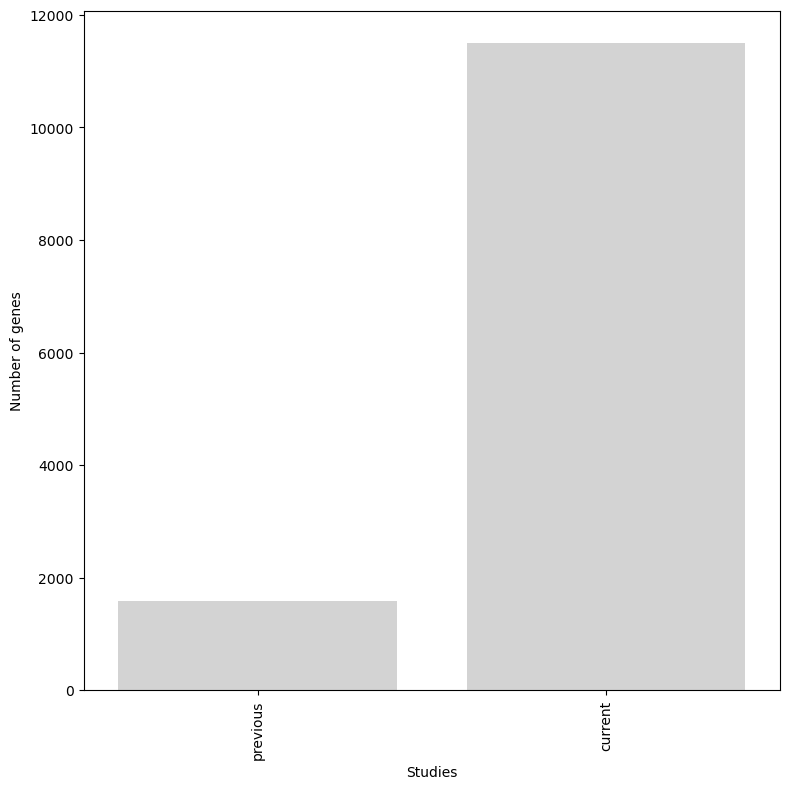

In [352]:
#Let's show the barplots


data = [{'Source': "previous", 'Score': 1587},{'Source': "current", 'Score': 11498}]


df = pd.DataFrame(data)

# Step 2: Plot
plt.figure(figsize=(8, 8))
sns.barplot(data=df, x='Source', y='Score',color='lightgrey')

# Aesthetics
plt.xticks(rotation=90)
plt.ylabel('Number of genes')
plt.xlabel('Studies')
plt.tight_layout()
plt.savefig("Figures/SF1B_2026_official.pdf", dpi=300)
plt.show()

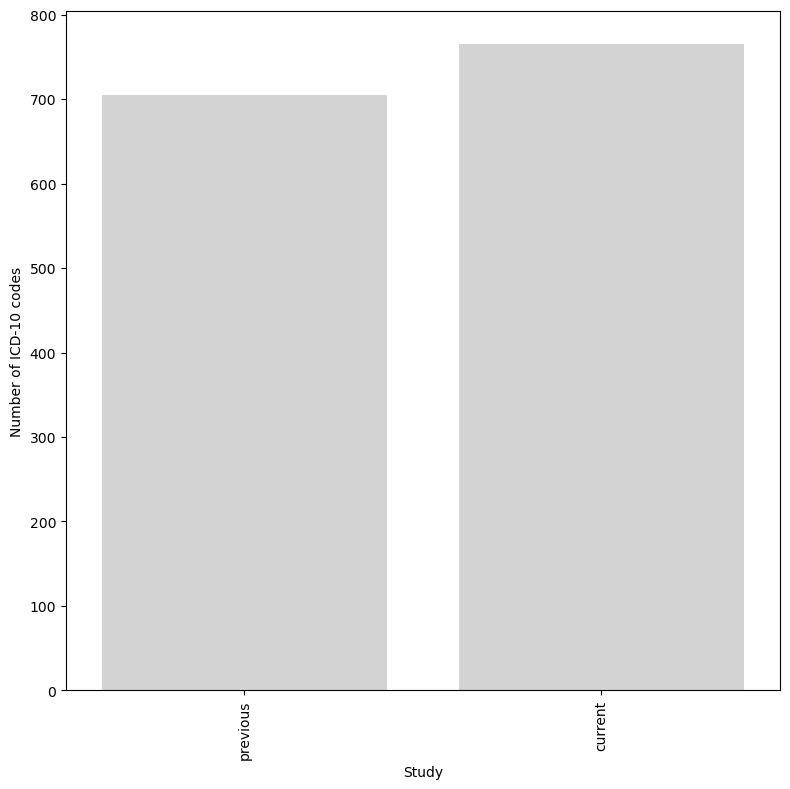

In [353]:
#Let's show the barplots


data = [{'Source': "previous", 'Score': 705},{'Source': "current", 'Score': 766}]


df = pd.DataFrame(data)

# Step 2: Plot
plt.figure(figsize=(8, 8))
sns.barplot(data=df, x='Source', y='Score',color='lightgrey')

# Aesthetics
plt.xticks(rotation=90)
plt.ylabel('Number of ICD-10 codes')
plt.xlabel('Study')
plt.tight_layout()
plt.savefig("Figures/SF1A_2026_official.pdf", dpi=300)
plt.show()

In [32]:
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'wb') as handle:
    pk.dump(allsources_icd_gene_dict_unified, handle, protocol=pk.HIGHEST_PROTOCOL)

In [7]:
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [356]:
from collections import defaultdict

# Precompute mapping from first letter -> (set of ICD codes, set of genes)
icd_map = defaultdict(lambda: (set(), set()))

for icd_code, gene_list in allsources_icd_gene_dict_unified.items():
    first_letter = icd_code[0]
    icd_map[first_letter][0].add(icd_code)
    icd_map[first_letter][1].update(gene_list)

# Build final result
icd_initial = {
    icd[0]: [len(icd_map[icd[0]][0]), len(icd_map[icd[0]][1])]
    for icd in icd10_set
}


In [357]:
icd_initial

{'B': [47, 500],
 'E': [53, 1816],
 'D': [63, 889],
 'G': [51, 2537],
 'F': [56, 2050],
 'I': [60, 2052],
 'J': [46, 1266],
 'M': [60, 1998],
 'L': [54, 1777],
 'H': [47, 2230],
 'C': [71, 1213],
 'N': [58, 832],
 'A': [40, 254],
 'K': [60, 2124],
 '0': [0, 0]}

In [358]:
allsources_icd_gene_dict_unified_lcczscore = {}

for dis,genelist in allsources_icd_gene_dict_unified.items():
    lcc_z = net_modularity(genelist,G_ppi)
    allsources_icd_gene_dict_unified_lcczscore[dis] = lcc_z
    

In [359]:
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'wb') as handle:
    pk.dump(allsources_icd_gene_dict_unified_lcczscore, handle, protocol=pk.HIGHEST_PROTOCOL)

In [360]:
from collections import Counter
missing_icd_initial = []
for icd in icd10_set:
    if icd not in allsources_icd_gene_dict_unified.keys():
        missing_icd_initial.append(icd[0])
Counter(missing_icd_initial)

Counter({'A': 47,
         'B': 39,
         'N': 24,
         'H': 24,
         'F': 22,
         'E': 20,
         'D': 19,
         'M': 19,
         'C': 18,
         'L': 18,
         'J': 18,
         'G': 17,
         'I': 17,
         'K': 12,
         '0': 1})

In [361]:
Counter([el[0] for el in icd10_set])

Counter({'C': 89,
         'A': 87,
         'B': 86,
         'D': 82,
         'N': 82,
         'M': 79,
         'F': 78,
         'I': 77,
         'E': 73,
         'L': 72,
         'K': 72,
         'H': 71,
         'G': 68,
         'J': 64,
         '0': 1})

In [362]:
icd_code_broad = set(el[0] for el in allsources_icd_gene_dict_unified.keys())

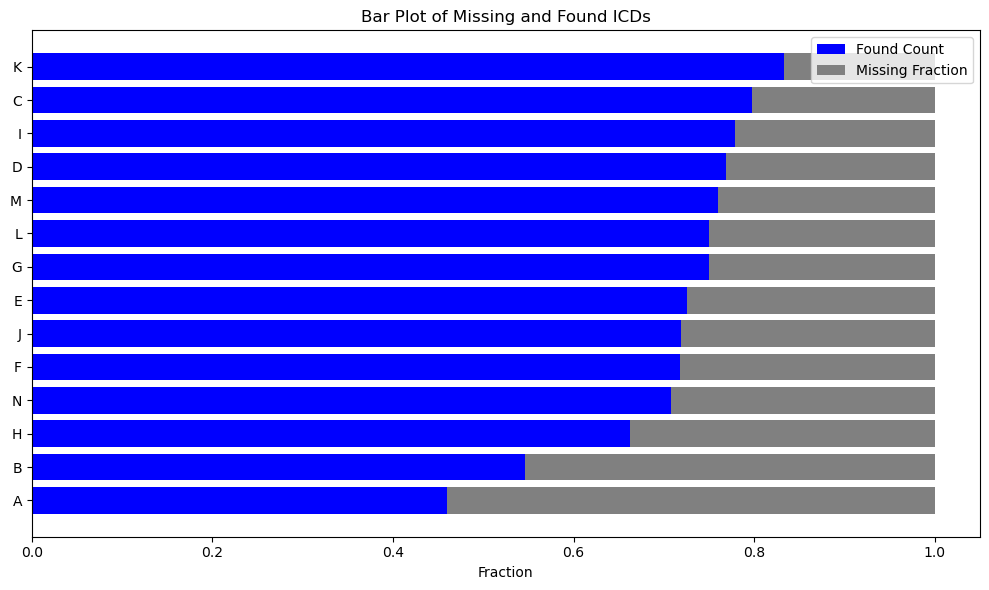

In [363]:

# Calculate missing fraction and found count
icd_labels = []
mis_fr_values = []
found_count_values = []

icd_code_broad_missing_count_dict = dict(Counter(missing_icd_initial).most_common())

for icd in icd_code_broad:
    if icd != '0':
        if icd in icd_code_broad_missing_count_dict.keys():
            tot_count = [i[0] for i in icd10_set if len(i) == 3].count(icd)
            mis_fr = icd_code_broad_missing_count_dict[icd] / tot_count
            found_count = 1 - mis_fr
            icd_labels.append(icd)
            mis_fr_values.append(mis_fr)
            found_count_values.append(found_count)
        else:
            icd_labels.append(icd)
            mis_fr_values.append(0)
            found_count_values.append(1)

# Convert to numpy arrays for sorting
icd_labels = np.array(icd_labels)
mis_fr_values = np.array(mis_fr_values)
found_count_values = np.array(found_count_values)

# Sort by found_count_values
sorted_indices = np.argsort(found_count_values)
icd_labels = icd_labels[sorted_indices]
mis_fr_values = mis_fr_values[sorted_indices]
found_count_values = found_count_values[sorted_indices]

# Create horizontal stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
y_positions = np.arange(len(icd_labels))

ax.barh(y_positions, found_count_values, color="blue", label="Found Count")
ax.barh(y_positions, mis_fr_values, left=found_count_values, color="grey", label="Missing Fraction")

# Add labels and formatting
ax.set_yticks(y_positions)
ax.set_yticklabels(icd_labels)
ax.set_xlabel("Fraction")
ax.set_title("Bar Plot of Missing and Found ICDs")
ax.legend()

# Show plot
plt.tight_layout()
# Uncomment the following line to save the plot
plt.savefig('Figures/SuppFig1C_Missing&FoundICDs_v2026_official.pdf', format='pdf', dpi=300, bbox_inches="tight")
plt.show()

In [35]:
icd10_cat_dict = {}
icd_cat = set([i[0] for i in allsources_icd_gene_dict_unified.keys()])

for cat in icd_cat:
    dis_list = []
    for dis in allsources_icd_gene_dict_unified.keys():
        if cat!='0':
            if cat in dis:
                dis_list.append(dis)
    icd10_cat_dict[cat] = dis_list

In [365]:
icd10_cat_genedict = {}
for icd_cat,dislist in icd10_cat_dict.items():
    genelist = []
    for dis in dislist:
        try:
            genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
        except:
            pass
    icd10_cat_genedict[icd_cat] = set(genelist)
    

In [366]:
for icd_class,geneset in icd10_cat_genedict.items():
    print(icd_class,len(geneset))

N 832
K 2124
D 889
A 254
H 2230
I 2052
M 1998
B 500
E 1816
C 1213
G 2537
L 1777
F 2050
J 1266


In [367]:
# Sort the dictionary based on the length of the sets in descending order
sorted_icd10_cat_genedict= sorted(icd10_cat_genedict.items(), key=lambda item: len(item[1]), reverse=True)

# Extract the top 10 keys
top_10_keys = [key for key, value in sorted_icd10_cat_genedict[:10]]

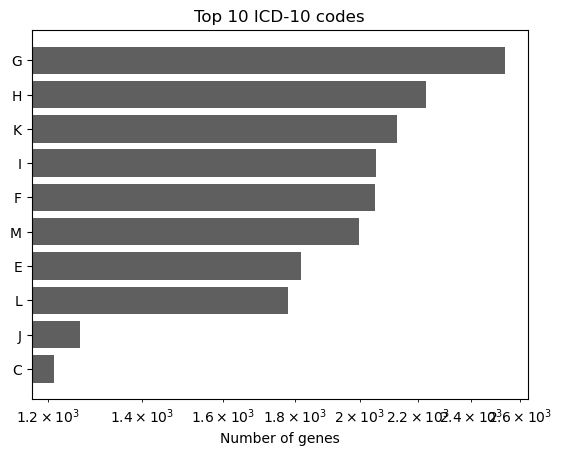

In [368]:

genelist_len = [len(icd10_cat_genedict[dis]) for dis in top_10_keys] 

fig, ax = plt.subplots()

y_pos = np.arange(len(top_10_keys))

ax.barh(y_pos, genelist_len, align='center', color='#5F5F5F')
ax.set_yticks(y_pos, labels=top_10_keys)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xscale('log')
ax.set_xlabel('Number of genes')
ax.set_title('Top 10 ICD-10 codes')

plt.savefig('Figures/SF1E_TopICD10codesbygenes_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
plt.savefig('Figures/SF1E_TopICD10codesbygenes_v2026_official.png',format='pdf',dpi=300, bbox_inches = "tight") 
plt.show()


In [33]:
def overlap_dislists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of diseases
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [40]:

sources_icd10cat_overlap_pval_dict={}

for source,disdict in sources_dict_cl.items():
    for cat,dislist in icd10_cat_dict.items():
        pval_ov=float(overlap_dislists(list(disdict.keys()),dislist,len(icd10_set))) 
        sources_icd10cat_overlap_pval_dict[source,cat]=pval_ov
            
sources_icd10cat_overlap_fdr_dict={}
sources_icd10cat_overlap_sigfdr_dict={}

adj_pval=fdr_adjustment(list(sources_icd10cat_overlap_pval_dict.values()),0.05)
pair_list=list(sources_icd10cat_overlap_pval_dict.keys())
for i in range(len(adj_pval)):
    sources_icd10cat_overlap_fdr_dict[pair_list[i]]=adj_pval[i]
        
for dispair,fdr in sources_icd10cat_overlap_fdr_dict.items():
    if fdr<0.05:
        sources_icd10cat_overlap_sigfdr_dict[dispair]=fdr
    
print(len(sources_icd10cat_overlap_sigfdr_dict))

44


In [41]:
sources_icd10cat_overlap_sigfdr_dict

{('NCBI_ClinVar', 'E'): 0.002143618069139475,
 ('NCBI_ClinVar', 'D'): 3.69493549950963e-05,
 ('NCBI_ClinVar', 'L'): 0.0077196186705594996,
 ('Disease_ehancer', 'C'): 0.00265336781138267,
 ('DISEASES', 'G'): 0.00024903234459951526,
 ('DISEASES', 'E'): 1.0538590206369759e-05,
 ('DISEASES', 'D'): 0.0003068116955246021,
 ('DISEASES', 'M'): 0.02658012900216634,
 ('DISEASES', 'L'): 0.028090350778847712,
 ('OMIM', 'E'): 0.002143618069139475,
 ('OMIM', 'I'): 0.04214972091232418,
 ('GWAS', 'J'): 0.04688241637223592,
 ('GWAS', 'E'): 0.020463487566534076,
 ('GWAS', 'N'): 0.0002487155996448519,
 ('GWAS', 'D'): 0.02326927267244851,
 ('GWAS', 'I'): 3.929651096878919e-05,
 ('GWAS', 'M'): 1.6495366900787078e-08,
 ('GWAS', 'H'): 0.00017175328009752123,
 ('GWAS', 'K'): 6.352077845960364e-11,
 ('Orphanet', 'G'): 0.0440363548791832,
 ('Orphanet', 'E'): 0.0007270421304847521,
 ('Orphanet', 'D'): 0.00011433588644975848,
 ('Orphanet', 'C'): 0.024083059648085804,
 ('DisgeNET', 'J'): 0.0015394221064936092,
 ('

In [42]:
with open('output/icd_cat_color_mapping.pickle', 'rb') as handle:
    icd_cat_color_mapping = pk.load(handle)

In [43]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

In [44]:
G_sources_cat_icd = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc

for dis_pair in sources_icd10cat_overlap_sigfdr_dict.keys():
    ji_weight= overlap_jaccard(list(sources_dict_cl[dis_pair[0]].keys()),icd10_cat_dict[dis_pair[1]])
    G_sources_cat_icd.add_edge(dis_pair[0], dis_pair[1], weight=ji_weight)

print(G_sources_cat_icd.number_of_nodes())
print(G_sources_cat_icd.number_of_edges())

22
44


In [45]:
icd_color_dict = {}

chapter_to_block = {
    "I": "A00–B99",
    "II": "C00–D48",
    "III": "D50–D89",
    "IV": "E00–E90",
    "V": "F00–F99",
    "VI": "G00–G99",
    "VII": "H00–H59",
    "VIII": "H60–H95",
    "IX": "I00–I99",
    "X": "J00–J99",
    "XI": "K00–K93",
    "XII": "L00–L99",
    "XIII": "M00–M99",
    "XIV": "N00–N99",
    "XV": "O00–O99",
    "XVI": "P00–P96",
    "XVII": "Q00–Q99",
    "XVIII": "R00–R99",
    "XIX": "S00–T98",
    "XX": "V01–Y98",
    "XXI": "Z00–Z99",
    "XXII": "U00–U99"
}

# Lists
colors = ['#4589FF', '#00A3FF', '#00B5F1', '#00C2CD', '#00CAA5', '#53CD85', 
          '#7CCD66', '#A3CA47', '#CAC42A', '#EBB71E', '#F9A22C', '#FF8C3F', 
          '#FF7852', '#FF6666']
chapters = ['I', 'II', 'III', 'IV', 'V', 'VI', 'VII', 'VIII', 'IX', 'X', 'XI', 'XII', 'XIII', 'XIV']

# Create dictionary
chapter_to_color = dict(zip(chapters, colors))


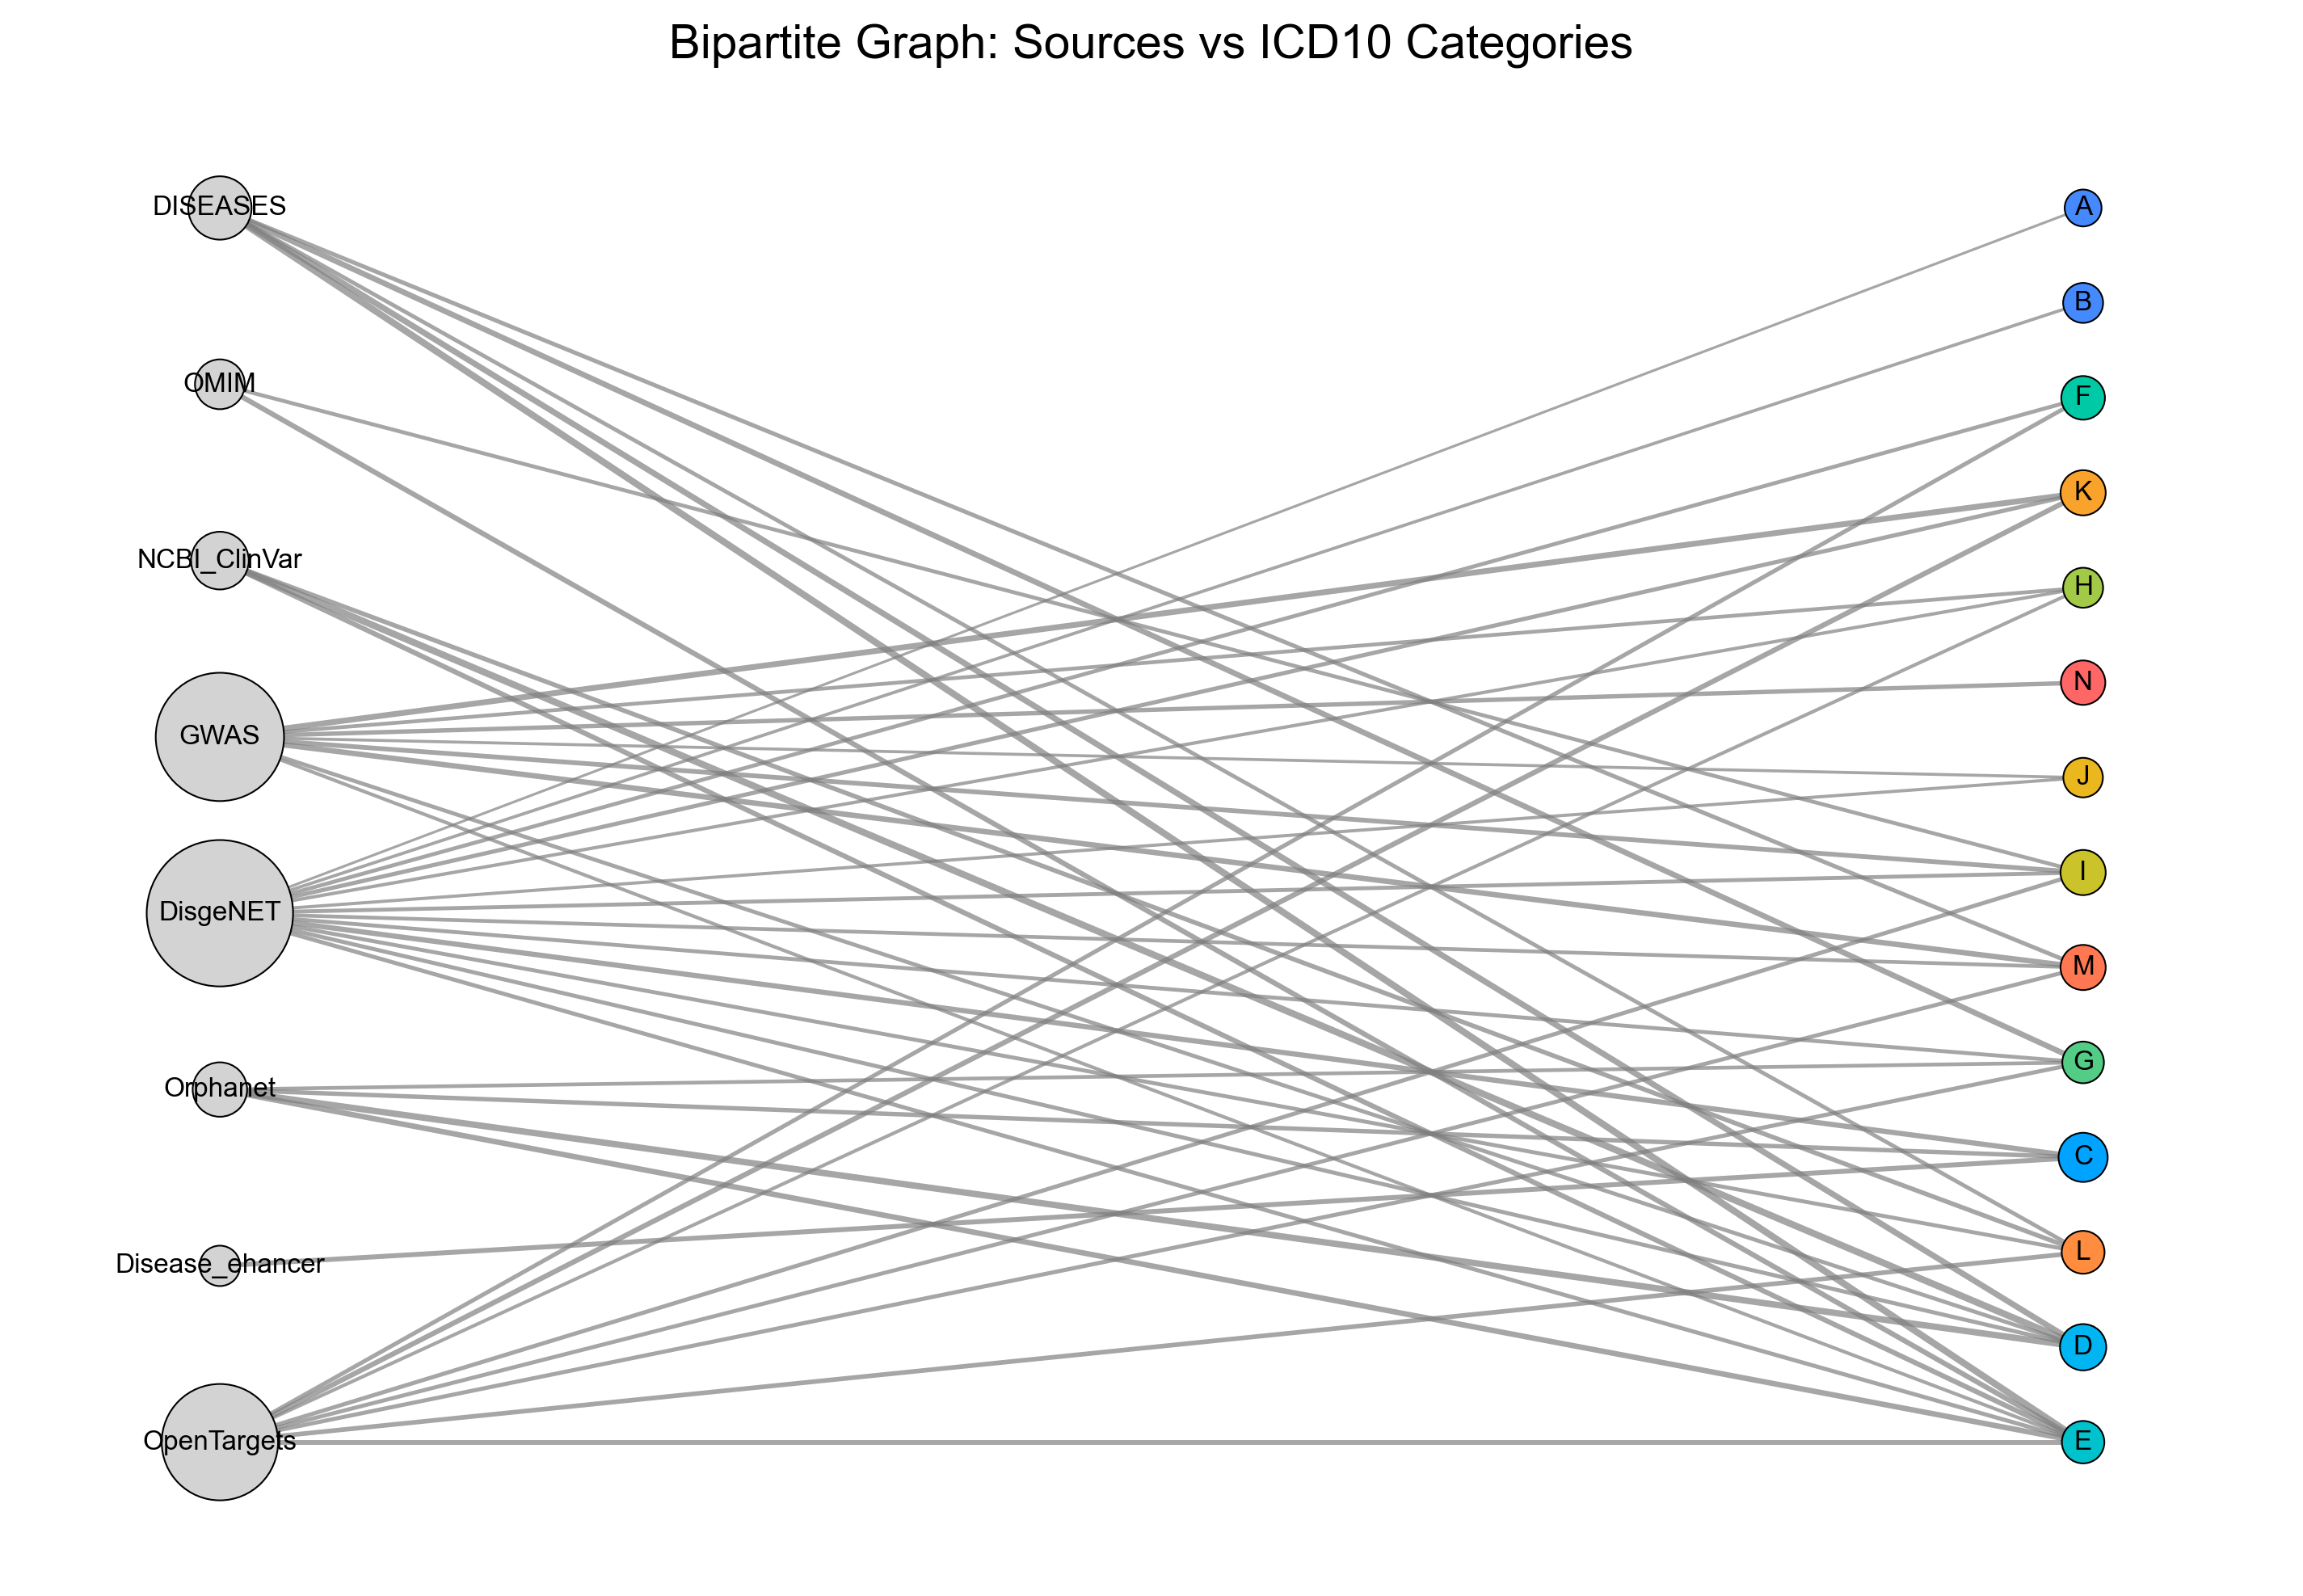

In [46]:
import networkx as nx
import matplotlib.pyplot as plt

# Build graph
G_sources_cat_icd = nx.Graph()

for dis_pair in sources_icd10cat_overlap_sigfdr_dict.keys():
    ji_weight = overlap_jaccard(
        list(sources_dict_cl[dis_pair[0]].keys()), 
        icd10_cat_dict[dis_pair[1]]
    )
    G_sources_cat_icd.add_edge(dis_pair[0], dis_pair[1], weight=ji_weight)

# Define node categories
sources_nodes = set(sources_dict_cl.keys())
icd10_nodes = set(icd10_cat_dict.keys())

icd_to_chapter_dict = {}

for icd in icd10_nodes:
    for ch,icd_range in chapter_to_block.items():
        if icd in icd_range:
            icd_to_chapter_dict[icd] = chapter_to_color[ch]


# Layout for bipartite graph
pos = nx.bipartite_layout(G_sources_cat_icd, sources_nodes)

# Edge weights for plotting
weights = [d["weight"] for (_, _, d) in G_sources_cat_icd.edges(data=True)]
max_w = max(weights) if weights else 1
edge_widths = [2*(w / max_w) for w in weights]

# Assign node colors
node_colors = []
node_sizes = []
for n in G_sources_cat_icd.nodes():
    # Color mapping
    color = icd_to_chapter_dict.get(n, "lightgray")
    node_colors.append(color)

    # Size mapping
    if n in sources_dict_cl:
        size = len(sources_dict_cl[n])
    elif n in icd10_cat_dict:
        size = len(icd10_cat_dict[n])
    else:
        size = 1
    node_sizes.append(3*size)  # scale factor for visibility

# Plot
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_sources_cat_icd, pos, 
                       node_color=node_colors, 
                       node_size=node_sizes, 
                       edgecolors="black", linewidths=0.5)
nx.draw_networkx_edges(G_sources_cat_icd, pos, 
                       width=edge_widths, edge_color="gray", alpha=0.7)
nx.draw_networkx_labels(G_sources_cat_icd, pos, font_size=8)

plt.axis("off")
plt.title("Bipartite Graph: Sources vs ICD10 Categories", fontsize=14)
#plt.savefig('Figures/Fig1E_v2026_official.pdf',format='pdf',dpi=300, bbox_inches = "tight") 
#plt.savefig('Figures/Fig1E_v2026_official.png',format='png',dpi=300, bbox_inches = "tight") 
plt.show()

In [27]:

# -----------------------------
# 4. BUILD SINGLE SOURCE DATA TABLE
# -----------------------------
rows = []

# ---- Nodes ----
for n in G_sources_cat_icd.nodes():
    if n in sources_dict_cl:
        node_type = "source"
        size_raw = len(sources_dict_cl[n])
    else:
        node_type = "icd10"
        size_raw = len(icd10_cat_dict[n])

    rows.append({
        "table_type": "node",
        "node": n,
        "node_type": node_type,
        "color": icd_to_chapter_dict.get(n, "lightgray"),
        "size_raw": size_raw,
        "size_scaled": 3 * size_raw,
        "x_position": pos[n][0],
        "y_position": pos[n][1],
        "source_node": None,
        "target_node": None,
        "weight_jaccard": None
    })

# ---- Edges ----
for u, v, d in G_sources_cat_icd.edges(data=True):
    rows.append({
        "table_type": "edge",
        "node": None,
        "node_type": None,
        "color": None,
        "size_raw": None,
        "size_scaled": None,
        "x_position": None,
        "y_position": None,
        "source_node": u,
        "target_node": v,
        "weight_jaccard": d["weight"]
    })

source_data_df = pd.DataFrame(rows)

# -----------------------------
# 5. SAVE TO SINGLE EXCEL SHEET
# -----------------------------
excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    source_data_df.to_excel(writer, sheet_name="Fig1C", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [15]:
#Let's run PubMed queries

from Bio import Entrez
import time

Entrez.email = "yourmail@gmail.com"
Entrez.tool = "drug_project"

def get_pubmed_count(query):
    handle = Entrez.esearch(
        db="pubmed",
        term=query,
        retmode="xml"
    )
    record = Entrez.read(handle)
    handle.close()
    return int(record["Count"])

icd_lit_associations_chem_dict = {}
for i,v in icd_naming_df.iterrows():
    icd_code = v["ICD"]
    disease_name = v["PubMed_query_name"]
    try:
        count = get_pubmed_count(disease_name)
        icd_lit_associations_chem_dict[icd_code] = count
        
        # polite delay to avoid NCBI rate limit
        time.sleep(0.3)
        
    except Exception as e:
        icd_lit_associations_chem_dict[icd_code] = 0

icd_naming_df["PubMed_count"] = icd_naming_df["ICD"].map(icd_lit_associations_chem_dict)


In [17]:
icd_naming_df.to_csv("output/disease_name_consensus_official_names_PubMed.csv", index=False)

In [39]:
#Let's import the number of papers associated with each ICD code
ICDs_citations_df = pd.read_csv("output/disease_name_consensus_official_names_PubMed.csv")

In [3]:
ICD_pubmed_dict = dict(zip(ICDs_citations_df["ICD"], ICDs_citations_df["PubMed_count"]))

In [47]:
# Extract numeric scores from the LLM output dict
scores = list(ICD_pubmed_dict.values())

# Make sure they are floats (sometimes strings from JSON)
scores = [float(s) for s in scores]
top_percentile_score = np.percentile(scores, 80) 
bottom_percentile_score = np.percentile(scores, 20) 

In [48]:
top_percentile_score_dis_list = [k for k in ICD_pubmed_dict.keys() if ICD_pubmed_dict[k]>top_percentile_score]
bottom_percentile_score_dis_list = [k for k in ICD_pubmed_dict.keys() if ICD_pubmed_dict[k]<bottom_percentile_score]

print(len(top_percentile_score_dis_list))
print(len(bottom_percentile_score_dis_list))

216
216


In [25]:
for k,v in ICD_pubmed_dict.items():
    if v>1000000:
        print(k,v)

A48 1249145
B33 1484497
B99 1155569
C80 4261440
E34 1255015
E88 1467352
F99 1700629


In [44]:
len([k for k,v in ICD_pubmed_dict.items() if v<10])

115

In [28]:
ICDs_citations_df[ICDs_citations_df['ICD']=='C80']

,ICD,Disease Name,Consensus Name,PubMed_query_name,PubMed_count
246,C80,malignant neoplasm without specification of si...,malignant neoplasm without specification of site,malignant neoplasm,4261440


In [62]:
import scipy.stats
from statsmodels.stats.multitest import multipletests

results = []
pvals = []
sources = []

# Compute correlations
for source, data_dict in sources_dict_cl.items():
    
    num_gene_list = []
    num_pub_list = []
    
    for icd, geneset in data_dict.items():
        if icd in ICD_pubmed_dict:
            num_gene_list.append(len(set(geneset)))
            num_pub_list.append(ICD_pubmed_dict[icd])
    
    r, p = scipy.stats.pearsonr(num_gene_list, num_pub_list)
    
    results.append((source, r, p))
    pvals.append(p)
    sources.append(source)

# Add harmonized dataset
num_gene_list = []
num_pub_list = []

for icd, geneset in allsources_icd_gene_dict_unified.items():
    if icd in ICD_pubmed_dict:
        num_gene_list.append(len(set(geneset)))
        num_pub_list.append(ICD_pubmed_dict[icd])

r, p = scipy.stats.pearsonr(num_gene_list, num_pub_list)

results.append(("harmonized agglomeration", r, p))
pvals.append(p)
sources.append("harmonized agglomeration")

# Adjust p-values (FDR)
adjusted = multipletests(pvals, method="fdr_bh")[1]

# Print results
print("Source\tPearson_r\tp_value\tp_adj")

for (source, r, p), p_adj in zip(results, adjusted):
    print(f"{source}\t{r:.3f}\t{p:.3e}\t{p_adj:.3e}")

Source	Pearson_r	p_value	p_adj
NCBI_ClinVar	0.294	5.107e-03	1.248e-02
Disease_ehancer	0.396	5.336e-03	1.248e-02
DISEASES	0.233	1.117e-02	1.675e-02
OMIM	-0.037	7.888e-01	7.888e-01
GWAS	0.027	5.549e-01	6.242e-01
Orphanet	0.068	5.393e-01	6.242e-01
DisgeNET	0.124	1.861e-03	1.248e-02
OpenTargets	0.139	5.548e-03	1.248e-02
harmonized agglomeration	0.095	8.447e-03	1.520e-02


In [53]:
sources_dict_cl_balance_disease_ratio = {}
for source,data_dict in sources_dict_cl.items():
    top_dis_dict = set(top_percentile_score_dis_list) & data_dict.keys()
    bottom_dis_dict = set(bottom_percentile_score_dis_list) & data_dict.keys()
    if len(bottom_dis_dict)>0:
        print(source)
        print(len(top_dis_dict)/len(bottom_dis_dict))
        sources_dict_cl_balance_disease_ratio[source] = len(top_dis_dict)/len(bottom_dis_dict)
    else:
        print(source)
        print("Missing bottom")

NCBI_ClinVar
10.666666666666666
Disease_ehancer
34.0
DISEASES
5.111111111111111
OMIM
4.25
GWAS
3.2083333333333335
Orphanet
3.125
DisgeNET
2.5522388059701493
OpenTargets
3.6315789473684212


In [36]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

pvals = []
labels = []

# Per source tests
for source, data_dict in sources_dict_cl.items():
    top_dis = set(top_percentile_score_dis_list) & data_dict.keys()
    bottom_dis = set(bottom_percentile_score_dis_list) & data_dict.keys()

    top_vals = [len(data_dict[dis]) for dis in top_dis]
    bottom_vals = [len(data_dict[dis]) for dis in bottom_dis]

    if len(top_vals) > 1 and len(bottom_vals) > 1:
        _, p_val = stats.ttest_ind(top_vals, bottom_vals)
    else:
        p_val = 1.0  # avoid crashes, will never be significant

    pvals.append(p_val)
    labels.append(source)


# Unified test
top_dis = set(top_percentile_score_dis_list) & allsources_icd_gene_dict_unified.keys()
bottom_dis = set(bottom_percentile_score_dis_list) & allsources_icd_gene_dict_unified.keys()

top_vals = [len(allsources_icd_gene_dict_unified[dis]) for dis in top_dis]
bottom_vals = [len(allsources_icd_gene_dict_unified[dis]) for dis in bottom_dis]

_, p_val = stats.ttest_ind(top_vals, bottom_vals)

pvals.append(p_val)
labels.append("ALL_SOURCES_UNIFIED")


# -------- FDR correction (Benjamini-Hochberg) --------
reject, pvals_fdr, _, _ = multipletests(pvals, method="fdr_bh")


# -------- Print results --------
for label, raw_p, fdr_p, rej in zip(labels, pvals, pvals_fdr, reject):
    print(f"{label}")
    print(f"  raw p-value  = {raw_p}")
    print(f"  FDR p-value  = {fdr_p}")
    print(f"  significant? = {rej}")
    print()

NCBI_ClinVar
  raw p-value  = 0.09237416263228998
  FDR p-value  = 0.16627349273812195
  significant? = False

Disease_ehancer
  raw p-value  = 1.0
  FDR p-value  = 1.0
  significant? = False

DISEASES
  raw p-value  = 0.2817089680230509
  FDR p-value  = 0.36219724460106545
  significant? = False

OMIM
  raw p-value  = 0.7137044412470774
  FDR p-value  = 0.8029174964029622
  significant? = False

GWAS
  raw p-value  = 0.04122835464960126
  FDR p-value  = 0.10027836592088596
  significant? = False

Orphanet
  raw p-value  = 0.12057042567091669
  FDR p-value  = 0.18085563850637504
  significant? = False

DisgeNET
  raw p-value  = 0.00020935004510140988
  FDR p-value  = 0.0009420752029563444
  significant? = True

OpenTargets
  raw p-value  = 0.04456816263150487
  FDR p-value  = 0.10027836592088596
  significant? = False

ALL_SOURCES_UNIFIED
  raw p-value  = 5.54598739512664e-05
  FDR p-value  = 0.0004991388655613976
  significant? = True



In [50]:

num_gene_list = []
num_pub_list = []
for icd,geneset in allsources_icd_gene_dict_unified.items():
    if icd in ICD_pubmed_dict:
        num_gene_list.append(len(set(geneset)))
        num_pub_list.append(ICD_pubmed_dict[icd])

print(scipy.stats.pearsonr(num_gene_list, num_pub_list))

PearsonRResult(statistic=0.09509731070877422, pvalue=0.008447182451504179)


In [51]:

all_sources_top_dis_dict = set(top_percentile_score_dis_list) & allsources_icd_gene_dict_unified.keys()
all_sources_bottom_dis_dict = set(bottom_percentile_score_dis_list) & allsources_icd_gene_dict_unified.keys()

print(len(all_sources_top_dis_dict)/len(all_sources_bottom_dis_dict))

2.0104166666666665


In [54]:
sources_dict_cl_balance_disease_ratio['harmonized agglomeration'] = len(all_sources_top_dis_dict)/len(all_sources_bottom_dis_dict)

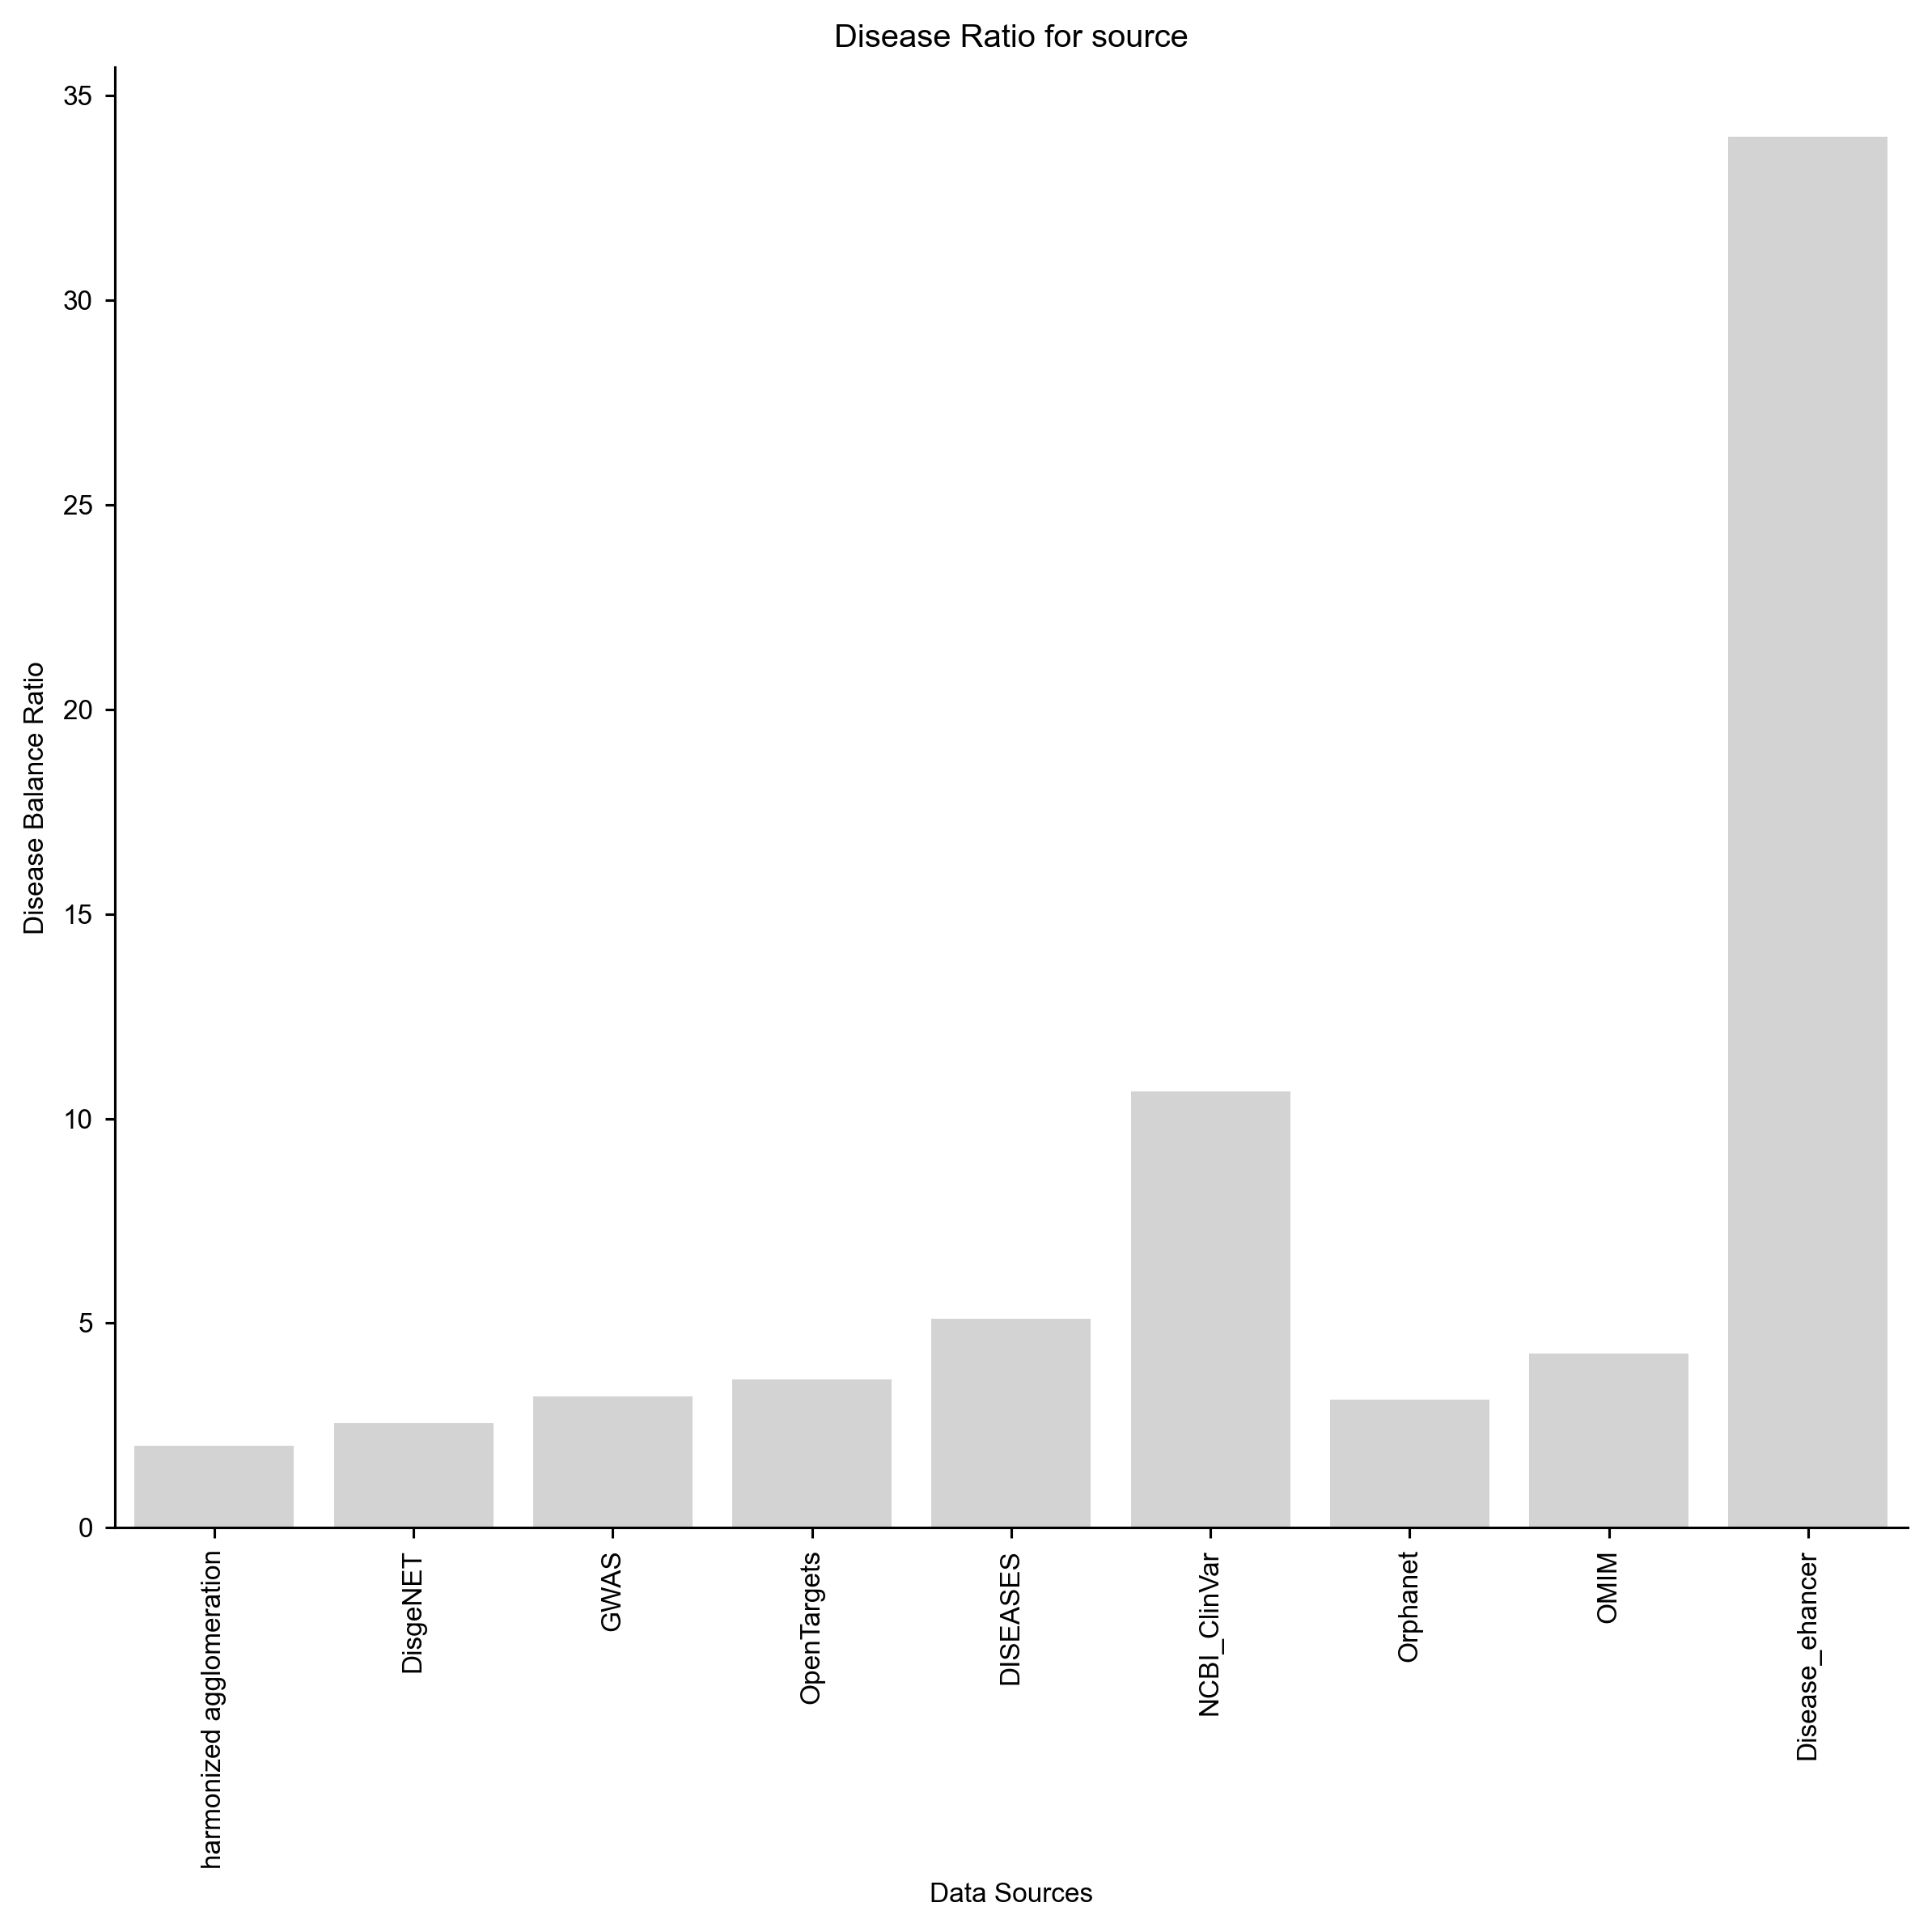

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = []

for key, val in sources_dict_cl_balance_disease_ratio.items():
    
    if key == 'harmonized agglomeration':
        db_size = len(allsources_icd_gene_dict_unified)
    else:
        db_size = len(sources_dict_cl[key])
    
    data.append({
        'Source': key,
        'Score': val,
        'DB_size': db_size
    })

df = pd.DataFrame(data)
df = df.sort_values('DB_size', ascending=False)
plt.figure(figsize=(8, 8))

sns.barplot(
    data=df,
    x='Source',
    y='Score',
    color='lightgrey',
    order=df['Source']   # <- THIS is the key line
)

plt.xticks(rotation=90)
plt.title('Disease Ratio for source')
plt.ylabel('Disease Balance Ratio')
plt.xlabel('Data Sources')

plt.tight_layout()
plt.savefig("Figures/Disease_BalanceRatio_DataSource_Score_v2026_official.pdf", dpi=300)
plt.show()

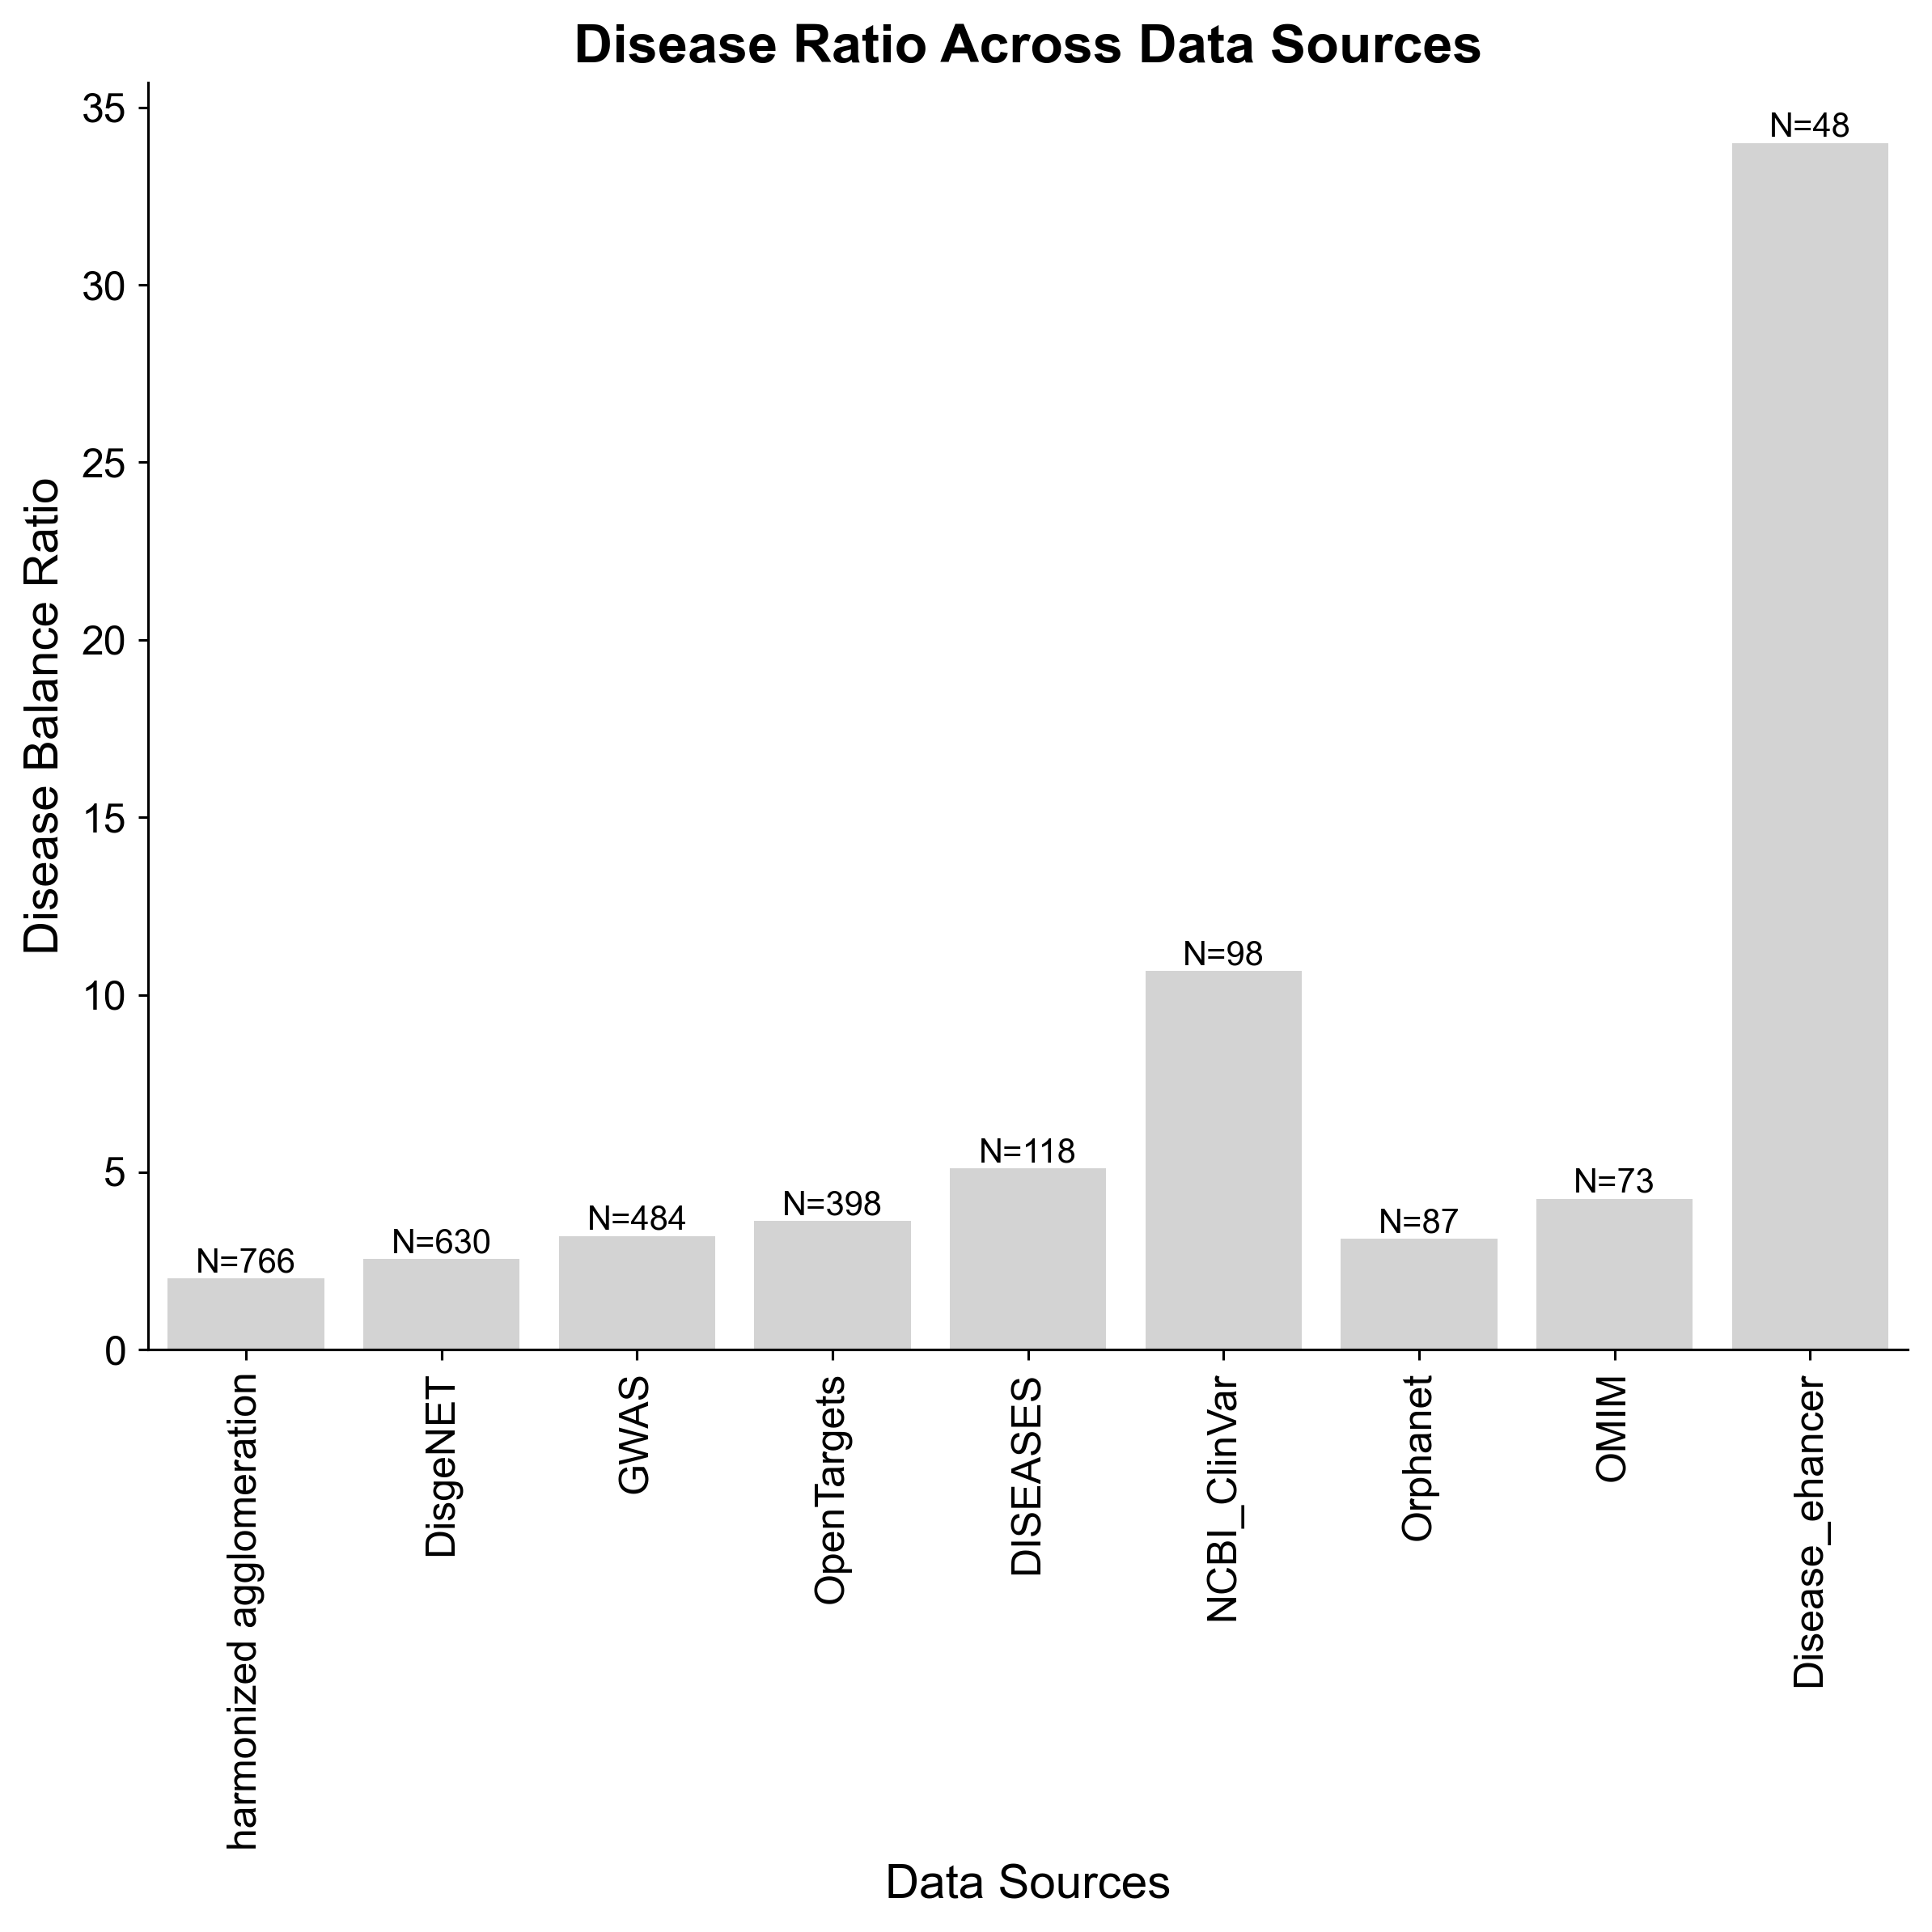

In [56]:

# Ensure editable fonts in vector output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['svg.fonttype'] = 'none'

data = []

for key, val in sources_dict_cl_balance_disease_ratio.items():
    
    if key == 'harmonized agglomeration':
        db_size = len(allsources_icd_gene_dict_unified)
    else:
        db_size = len(sources_dict_cl[key])
    
    data.append({
        'Source': key,
        'Score': val,
        'DB_size': db_size
    })

df = pd.DataFrame(data)

# Sort by database size
df = df.sort_values('DB_size', ascending=False)

# Lock order explicitly
order = df['Source'].tolist()

plt.figure(figsize=(8,8))

ax = sns.barplot(
    data=df,
    x='Source',
    y='Score',
    color='lightgrey',
    order=order
)

# Add DB size labels on top of bars
for i, row in df.iterrows():
    ax.text(
        order.index(row['Source']),
        row['Score'],
        f"N={row['DB_size']}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Styling
sns.despine()
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

plt.title('Disease Ratio Across Data Sources', fontsize=16, weight='bold')
plt.ylabel('Disease Balance Ratio', fontsize=14)
plt.xlabel('Data Sources', fontsize=14)

plt.tight_layout()

plt.savefig(
    "Figures/Disease_BalanceRatio_DataSource_Score_v2026_official.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "Figures/Disease_BalanceRatio_DataSource_Score_v2026_official.svg",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [57]:
sources_dict_cl_balance_disease_ratio

{'NCBI_ClinVar': 10.666666666666666,
 'Disease_ehancer': 34.0,
 'DISEASES': 5.111111111111111,
 'OMIM': 4.25,
 'GWAS': 3.2083333333333335,
 'Orphanet': 3.125,
 'DisgeNET': 2.5522388059701493,
 'OpenTargets': 3.6315789473684212,
 'harmonized agglomeration': 2.0104166666666665}

In [59]:

data = []

for key, val in sources_dict_cl_balance_disease_ratio.items():
    
    if key == 'harmonized agglomeration':
        db_size = len(allsources_icd_gene_dict_unified)
    else:
        db_size = len(sources_dict_cl[key])
    
    data.append({
        'Source': key,
        'Score': val,
        'DB_size': db_size
    })

df = pd.DataFrame(data)
df = df.sort_values('DB_size', ascending=False)

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a", if_sheet_exists="replace") as writer:
    df.to_excel(writer, sheet_name="Fig1D", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [60]:
#Let's plot the distribution of number of citations across data sources

sources_dict_cl_cit_dict = {}
for source, dis_dict in sources_dict_cl.items():
    cit_list = []
    for dis, genes in dis_dict.items():
        if len(genes)>0:
            try:
                cit_list.append(ICD_pubmed_dict[dis])
            except:
                pass
    sources_dict_cl_cit_dict[source] = cit_list

sources_dict_cl_cit_dict["harmonized agglomeration"] = [ICD_pubmed_dict[dis] for dis,genes in allsources_icd_gene_dict_unified.items() if len(genes)>0]



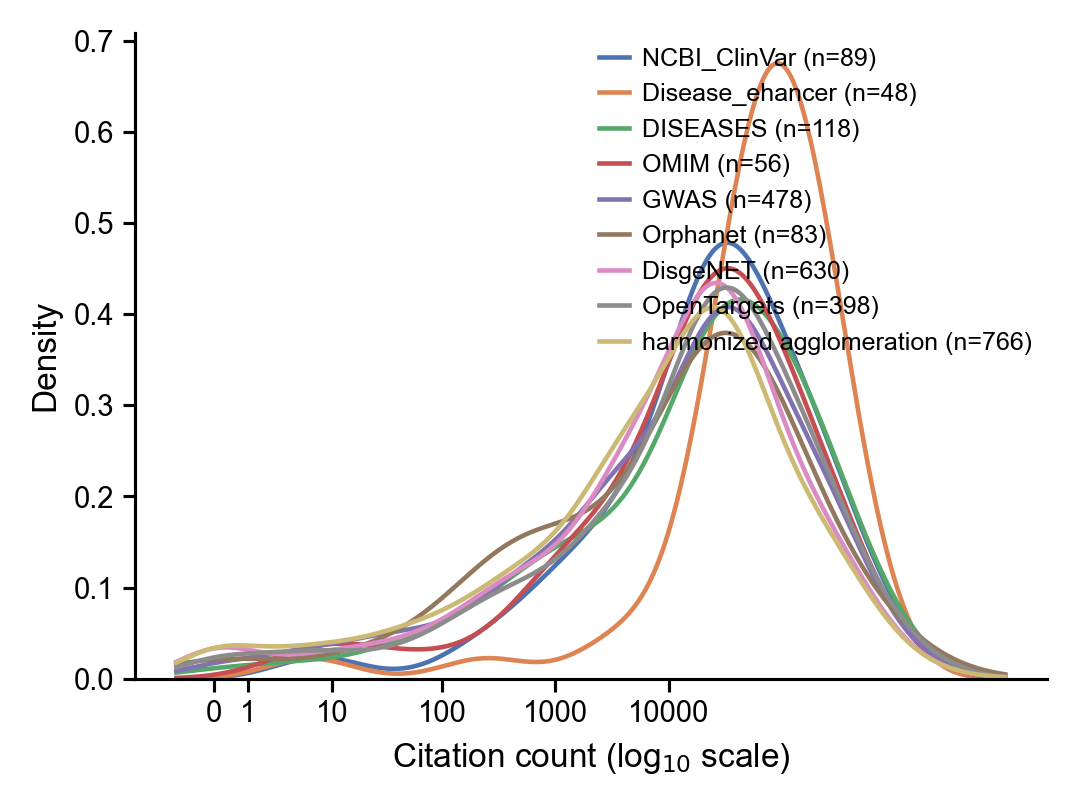

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import gaussian_kde

# =========================================================
# Nature-style rcParams
# =========================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8,
    "axes.linewidth": 0.75,
    "xtick.major.width": 0.75,
    "ytick.major.width": 0.75,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.dpi": 600,
    "figure.dpi": 300,
})

# =========================================================
# Data prep
# =========================================================
sources = list(sources_dict_cl_cit_dict.keys())
n = len(sources)

# Nature-style qualitative palette
palette = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3", "#8C8C8C",
    "#CCB974", "#64B5CD",
]
colors = [palette[i % len(palette)] for i in range(n)]

# log10(x+1) transform to handle zeros/small counts safely
log_data = {
    src: np.log10(np.asarray(vals, dtype=float) + 1.0)
    for src, vals in sources_dict_cl_cit_dict.items()
    if len(vals) > 0
}

global_min = min(v.min() for v in log_data.values())
global_max = max(v.max() for v in log_data.values())
pad = 0.05 * (global_max - global_min)
x_grid = np.linspace(global_min - pad, global_max + pad, 512)

# =========================================================
# Figure
# =========================================================
fig, ax = plt.subplots(figsize=(3.5, 2.6))  # single-column Nature width (mm ~89)

for src, color in zip(log_data.keys(), colors):
    data = log_data[src]

    # Silverman bandwidth via scipy default; guard against degenerate variance
    if data.std() == 0 or len(data) < 2:
        continue
    kde = gaussian_kde(data)
    density = kde(x_grid)

    ax.plot(x_grid, density, color=color, lw=1.1, label=f"{src} (n={len(data)})")
    #ax.fill_between(x_grid, density, color=color, alpha=0.12, lw=0)

# =========================================================
# Axis formatting — log-scale tick labels on a log10-transformed axis
# =========================================================
ax.set_xlabel("Citation count (log$_{10}$ scale)", labelpad=3)
ax.set_ylabel("Density", labelpad=3)

# Build tick positions in log10(x+1) space, label as original counts
tick_vals = [0, 1, 10, 100, 1000, 10000]
tick_pos = [np.log10(v + 1) for v in tick_vals if np.log10(v + 1) <= global_max + pad]
tick_labels = [str(v) for v in tick_vals[: len(tick_pos)]]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)

ax.set_ylim(bottom=0)
ax.tick_params(axis="both", which="major", labelsize=7, pad=2)

legend = ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=6,
    handlelength=1.2,
    handletextpad=0.5,
    borderaxespad=0.2,
)

fig.tight_layout(pad=0.5)

# =========================================================
# Export — vector PDF + high-res raster
# =========================================================
fig.savefig("Figures/citation_density_by_source.pdf", bbox_inches="tight", transparent=True)
fig.savefig("Figures/citation_density_by_source.svg", bbox_inches="tight", dpi=600)

plt.show()

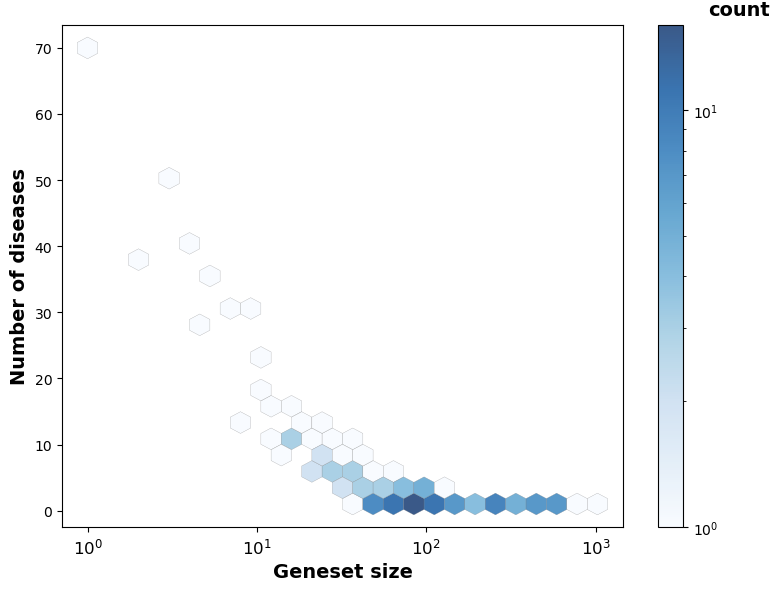

In [79]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from collections import Counter

genelist_sizes = [
    len(genes) for genes in allsources_icd_gene_dict_unified.values()
    if len(genes) > 0
]

# Step 2 — aggregate
# x = Geneset Size
# y = Number of diseases (Frequency of that size)
size_counts = Counter(genelist_sizes)
x = np.array(list(size_counts.keys()))
y = np.array(list(size_counts.values()))

# Step 3 — plot
fig, ax = plt.subplots(figsize=(8, 6))

# IMPORTANT: Matplotlib's hexbin bins linearly. To get the specific look 
# of the target plot (logarithmic X-axis with regular hexagons), we must 
# log-transform the X data *before* plotting.
x_log = np.log10(x)

hb = ax.hexbin(
    x_log,               # Log-transformed X
    y,                   # Linear Y
    gridsize=25,         # Controls the resolution (size of hexagons)
    cmap='Blues',        # Matches the color scheme
    bins='log',          # Logarithmic color scaling (for the count)
    mincnt=1,            # Hides empty hexagons (background)
    edgecolors='grey',   # Adds the subtle borders around hexes
    linewidths=0.2,
    alpha=0.8
)

# Step 4 — Formatting
ax.set_ylabel("Number of diseases", fontsize=14, fontweight='bold')
ax.set_xlabel("Geneset size", fontsize=14, fontweight='bold')

# Manually formatting the X-ticks to look like the Log scale
# Since we plotted log10(x), 0 maps to 10^0, 1 maps to 10^1, etc.
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(['$10^0$', '$10^1$', '$10^2$', '$10^3$'], fontsize=12)

# Add the colorbar
cbar = plt.colorbar(hb, ax=ax)
cbar.set_label("count", rotation=0, labelpad=15, fontsize=14, fontweight='bold', y=1.05)
cbar.ax.tick_params(labelsize=10)

# Optional: Match the y-axis limit if needed (e.g., 0 to 45)
# ax.set_ylim(bottom=0) 

plt.tight_layout()

plt.savefig("Figures/Hexbin_Fig1E_v2026_official.pdf", dpi=300)
plt.show()

In [80]:


# -----------------------------
# 1. Compute Data
# -----------------------------
genelist_sizes = [
    len(genes) for genes in allsources_icd_gene_dict_unified.values()
    if len(genes) > 0
]

size_counts = Counter(genelist_sizes)

x = np.array(list(size_counts.keys()))          # Geneset size
y = np.array(list(size_counts.values()))        # Number of diseases
x_log = np.log10(x)                             # Log transform used in plot

# -----------------------------
# 2. Save Source Data (Single Sheet)
# -----------------------------
source_df = pd.DataFrame({
    "geneset_size": x,
    "log10_geneset_size": x_log,
    "number_of_diseases": y
})

excel_path = "output/SourceData.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl",mode="a") as writer:
    source_df.to_excel(writer, sheet_name="Fig1E", index=False)

print(f"Source data saved to {excel_path}")

Source data saved to output/SourceData.xlsx


In [ ]:


with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    source_data_df.to_excel(writer, sheet_name="Fig1C", index=False)

In [377]:
#Let's import the unified gene annotations lcc z-score
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)

In [378]:
import scipy

num_gene_list = []
zscore_list = []
for icd,z in allsources_icd_gene_dict_unified_lcczscore.items():
    if str(z)!='nan':
        zscore_list.append(z)
        num_gene_list.append(len(allsources_icd_gene_dict_unified[icd]))
        
print(scipy.stats.pearsonr(num_gene_list, zscore_list))
print(scipy.stats.spearmanr(num_gene_list, zscore_list))

PearsonRResult(statistic=0.02830697948313254, pvalue=0.4757371298622615)
SignificanceResult(statistic=0.25403598741988764, pvalue=7.717219530779505e-11)


Pearson r=0.028, p=4.757e-01
Spearman rho=0.254, p=7.717e-11


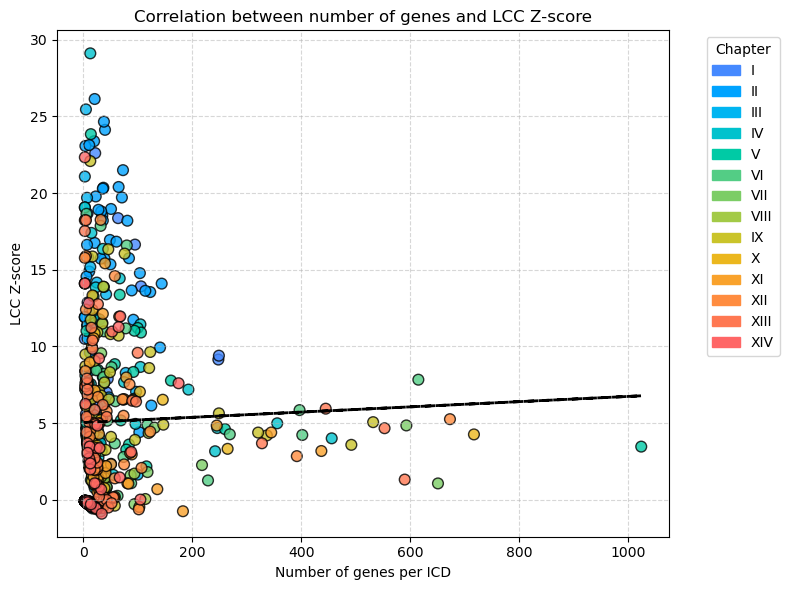

In [379]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats

# --- Prepare data ---
num_gene_list = []
zscore_list = []
color_list = []

for icd, z in allsources_icd_gene_dict_unified_lcczscore.items():
    if str(z) != 'nan':
        # Number of genes
        num_genes = len(allsources_icd_gene_dict_unified[icd])
        num_gene_list.append(num_genes)
        zscore_list.append(z)

        # Determine chapter color
        chapter_color = "gray"  # default
        for chapter, block in chapter_to_block.items():
            # Blocks are ranges like "A00–B99"
            start, end = block.split("–")
            if start <= icd <= end:
                chapter_color = chapter_to_color.get(chapter, "gray")
                break
        color_list.append(chapter_color)

# Convert to numpy arrays
x = np.array(num_gene_list)
y = np.array(zscore_list)

# --- Compute correlations ---
pearson_r, pearson_p = scipy.stats.pearsonr(x, y)
spearman_r, spearman_p = scipy.stats.spearmanr(x, y)
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}")
print(f"Spearman rho={spearman_r:.3f}, p={spearman_p:.3e}")

# --- Plot scatter ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=color_list, s=60, alpha=0.8, edgecolor='k')

# Add regression line
slope, intercept = np.polyfit(x, y, 1)
plt.plot(x, slope*x + intercept, color='black', lw=2, linestyle='--', label="Linear fit")

plt.xlabel("Number of genes per ICD")
plt.ylabel("LCC Z-score")
plt.title("Correlation between number of genes and LCC Z-score")
plt.grid(True, linestyle='--', alpha=0.5)

# Create legend for chapters (unique colors)
import matplotlib.patches as mpatches
handles = []
used_chapters = set()
for chapter, color in chapter_to_color.items():
    if chapter not in used_chapters:
        handles.append(mpatches.Patch(color=color, label=chapter))
        used_chapters.add(chapter)
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", title="Chapter")

plt.tight_layout()
plt.show()

Pearson r=0.028, p=4.757e-01
Spearman rho=0.254, p=7.717e-11


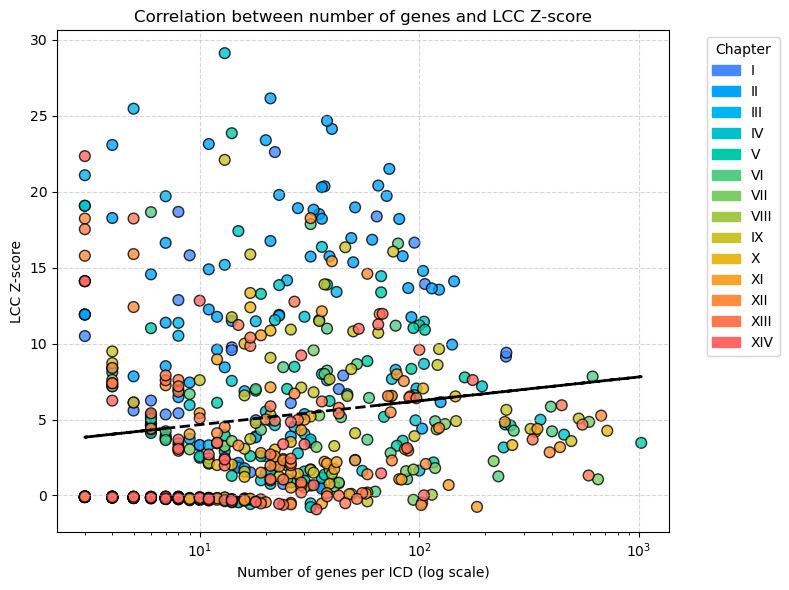

In [380]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import matplotlib.patches as mpatches

# --- Prepare data ---
num_gene_list = []
zscore_list = []
color_list = []

for icd, z in allsources_icd_gene_dict_unified_lcczscore.items():
    if str(z) != 'nan':
        # Number of genes
        num_genes = len(allsources_icd_gene_dict_unified[icd])
        num_gene_list.append(num_genes)
        zscore_list.append(z)

        # Determine chapter color
        chapter_color = "gray"  # default
        for chapter, block in chapter_to_block.items():
            start, end = block.split("–")
            if start <= icd <= end:
                chapter_color = chapter_to_color.get(chapter, "gray")
                break
        color_list.append(chapter_color)

# Convert to numpy arrays
x = np.array(num_gene_list)
y = np.array(zscore_list)

# --- Compute correlations ---
pearson_r, pearson_p = scipy.stats.pearsonr(x, y)
spearman_r, spearman_p = scipy.stats.spearmanr(x, y)
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.3e}")
print(f"Spearman rho={spearman_r:.3f}, p={spearman_p:.3e}")

# --- Plot scatter ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, c=color_list, s=60, alpha=0.8, edgecolor='k')

# Add regression line
slope, intercept = np.polyfit(np.log10(x), y, 1)  # linear fit in log scale
plt.plot(x, slope*np.log10(x) + intercept, color='black', lw=2, linestyle='--', label="Linear fit")

plt.xscale("log")  # Logarithmic x-axis
plt.xlabel("Number of genes per ICD (log scale)")
plt.ylabel("LCC Z-score")
plt.title("Correlation between number of genes and LCC Z-score")
plt.grid(True, linestyle='--', alpha=0.5)

# Legend for chapters
handles = []
used_chapters = set()
for chapter, color in chapter_to_color.items():
    if chapter not in used_chapters:
        handles.append(mpatches.Patch(color=color, label=chapter))
        used_chapters.add(chapter)
plt.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", title="Chapter")

plt.tight_layout()
plt.savefig("Figures/SuppFig1D_CorrelationDisSize_Diseases_v2026_official.pdf", dpi=300)
plt.show()